# Data-Preprocessing

## Load Dataset

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
dataset = pd.read_excel('Anemia dataset.xlsx')
dataset

,Gender,Age,Hb,RBC,PCV,MCV,MCH,MCHC,Decision_Class
0,f,32,10.9,4.26,34.2,80.2,25.5,31.8,1
1,f,45,9.6,3.64,29.9,82.1,26.4,32.2,1
2,f,38,10.1,3.70,32.4,87.6,27.4,31.3,1
3,m,37,11.0,3.93,33.6,85.3,27.9,32.7,1
4,f,50,12.1,4.16,36.5,87.9,29.2,33.2,0
...,...,...,...,...,...,...,...,...,...
995,f,32,10.4,4.49,28.4,63.2,21.2,33.5,1
996,m,48,13.7,4.37,37.8,86.6,31.4,36.2,0
997,m,19,12.1,4.17,33.5,80.4,28.9,36.0,0
998,f,35,12.2,4.28,33.5,78.4,28.6,36.5,0


In [6]:
dataset.describe()

,Age,Hb,RBC,PCV,MCV,MCH,MCHC,Decision_Class
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000
mean,40.956000,11.568400,4.133810,32.65240,79.22000,28.143400,35.427000,0.641000
std,16.019322,1.336715,0.599695,4.85723,7.77521,3.340107,1.418162,0.479947
min,18.000000,5.500000,1.470000,10.60000,29.60000,13.300000,25.300000,0.000000
25%,28.000000,10.800000,3.767500,29.80000,75.20000,26.400000,34.900000,0.000000
50%,38.000000,11.600000,4.110000,32.80000,80.70000,28.700000,35.700000,1.000000
75%,51.250000,12.200000,4.460000,35.62500,84.42500,30.400000,36.300000,1.000000
max,96.000000,15.800000,7.410000,49.50000,104.90000,37.900000,38.100000,1.000000


## Detect missing values + Data Cleaning + Check Decision_Class

In [88]:
#detect missing values
df = pd.read_excel('Anemia dataset.xlsx')
if isinstance(df, dict):  # Handle multiple sheets
    sheet_names = df.keys()
    print(f"Available sheets: {sheet_names}")  # Output available sheets
    df = df[list(sheet_names)[0]]  # Default to the first sheet for now

# Recheck missing values
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

# Create a DataFrame for the report
missing_report = pd.DataFrame({
    'Missing Values Count': missing_values,
    '% of Total Values': missing_percentage
}).sort_values(by='Missing Values Count', ascending=False)

# Filter to show only columns with missing values
missing_report = missing_report[missing_report['Missing Values Count'] > 0]

# Output the report
print(missing_report)
print(df.isnull().sum())  # Check missing values


Empty DataFrame
Columns: [Missing Values Count, % of Total Values]
Index: []
Gender            0
Age               0
Hb                0
RBC               0
PCV               0
MCV               0
MCH               0
MCHC              0
Decision_Class    0
dtype: int64


In [89]:
#Data cleaning
# Print the number of unique values in each column
for i, column in enumerate(dataset.columns):
    print(f"Column {i} ({column}): {dataset[column].nunique()} unique values")

Column 0 (Gender): 2 unique values
Column 1 (Age): 63 unique values
Column 2 (Hb): 71 unique values
Column 3 (RBC): 250 unique values
Column 4 (PCV): 222 unique values
Column 5 (MCV): 286 unique values
Column 6 (MCH): 158 unique values
Column 7 (MCHC): 77 unique values
Column 8 (Decision_Class): 2 unique values


In [90]:
# Check class distribution in 'Decision_Class'
class_distribution = dataset['Decision_Class'].value_counts()
class_distribution

Decision_Class
1    641
0    359
Name: count, dtype: int64

## Preprocessing

In [4]:
#Import Librabries
from pandas import read_excel
# load the dataset
def load_dataset(filename):
# split into input and output variables
    dataset = read_excel(filename)
    X = dataset.iloc[:, :-1].values
    y = dataset.iloc[:,-1].values
    return X, y
# load the dataset
X, y = load_dataset('Anemia Dataset.xlsx')

In [6]:
# split into train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [7]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (800, 8)
X_test shape: (200, 8)
y_train shape: (800,)
y_test shape: (200,)


In [8]:
#prepare input data
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
def prepare_inputs(X_train, X_test):
    # Apply OneHotEncoder to the first column (Gender)
    ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(sparse_output=False), [0])], remainder='passthrough')
    # Fit on the training data and transform both training and test sets
    X_train_enc = np.array(ct.fit_transform(X_train),dtype = float)
    X_test_enc = np.array(ct.transform(X_test), dtype = float)
    return X_train_enc, X_test_enc
# prepare input data
X_train_enc, X_test_enc = prepare_inputs(X_train, X_test)

In [27]:
dataset = pd.DataFrame(X_train_enc)
dataset

,0,1,2,3,4,5,6,7,8
0,1.0,0.0,53.0,11.7,4.43,33.7,76.0,26.4,34.7
1,1.0,0.0,38.0,11.9,4.03,32.7,81.2,29.4,36.3
2,1.0,0.0,22.0,12.6,4.14,35.3,85.3,30.4,35.6
3,0.0,1.0,30.0,12.4,5.19,38.9,74.9,24.0,32.0
4,1.0,0.0,55.0,10.9,3.69,29.7,80.6,29.6,36.8
...,...,...,...,...,...,...,...,...,...
795,1.0,0.0,32.0,11.0,3.90,30.7,78.8,28.3,36.0
796,1.0,0.0,58.0,10.0,3.70,28.8,77.9,27.0,34.6
797,1.0,0.0,35.0,11.6,4.38,33.4,76.2,26.6,34.9
798,1.0,0.0,26.0,11.9,4.76,33.5,70.3,25.0,35.6


In [12]:
#prepare target
from sklearn.preprocessing import LabelEncoder
def prepare_targets(y_train,y_test):
    le = LabelEncoder()
    le.fit(y_train)
    y_train_enc = le.fit_transform(y_train)
    y_test_enc = le.transform(y_test)

    return y_train_enc, y_test_enc
# prepare output data
y_train_enc, y_test_enc = prepare_targets(y_train, y_test)

In [32]:
dataset = pd.DataFrame(y_train_enc)
dataset

,0
0,1
1,1
2,0
3,0
4,1
...,...
795,1
796,1
797,1
798,1


In [14]:
from sklearn.preprocessing import StandardScaler
import numpy as np

def Scale_Numerical_Features(X_train_enc, X_test_enc, num_cat_features=2):
    scaler = StandardScaler()
    X_train_category = X_train_enc[:, :num_cat_features]  # Adjust for actual number of categorical columns
    X_train_numeric = X_train_enc[:, num_cat_features:]  # Everything else is numerical
    # cale numerical features only
    X_train_numeric_scaled = scaler.fit_transform(X_train_numeric)

    #Combine categorical and scaled numerical features
    X_train_scaled = np.hstack((X_train_category, X_train_numeric_scaled))

    #Repeat for test set (Use same scaler)
    X_test_category = X_test_enc[:, :num_cat_features]
    X_test_numeric = X_test_enc[:, num_cat_features:]

    X_test_numeric_scaled = scaler.transform(X_test_numeric)  # Use same scaler
    X_test_scaled = np.hstack((X_test_category, X_test_numeric_scaled))

    return X_train_scaled, X_test_scaled, scaler

#Apply Scaling
X_train_scaled, X_test_scaled, scaler = Scale_Numerical_Features(X_train_enc, X_test_enc, num_cat_features=2)


In [20]:
dataset = pd.DataFrame(X_train_scaled)
dataset

,0,1,2,3,4,5,6,7,8
0,1.0,0.0,0.776961,0.084869,0.468617,0.200987,-0.406452,-0.521655,-0.528621
1,1.0,0.0,-0.162438,0.234254,-0.190363,-0.005604,0.259155,0.384586,0.638796
2,1.0,0.0,-1.164463,0.757101,-0.009143,0.531533,0.783960,0.686666,0.128051
3,0.0,1.0,-0.663450,0.607716,1.720678,1.275261,-0.547254,-1.246647,-2.498637
4,1.0,0.0,0.902214,-0.512670,-0.750496,-0.625377,0.182354,0.445002,1.003614
...,...,...,...,...,...,...,...,...,...
795,1.0,0.0,-0.538197,-0.437977,-0.404531,-0.418786,-0.048049,0.052298,0.419905
796,1.0,0.0,1.090094,-1.184901,-0.734021,-0.811309,-0.163250,-0.340407,-0.601585
797,1.0,0.0,-0.350317,0.010177,0.386245,0.139010,-0.380852,-0.461239,-0.382694
798,1.0,0.0,-0.913957,0.234254,1.012275,0.159669,-1.136060,-0.944567,0.128051


In [33]:
print('X_train_scaled shape:', X_train_scaled.shape)
print('X_test_scaled shape:', X_test_scaled.shape)

X_train_scaled shape: (800, 9)
X_test_scaled shape: (200, 9)


In [16]:
#Smote Standard
from imblearn.over_sampling import SMOTE
# Apply SMOTE on the scaled training data
smote_standard = SMOTE(random_state = 42)
X_train_resampled, y_train_resampled = smote_standard.fit_resample(X_train_scaled, y_train_enc)
#Check the shapes of resampled data
print("Original training set shape:", X_train_scaled.shape, y_train_enc.shape)
print("Resampled training set shape:", X_train_resampled.shape, y_train_resampled.shape)
# Check the new class distribution
from collections import Counter
print("Before SMOTE:", Counter(y_train_enc))  # Check original class distribution
print("After SMOTE:", Counter(y_train_resampled))  # Check resampled class distribution

Original training set shape: (800, 9) (800,)
Resampled training set shape: (1004, 9) (1004,)
Before SMOTE: Counter({1: 502, 0: 298})
After SMOTE: Counter({1: 502, 0: 502})


C:\Users\HungPhatPC\anaconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [18]:
# Apply SMOTE-Tomek

from imblearn.combine import SMOTETomek
from collections import Counter

smote_tomek = SMOTETomek(random_state=42)
X_train_resampled, y_train_resampled = smote_tomek.fit_resample(X_train_scaled, y_train_enc)

# Check the shape of resampled data
print("Original training set shape:", X_train_scaled.shape, y_train_enc.shape)
print("Resampled training set shape:", X_train_resampled.shape, y_train_resampled.shape)

# Check the new class distribution
print("Before SMOTE-Tomek:", Counter(y_train_enc))  
print("After SMOTE-Tomek:", Counter(y_train_resampled))  


Original training set shape: (800, 9) (800,)
Resampled training set shape: (986, 9) (986,)
Before SMOTE-Tomek: Counter({1: 502, 0: 298})
After SMOTE-Tomek: Counter({1: 493, 0: 493})


C:\Users\HungPhatPC\anaconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
C:\Users\HungPhatPC\anaconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
C:\Users\HungPhatPC\anaconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


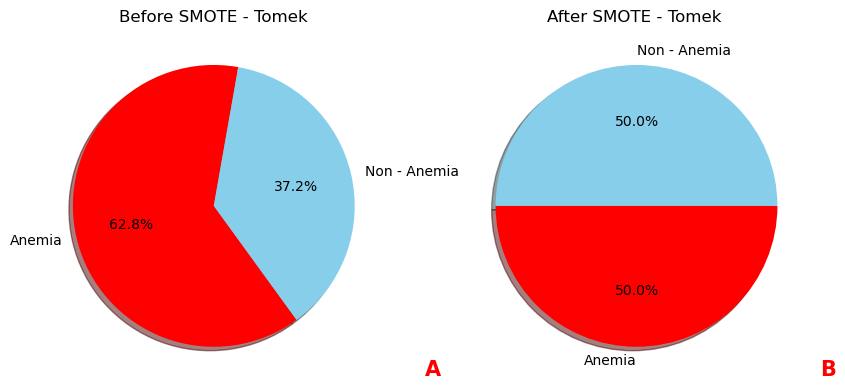

In [2]:
import matplotlib.pyplot as plt

# Data before SMOTE (A)
labels_A = ['Anemia', 'Non - Anemia']
sizes_A = [62.77, 37.23]  # Imbalanced percentages
colors_A = ['red', 'skyblue']

# Data after SMOTE (B)
labels_B = ['Anemia', 'Non - Anemia']
sizes_B = [50.0, 50.0]  # Balanced after SMOTE
colors_B = ['red', 'skyblue']

# Create figure and subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Pie Chart A (Before SMOTE)
axes[0].pie(sizes_A, labels=labels_A, autopct='%1.1f%%', colors=colors_A, shadow=True, startangle=80)
axes[0].set_title("Before SMOTE - Tomek")

# Pie Chart B (After SMOTE)
axes[1].pie(sizes_B, labels=labels_B, autopct='%1.1f%%', colors=colors_B, shadow=True, startangle=180)
axes[1].set_title("After SMOTE - Tomek ")

# Add labels
plt.text(-1.5, -1.2, "A", fontsize=15, color='red', fontweight='bold')
plt.text(1.3, -1.2, "B", fontsize=15, color='red', fontweight='bold')

# Display the charts
plt.show()


In [20]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
import numpy as np
import matplotlib.pyplot as plt

def select_features(X_train, y_train, X_test, k='all'):
    fs = SelectKBest(score_func=mutual_info_classif, k=k)  
    fs.fit(X_train, y_train)
    X_train_fs = fs.transform(X_train)
    X_test_fs = fs.transform(X_test)
    return X_train_fs, X_test_fs, fs

#output
X_train_fs, X_test_fs, fs = select_features(X_train_resampled, y_train_resampled, X_test_scaled)

#what are scores for the features
for i, score in enumerate(fs.scores_):
    print(f"Feature {i}: Score={score:.3f}")




Feature 0: Score=0.043
Feature 1: Score=0.071
Feature 2: Score=0.118
Feature 3: Score=0.694
Feature 4: Score=0.154
Feature 5: Score=0.368
Feature 6: Score=0.071
Feature 7: Score=0.126
Feature 8: Score=0.149


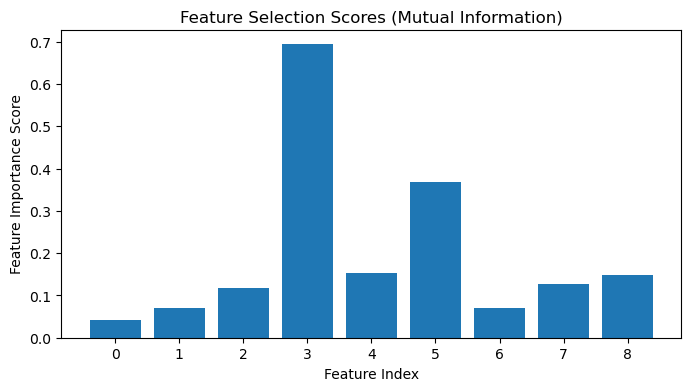

In [22]:
# Plot feature importance
plt.figure(figsize=(8, 4))
plt.bar(range(len(fs.scores_)), fs.scores_)
plt.xticks(range(len(fs.scores_)), labels=range(len(fs.scores_)))
plt.xlabel("Feature Index")
plt.ylabel("Feature Importance Score")
plt.title("Feature Selection Scores (Mutual Information)")
plt.show()


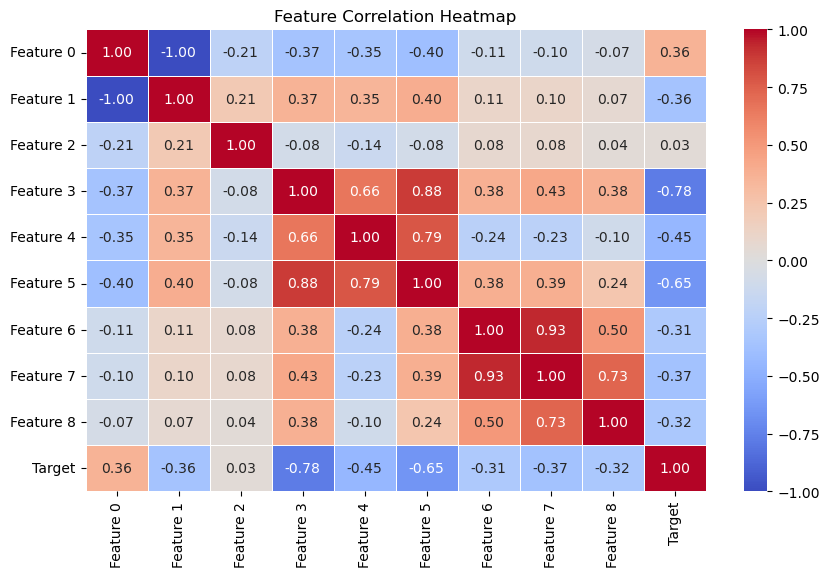

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert features into a DataFrame (if it's not already)
df_features = pd.DataFrame(X_train_fs, columns=[f"Feature {i}" for i in range(X_train_fs.shape[1])])
df_features['Target'] = y_train_resampled  # Add the target variable

# Compute correlation matrix
correlation_matrix = df_features.corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


In [28]:
pip install mlxtend


   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   -- ------------------------------------- 0.1/1.4 MB 991.0 kB/s eta 0:00:02
   ------ --------------------------------- 0.2/1.4 MB 1.7 MB/s eta 0:00:01
   -------------- ------------------------- 0.5/1.4 MB 2.9 MB/s eta 0:00:01
   -------------------------- ------------- 0.9/1.4 MB 4.1 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 5.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [30]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.preprocessing import Binarizer

# 1. Binarize the continuous features
binarizer = Binarizer(threshold=0)  # Set threshold (e.g., 0 or median value)
X_train_bin = binarizer.fit_transform(X_train_fs)

# 2. Convert to DataFrame for mlxtend
# You need feature names, let's assume you have them in a list called "feature_names"
feature_names = [f'Feature_{i}' for i in range(X_train_fs.shape[1])]
X_train_df = pd.DataFrame(X_train_bin, columns=feature_names)

# 3. Apply Apriori algorithm to find frequent itemsets
frequent_itemsets = apriori(X_train_df, min_support=0.2, use_colnames=True)

# 4. Generate association rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)

# 5. Display results
print("Frequent Itemsets:")
print(frequent_itemsets)

print("\nAssociation Rules:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])


Frequent Itemsets:
      support                                           itemsets
0    0.631846                                        (Feature_0)
1    0.371197                                        (Feature_1)
2    0.410751                                        (Feature_2)
3    0.604462                                        (Feature_3)
4    0.534483                                        (Feature_4)
..        ...                                                ...
116  0.231237  (Feature_8, Feature_7, Feature_4, Feature_3, F...
117  0.210953  (Feature_8, Feature_7, Feature_6, Feature_4, F...
118  0.323529  (Feature_8, Feature_7, Feature_6, Feature_3, F...
119  0.218053  (Feature_8, Feature_7, Feature_6, Feature_4, F...
120  0.210953  (Feature_8, Feature_7, Feature_6, Feature_4, F...

[121 rows x 2 columns]

Association Rules:
                           antecedents  \
0                          (Feature_6)   
1                          (Feature_8)   
2                          (Fea

C:\Users\HungPhatPC\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


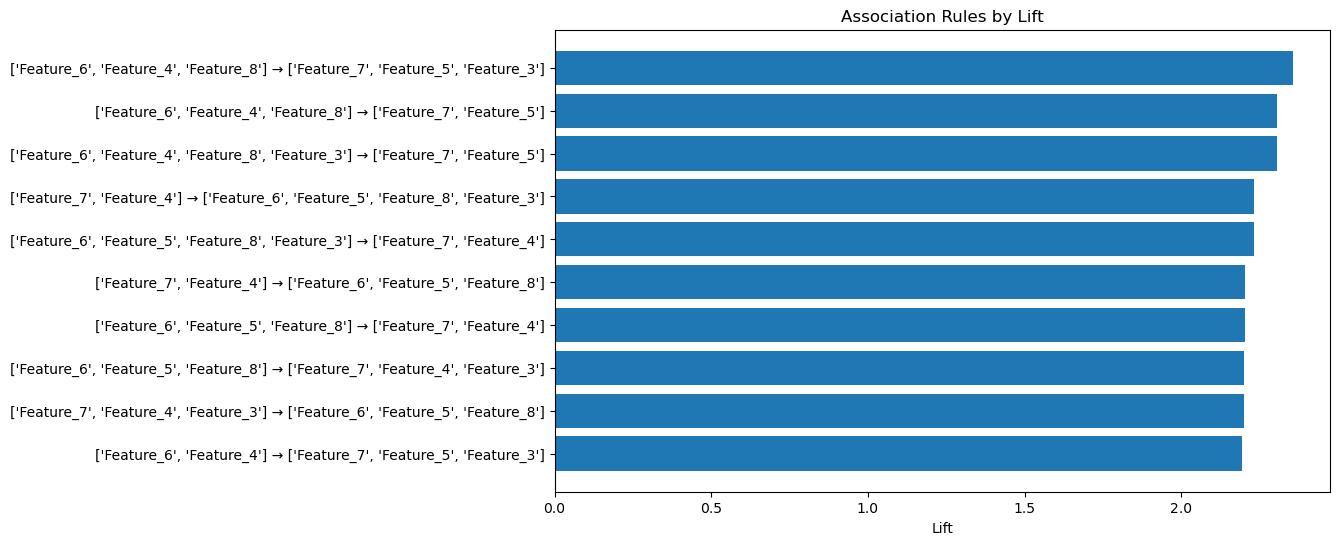

In [54]:
import matplotlib.pyplot as plt

# Sort by Lift
top_rules = rules.sort_values('lift', ascending=False).head(10)

# Plot
plt.figure(figsize=(10,6))
plt.barh(range(len(top_rules)), top_rules['lift'], align='center')
plt.yticks(range(len(top_rules)), [f"{list(a)} → {list(c)}" for a, c in zip(top_rules['antecedents'], top_rules['consequents'])])
plt.xlabel('Lift')
plt.title('Association Rules by Lift')
plt.gca().invert_yaxis()
plt.show()


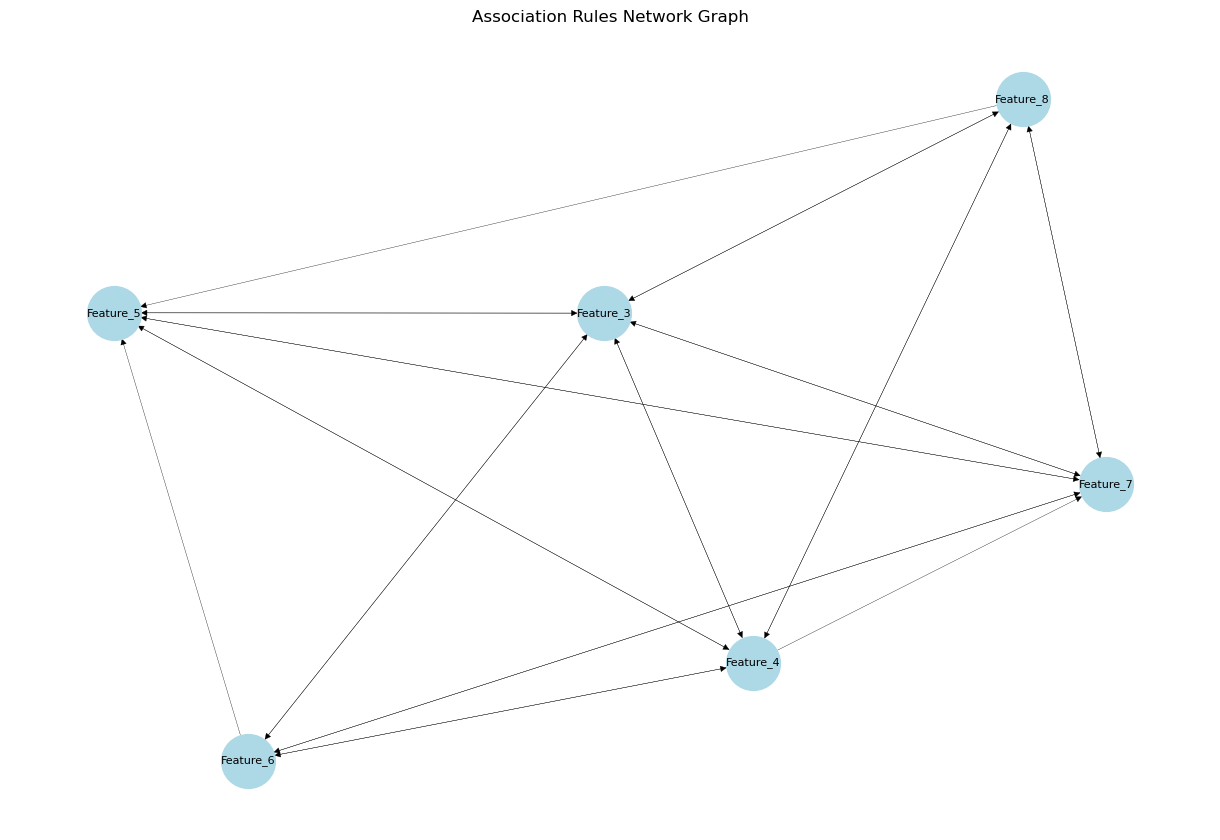

In [40]:
import networkx as nx

# Create Graph
G = nx.DiGraph()

# Add edges
for idx, row in top_rules.iterrows():
    for antecedent in row['antecedents']:
        for consequent in row['consequents']:
            G.add_edge(antecedent, consequent, weight=row['lift'])

# Draw graph
plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, k=0.5)
nx.draw(G, pos, with_labels=True, node_size=1500, node_color="lightblue", font_size=8, width=0.25, arrows=True)
plt.title('Association Rules Network Graph')
plt.show()


In [32]:
# Remove Feature 3 (index 3) from training and test sets
X_train_fs_new = np.delete(X_train_fs, 3, axis=1)
X_test_fs_new = np.delete(X_test_fs, 3, axis=1)

print("Shape after removing Feature 3:")
print("X_train_fs_new:", X_train_fs_new.shape)
print("X_test_fs_new:", X_test_fs_new.shape)


Shape after removing Feature 3:
X_train_fs_new: (986, 8)
X_test_fs_new: (200, 8)


In [74]:
dataset = pd.DataFrame(X_test_fs_new)
dataset

,0,1,2,3,4,5,6,7
0,1.0,0.0,-0.726077,-0.783445,-0.687355,0.105553,0.293962,0.711759
1,1.0,0.0,0.275948,-0.536327,-0.067581,0.719960,0.807498,0.638796
2,1.0,0.0,0.589081,0.040280,0.035714,-0.035248,-0.098742,-0.163803
3,1.0,0.0,0.902214,-1.524797,-0.914605,1.116764,1.109578,0.565832
4,0.0,1.0,1.215347,1.045224,1.357898,0.387156,0.716874,1.222504
...,...,...,...,...,...,...,...,...
195,1.0,0.0,0.589081,-0.289210,-0.067581,0.297555,0.505418,0.857687
196,1.0,0.0,1.841613,-1.393001,-0.439445,1.705570,1.804362,1.076577
197,1.0,0.0,-0.350317,0.534515,0.242306,-0.432053,0.022090,1.295468
198,1.0,0.0,-0.851330,-1.047036,-0.336150,1.206365,1.502282,1.441395


# Imbalanced Multi Models

##  Imbalanced Logistic Regression

In [61]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import RandomUnderSampler 
from collections import Counter
import pandas as pd

# Simulating dataset distribution before SMOTE balancing
class_distribution = {"- Imbalanced Data": Counter({1: 502, 0: 298})}

# Applying SMOTE - Standard
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train_enc)

# Applying SMOTE - Tomek ✅ (NEW)
smote_tomek = SMOTETomek(random_state=42)
X_train_tomek, y_train_tomek = smote_tomek.fit_resample(X_train_scaled, y_train_enc)

# Applying ADASYN
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_scaled, y_train_enc)

# Applying Under-sampling
under_sampler = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = under_sampler.fit_resample(X_train_scaled, y_train_enc)

# Applying Over-sampling
over_sampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = over_sampler.fit_resample(X_train_scaled, y_train_enc)

# Updating class distribution
class_distribution["+ SMOTE"] = Counter(y_train_smote)
class_distribution["+ SMOTE-Tomek"] = Counter(y_train_tomek)  # ✅ Added SMOTE-Tomek
class_distribution["+ ADASYN"] = Counter(y_train_adasyn)
class_distribution["+ Under-sampling"] = Counter(y_train_under)
class_distribution["+ Over-sampling"] = Counter(y_train_over)

# Convert to DataFrame for visualization
df_class_dist = pd.DataFrame.from_dict(class_distribution, orient='index')
df_class_dist.columns = ['Class 0', 'Class 1']

# Debugging prints
print("Class distribution before and after SMOTE, SMOTE-Tomek, ADASYN, Under-sampling, Over-sampling:")
print(df_class_dist)

# Function to evaluate model performance
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    return accuracy, auc, precision, recall, f1

# Train and evaluate models
results = []

for technique, (X_train_resampled, y_train_resampled) in {
    "+ SMOTE - Standard": (X_train_smote, y_train_smote),
    "+ SMOTE-Tomek": (X_train_tomek, y_train_tomek),
    "+ ADASYN": (X_train_adasyn, y_train_adasyn),
    "+ Under-sampling": (X_train_under, y_train_under),
    "+ Over-sampling": (X_train_over, y_train_over)
}.items():
    
    classifier_lr = LogisticRegression(class_weight='balanced', random_state=0)
    classifier_lr.fit(X_train_resampled, y_train_resampled)
    
    acc, auc, precision, recall, f1 = evaluate_model(classifier_lr, X_test_scaled, y_test_enc)
    
    results.append([technique, acc, auc, precision, recall, f1])

# Convert results to DataFrame
results_df = pd.DataFrame(results, columns=["Technique", "Accuracy", "AUC", "Precision", "Recall", "F1-Score"])

# Display results in tabular format
print("\n - Final Results for Logistic Regression with SMOTE - Standard, SMOTE-Tomek, ADASYN, Under-sampling, and Over-sampling:")
print(results_df.to_string(index=False))


Class distribution before and after SMOTE, SMOTE-Tomek, ADASYN, Under-sampling, Over-sampling:
                   Class 0  Class 1
- Imbalanced Data      502      298
+ SMOTE                502      502
+ SMOTE-Tomek          493      493
+ ADASYN               502      502
+ Under-sampling       298      298
+ Over-sampling        502      502

 - Final Results for Logistic Regression with SMOTE - Standard, SMOTE-Tomek, ADASYN, Under-sampling, and Over-sampling:
         Technique  Accuracy      AUC  Precision   Recall  F1-Score
+ SMOTE - Standard     0.975 0.998703   0.992647 0.971223  0.981818
     + SMOTE-Tomek     0.970 0.997995   0.992593 0.964029  0.978102
          + ADASYN     0.970 0.998821   1.000000 0.956835  0.977941
  + Under-sampling     0.970 0.997405   1.000000 0.956835  0.977941
   + Over-sampling     0.975 0.998703   1.000000 0.964029  0.981685


In [30]:
# Train logistic regression on imbalanced data
classifier_lr = LogisticRegression(class_weight=None, random_state=0)
classifier_lr.fit(X_train_scaled, y_train_enc)

# Predict on test set
y_pred_imbalanced = classifier_lr.predict(X_test_scaled)
y_prob_imbalanced = classifier_lr.predict_proba(X_test_scaled)[:, 1]

# Evaluate
acc_imbalanced = accuracy_score(y_test_enc, y_pred_imbalanced)
auc_imbalanced = roc_auc_score(y_test_enc, y_prob_imbalanced)

print(f"Imbalanced Data Accuracy: {acc_imbalanced:.3f}")
print(f"Imbalanced Data AUC: {auc_imbalanced:.3f}")


Imbalanced Data Accuracy: 0.985
Imbalanced Data AUC: 0.999


In [66]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek, SMOTEENN
from collections import Counter
import pandas as pd

# Simulating original class distribution
class_distribution = {"- Imbalanced Data": Counter({1: 502, 0: 298})}

# ✅ 1. SMOTE - Standard
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train_enc)

# ✅ 2. SMOTE-Tomek
smote_tomek = SMOTETomek(random_state=42)
X_train_tomek, y_train_tomek = smote_tomek.fit_resample(X_train_scaled, y_train_enc)

# ✅ 3. SMOTE-ENN
smote_enn = SMOTEENN(random_state=42)
X_train_smoteenn, y_train_smoteenn = smote_enn.fit_resample(X_train_scaled, y_train_enc)

# ✅ 4. ADASYN (standalone)
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_scaled, y_train_enc)

# Update class distribution
class_distribution["+ SMOTE"] = Counter(y_train_smote)
class_distribution["+ SMOTE-Tomek"] = Counter(y_train_tomek)
class_distribution["+ SMOTE-ENN"] = Counter(y_train_smoteenn)
class_distribution["+ ADASYN"] = Counter(y_train_adasyn)

# Visualize class distributions
df_class_dist = pd.DataFrame.from_dict(class_distribution, orient='index')
df_class_dist.columns = ['Class 0', 'Class 1']
print("Class distribution before and after resampling techniques:")
print(df_class_dist)

# Evaluation Function
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    return accuracy, auc, precision, recall, f1

# Model Training & Evaluation
results = []
resampled_sets = {
    "+ SMOTE - Standard": (X_train_smote, y_train_smote),
    "+ SMOTE-Tomek": (X_train_tomek, y_train_tomek),
    "+ SMOTE-ENN": (X_train_smoteenn, y_train_smoteenn),
    "+ ADASYN": (X_train_adasyn, y_train_adasyn)
}

for technique, (X_res, y_res) in resampled_sets.items():
    model = LogisticRegression(class_weight='balanced', random_state=0)
    model.fit(X_res, y_res)
    
    acc, auc, precision, recall, f1 = evaluate_model(model, X_test_scaled, y_test_enc)
    results.append([technique, acc, auc, precision, recall, f1])

# Results
results_df = pd.DataFrame(results, columns=["Technique", "Accuracy", "AUC", "Precision", "Recall", "F1-Score"])
print("\n✅ Final Results for Logistic Regression with SMOTE and ADASYN techniques:")
print(results_df.to_string(index=False))


Class distribution before and after resampling techniques:
                   Class 0  Class 1
- Imbalanced Data      502      298
+ SMOTE                502      502
+ SMOTE-Tomek          493      493
+ SMOTE-ENN            417      452
+ ADASYN               502      502

✅ Final Results for Logistic Regression with SMOTE and ADASYN techniques:
         Technique  Accuracy      AUC  Precision   Recall  F1-Score
+ SMOTE - Standard     0.975 0.998703   0.992647 0.971223  0.981818
     + SMOTE-Tomek     0.970 0.997995   0.992593 0.964029  0.978102
       + SMOTE-ENN     0.940 0.983607   1.000000 0.913669  0.954887
          + ADASYN     0.970 0.998821   1.000000 0.956835  0.977941


## Imbalanced GNB

In [63]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Simulating dataset distribution before balancing
class_distribution = {"Imbalanced Data": Counter({1: 502, 0: 298})}

# Applying SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train_enc)

# Applying SMOTE-Tomek ✅ (NEW)
smote_tomek = SMOTETomek(random_state=42)
X_train_tomek, y_train_tomek = smote_tomek.fit_resample(X_train_scaled, y_train_enc)

# Applying ADASYN
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_scaled, y_train_enc)

# Applying Under-sampling
under_sampler = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = under_sampler.fit_resample(X_train_scaled, y_train_enc)

# Applying Over-sampling
over_sampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = over_sampler.fit_resample(X_train_scaled, y_train_enc)

# Updating class distribution
class_distribution["SMOTE"] = Counter(y_train_smote)
class_distribution["+ SMOTE-Tomek"] = Counter(y_train_tomek)  # ✅ Added SMOTE-Tomek
class_distribution["ADASYN"] = Counter(y_train_adasyn)
class_distribution["Under-sampling"] = Counter(y_train_under)
class_distribution["Over-sampling"] = Counter(y_train_over)

# Convert to DataFrame for visualization
df_class_dist = pd.DataFrame.from_dict(class_distribution, orient='index')
df_class_dist.columns = ['Class 0', 'Class 1']

# Debugging prints
print("Class distribution before and after SMOTE, SMOTE-Tomek, ADASYN, Under-sampling, Over-sampling:")
print(df_class_dist)

# Function to evaluate model performance
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    return accuracy, auc, precision, recall, f1

# Train and evaluate models
results = []

for technique, (X_train_resampled, y_train_resampled) in {
    "SMOTE": (X_train_smote, y_train_smote),
    "+ SMOTE-Tomek": (X_train_tomek, y_train_tomek),  # ✅ Added SMOTE-Tomek
    "ADASYN": (X_train_adasyn, y_train_adasyn),
    "Under-sampling": (X_train_under, y_train_under),
    "Over-sampling": (X_train_over, y_train_over)
}.items():
    
    classifier_gnb = GaussianNB()
    classifier_gnb.fit(X_train_resampled, y_train_resampled)
    
    acc, auc, precision, recall, f1 = evaluate_model(classifier_gnb, X_test_scaled, y_test_enc)
    
    results.append([technique, acc, auc, precision, recall, f1])

# Convert results to DataFrame
results_df = pd.DataFrame(results, columns=["Technique", "Accuracy", "AUC", "Precision", "Recall", "F1-Score"])

# Display results in tabular format
print("\nFinal Results for Gaussian Naïve Bayes with SMOTE, SMOTE-Tomek, ADASYN, Under-sampling, and Over-sampling:")
print(results_df.to_string(index=False))


Class distribution before and after SMOTE, SMOTE-Tomek, ADASYN, Under-sampling, Over-sampling:
                 Class 0  Class 1
Imbalanced Data      502      298
SMOTE                502      502
+ SMOTE-Tomek        493      493
ADASYN               502      502
Under-sampling       298      298
Over-sampling        502      502

Final Results for Gaussian Naïve Bayes with SMOTE, SMOTE-Tomek, ADASYN, Under-sampling, and Over-sampling:
     Technique  Accuracy      AUC  Precision   Recall  F1-Score
         SMOTE     0.915 0.971813        1.0 0.877698  0.934866
 + SMOTE-Tomek     0.915 0.971459        1.0 0.877698  0.934866
        ADASYN     0.885 0.973464        1.0 0.834532  0.909804
Under-sampling     0.930 0.968982        1.0 0.899281  0.946970
 Over-sampling     0.920 0.971459        1.0 0.884892  0.938931


In [33]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, roc_auc_score

# Train GNB on imbalanced data
classifier_gnb = GaussianNB()
classifier_gnb.fit(X_train_scaled, y_train_enc)

# Predict on test set
y_pred_imbalanced = classifier_gnb.predict(X_test_scaled)
y_prob_imbalanced = classifier_gnb.predict_proba(X_test_scaled)[:, 1]  # Probability of class 1

# Evaluate
acc_imbalanced = accuracy_score(y_test_enc, y_pred_imbalanced)
auc_imbalanced = roc_auc_score(y_test_enc, y_prob_imbalanced)

print(f"🔹 Imbalanced Data Accuracy (GNB): {acc_imbalanced:.3f}")
print(f"🔹 Imbalanced Data AUC (GNB): {auc_imbalanced:.3f}")


🔹 Imbalanced Data Accuracy (GNB): 0.925
🔹 Imbalanced Data AUC (GNB): 0.972


In [68]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.naive_bayes import GaussianNB
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek, SMOTEENN
from collections import Counter
import pandas as pd

# Simulating original class distribution
class_distribution = {"- Imbalanced Data": Counter({1: 502, 0: 298})}

# ✅ 1. SMOTE - Standard
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train_enc)

# ✅ 2. SMOTE-Tomek
smote_tomek = SMOTETomek(random_state=42)
X_train_tomek, y_train_tomek = smote_tomek.fit_resample(X_train_scaled, y_train_enc)

# ✅ 3. SMOTE-ENN
smote_enn = SMOTEENN(random_state=42)
X_train_smoteenn, y_train_smoteenn = smote_enn.fit_resample(X_train_scaled, y_train_enc)

# ✅ 4. ADASYN (standalone)
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_scaled, y_train_enc)

# Update class distribution
class_distribution["+ SMOTE"] = Counter(y_train_smote)
class_distribution["+ SMOTE-Tomek"] = Counter(y_train_tomek)
class_distribution["+ SMOTE-ENN"] = Counter(y_train_smoteenn)
class_distribution["+ ADASYN"] = Counter(y_train_adasyn)

# Visualize class distributions
df_class_dist = pd.DataFrame.from_dict(class_distribution, orient='index')
df_class_dist.columns = ['Class 0', 'Class 1']
print("Class distribution before and after resampling techniques:")
print(df_class_dist)

# Evaluation Function
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    return accuracy, auc, precision, recall, f1

# Model Training & Evaluation
results = []
resampled_sets = {
    "+ SMOTE - Standard": (X_train_smote, y_train_smote),
    "+ SMOTE-Tomek": (X_train_tomek, y_train_tomek),
    "+ SMOTE-ENN": (X_train_smoteenn, y_train_smoteenn),
    "+ ADASYN": (X_train_adasyn, y_train_adasyn)
}

for technique, (X_res, y_res) in resampled_sets.items():
    model = GaussianNB()
    model.fit(X_res, y_res)
    
    acc, auc, precision, recall, f1 = evaluate_model(model, X_test_scaled, y_test_enc)
    results.append([technique, acc, auc, precision, recall, f1])

# Results
results_df = pd.DataFrame(results, columns=["Technique", "Accuracy", "AUC", "Precision", "Recall", "F1-Score"])
print("\n✅ Final Results for GaussianNB with SMOTE and ADASYN techniques:")
print(results_df.to_string(index=False))


Class distribution before and after resampling techniques:
                   Class 0  Class 1
- Imbalanced Data      502      298
+ SMOTE                502      502
+ SMOTE-Tomek          493      493
+ SMOTE-ENN            417      452
+ ADASYN               502      502

✅ Final Results for GaussianNB with SMOTE and ADASYN techniques:
         Technique  Accuracy      AUC  Precision   Recall  F1-Score
+ SMOTE - Standard     0.915 0.971813        1.0 0.877698  0.934866
     + SMOTE-Tomek     0.915 0.971459        1.0 0.877698  0.934866
       + SMOTE-ENN     0.880 0.966034        1.0 0.827338  0.905512
          + ADASYN     0.885 0.973464        1.0 0.834532  0.909804


## Imbalanced Decision Tree

In [113]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter



# Simulating dataset distribution before balancing
class_distribution = {"Imbalanced Data": Counter({1: 502, 0: 298})}

# Applying SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train_enc)

# Applying SMOTE-Tomek ✅ (NEW)
smote_tomek = SMOTETomek(random_state=42)
X_train_tomek, y_train_tomek = smote_tomek.fit_resample(X_train_scaled, y_train_enc)

# Applying ADASYN
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_scaled, y_train_enc)

# Applying Under-sampling
under_sampler = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = under_sampler.fit_resample(X_train_scaled, y_train_enc)

# Applying Over-sampling
over_sampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = over_sampler.fit_resample(X_train_scaled, y_train_enc)

# Updating class distribution
class_distribution["SMOTE"] = Counter(y_train_smote)
class_distribution["+ SMOTE-Tomek"] = Counter(y_train_tomek)  # ✅ Added SMOTE-Tomek
class_distribution["ADASYN"] = Counter(y_train_adasyn)
class_distribution["Under-sampling"] = Counter(y_train_under)
class_distribution["Over-sampling"] = Counter(y_train_over)

# Convert to DataFrame for visualization
df_class_dist = pd.DataFrame.from_dict(class_distribution, orient='index')
df_class_dist.columns = ['Class 0', 'Class 1']

# Debugging prints
print("Class distribution before and after SMOTE, SMOTE-Tomek, ADASYN, Under-sampling, Over-sampling:")
print(df_class_dist)

# Function to evaluate model performance
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    return accuracy, auc, precision, recall, f1

# Train and evaluate models
results = []

for technique, (X_train_resampled, y_train_resampled) in {
    "SMOTE": (X_train_smote, y_train_smote),
    "+ SMOTE-Tomek": (X_train_tomek, y_train_tomek),  # ✅ Added SMOTE-Tomek
    "ADASYN": (X_train_adasyn, y_train_adasyn),
    "Under-sampling": (X_train_under, y_train_under),
    "Over-sampling": (X_train_over, y_train_over)
}.items():
    
    classifier_dt = DecisionTreeClassifier(class_weight='balanced', random_state=0)
    classifier_dt.fit(X_train_resampled, y_train_resampled)
    
    acc, auc, precision, recall, f1 = evaluate_model(classifier_dt, X_test_scaled, y_test_enc)
    
    results.append([technique, acc, auc, precision, recall, f1])

# Convert results to DataFrame
results_df = pd.DataFrame(results, columns=["Technique", "Accuracy", "AUC", "Precision", "Recall", "F1-Score"])

# Display results in tabular format
print("\nFinal Results for Decision Tree with SMOTE, SMOTE-Tomek, ADASYN, Under-sampling, and Over-sampling:")
print(results_df.to_string(index=False))


Class distribution before and after SMOTE, SMOTE-Tomek, ADASYN, Under-sampling, Over-sampling:
                 Class 0  Class 1
Imbalanced Data      502      298
SMOTE                502      502
+ SMOTE-Tomek        493      493
ADASYN               502      502
Under-sampling       298      298
Over-sampling        502      502

Final Results for Decision Tree with SMOTE, SMOTE-Tomek, ADASYN, Under-sampling, and Over-sampling:
     Technique  Accuracy  AUC  Precision  Recall  F1-Score
         SMOTE       1.0  1.0        1.0     1.0       1.0
 + SMOTE-Tomek       1.0  1.0        1.0     1.0       1.0
        ADASYN       1.0  1.0        1.0     1.0       1.0
Under-sampling       1.0  1.0        1.0     1.0       1.0
 Over-sampling       1.0  1.0        1.0     1.0       1.0


In [123]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek, SMOTEENN
from collections import Counter
import pandas as pd

# Simulating original class distribution
class_distribution = {"Imbalanced": Counter({1: 502, 0: 298})}

# ✅ 1. SMOTE - Standard
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train_enc)

# ✅ 2. SMOTE-Tomek
smote_tomek = SMOTETomek(random_state=42)
X_train_tomek, y_train_tomek = smote_tomek.fit_resample(X_train_scaled, y_train_enc)

# ✅ 3. SMOTE-ENN
smote_enn = SMOTEENN(random_state=42)
X_train_smoteenn, y_train_smoteenn = smote_enn.fit_resample(X_train_scaled, y_train_enc)

# ✅ 4. ADASYN
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_scaled, y_train_enc)

# Update class distribution
class_distribution["SMOTE"] = Counter(y_train_smote)
class_distribution["SMOTE-Tomek"] = Counter(y_train_tomek)
class_distribution["SMOTE-ENN"] = Counter(y_train_smoteenn)
class_distribution["ADASYN"] = Counter(y_train_adasyn)

# Display class distributions
df_class_dist = pd.DataFrame.from_dict(class_distribution, orient='index')
df_class_dist.columns = ['Class 0', 'Class 1']
print("\n📊 Class distribution before and after resampling techniques:")
print(df_class_dist)

# Evaluation Function
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    return accuracy, auc, precision, recall, f1

# ✅ Model Training & Evaluation with pruned Decision Tree
results = []
resampled_sets = {
    "SMOTE": (X_train_smote, y_train_smote),
    "SMOTE-Tomek": (X_train_tomek, y_train_tomek),
    "SMOTE-ENN": (X_train_smoteenn, y_train_smoteenn),
    "ADASYN": (X_train_adasyn, y_train_adasyn)
}

for technique, (X_res, y_res) in resampled_sets.items():
    model = DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    )
    
    model.fit(X_res, y_res)
    acc, auc, precision, recall, f1 = evaluate_model(model, X_test_scaled, y_test_enc)
    results.append([technique, acc, auc, precision, recall, f1])

# Format and display results
results_df = pd.DataFrame(results, columns=["Technique", "Accuracy", "AUC", "Precision", "Recall", "F1-Score"])
print("\n✅ Final Results for Pruned Decision Tree with Resampling Techniques:")
print(results_df.to_string(index=False))



📊 Class distribution before and after resampling techniques:
             Class 0  Class 1
Imbalanced       502      298
SMOTE            502      502
SMOTE-Tomek      493      493
SMOTE-ENN        417      452
ADASYN           502      502

✅ Final Results for Pruned Decision Tree with Resampling Techniques:
  Technique  Accuracy  AUC  Precision  Recall  F1-Score
      SMOTE       1.0  1.0        1.0     1.0       1.0
SMOTE-Tomek       1.0  1.0        1.0     1.0       1.0
  SMOTE-ENN       1.0  1.0        1.0     1.0       1.0
     ADASYN       1.0  1.0        1.0     1.0       1.0


## Imbalanced SVM

In [67]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Simulating dataset distribution before balancing
class_distribution = {"Imbalanced Data": Counter({1: 502, 0: 298})}

# Applying SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train_enc)

# Applying SMOTE-Tomek ✅ (NEW)
smote_tomek = SMOTETomek(random_state=42)
X_train_tomek, y_train_tomek = smote_tomek.fit_resample(X_train_scaled, y_train_enc)

# Applying ADASYN
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_scaled, y_train_enc)

# Applying Under-sampling
under_sampler = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = under_sampler.fit_resample(X_train_scaled, y_train_enc)

# Applying Over-sampling
over_sampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = over_sampler.fit_resample(X_train_scaled, y_train_enc)

# Updating class distribution
class_distribution["SMOTE"] = Counter(y_train_smote)
class_distribution["+ SMOTE-Tomek"] = Counter(y_train_tomek)  # ✅ Added SMOTE-Tomek
class_distribution["ADASYN"] = Counter(y_train_adasyn)
class_distribution["Under-sampling"] = Counter(y_train_under)
class_distribution["Over-sampling"] = Counter(y_train_over)

# Convert to DataFrame for visualization
df_class_dist = pd.DataFrame.from_dict(class_distribution, orient='index')
df_class_dist.columns = ['Class 0', 'Class 1']

# Debugging prints
print("Class distribution before and after SMOTE, SMOTE-Tomek, ADASYN, Under-sampling, Over-sampling:")
print(df_class_dist)

# Function to evaluate model performance
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    return accuracy, auc, precision, recall, f1

# Train and evaluate models
results = []

for technique, (X_train_resampled, y_train_resampled) in {
    "SMOTE": (X_train_smote, y_train_smote),
    "+ SMOTE-Tomek": (X_train_tomek, y_train_tomek),  # ✅ Added SMOTE-Tomek
    "ADASYN": (X_train_adasyn, y_train_adasyn),
    "Under-sampling": (X_train_under, y_train_under),
    "Over-sampling": (X_train_over, y_train_over)
}.items():
    
    classifier_svm = SVC(class_weight='balanced', probability=True, random_state=0)
    classifier_svm.fit(X_train_resampled, y_train_resampled)
    
    acc, auc, precision, recall, f1 = evaluate_model(classifier_svm, X_test_scaled, y_test_enc)
    
    results.append([technique, acc, auc, precision, recall, f1])

# Convert results to DataFrame
results_df = pd.DataFrame(results, columns=["Technique", "Accuracy", "AUC", "Precision", "Recall", "F1-Score"])

# Display results in tabular format
print("\nFinal Results for SVM with SMOTE, SMOTE-Tomek, ADASYN, Under-sampling, and Over-sampling:")
print(results_df.to_string(index=False))


Class distribution before and after SMOTE, SMOTE-Tomek, ADASYN, Under-sampling, Over-sampling:
                 Class 0  Class 1
Imbalanced Data      502      298
SMOTE                502      502
+ SMOTE-Tomek        493      493
ADASYN               502      502
Under-sampling       298      298
Over-sampling        502      502

Final Results for SVM with SMOTE, SMOTE-Tomek, ADASYN, Under-sampling, and Over-sampling:
     Technique  Accuracy      AUC  Precision   Recall  F1-Score
         SMOTE     0.950 0.997641   0.992366 0.935252  0.962963
 + SMOTE-Tomek     0.950 0.997287   0.992366 0.935252  0.962963
        ADASYN     0.940 0.997405   0.992248 0.920863  0.955224
Under-sampling     0.935 0.995636   0.992188 0.913669  0.951311
 Over-sampling     0.940 0.996462   0.992248 0.920863  0.955224


In [39]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score

# Train SVM on imbalanced data
classifier_svm = SVC(probability=True, random_state=0)  # Enable probability for AUC calculation
classifier_svm.fit(X_train_scaled, y_train_enc)

# Predict on test set
y_pred_imbalanced = classifier_svm.predict(X_test_scaled)
y_prob_imbalanced = classifier_svm.predict_proba(X_test_scaled)[:, 1]  # Probability of class 1

# Evaluate
acc_imbalanced = accuracy_score(y_test_enc, y_pred_imbalanced)
auc_imbalanced = roc_auc_score(y_test_enc, y_prob_imbalanced)

print(f"🔹 Imbalanced Data Accuracy (SVM): {acc_imbalanced:.3f}")
print(f"🔹 Imbalanced Data AUC (SVM): {auc_imbalanced:.3f}")


🔹 Imbalanced Data Accuracy (SVM): 0.970
🔹 Imbalanced Data AUC (SVM): 0.996


In [76]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek, SMOTEENN
from collections import Counter
import pandas as pd

# Simulating original class distribution
class_distribution = {"- Imbalanced Data": Counter({1: 502, 0: 298})}

# ✅ 1. SMOTE - Standard
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train_enc)

# ✅ 2. SMOTE-Tomek
smote_tomek = SMOTETomek(random_state=42)
X_train_tomek, y_train_tomek = smote_tomek.fit_resample(X_train_scaled, y_train_enc)

# ✅ 3. SMOTE-ENN
smote_enn = SMOTEENN(random_state=42)
X_train_smoteenn, y_train_smoteenn = smote_enn.fit_resample(X_train_scaled, y_train_enc)

# ✅ 4. ADASYN
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_scaled, y_train_enc)

# Update class distribution
class_distribution["+ SMOTE"] = Counter(y_train_smote)
class_distribution["+ SMOTE-Tomek"] = Counter(y_train_tomek)
class_distribution["+ SMOTE-ENN"] = Counter(y_train_smoteenn)
class_distribution["+ ADASYN"] = Counter(y_train_adasyn)

# Show distributions
df_class_dist = pd.DataFrame.from_dict(class_distribution, orient='index')
df_class_dist.columns = ['Class 0', 'Class 1']
print("Class distribution before and after resampling techniques:")
print(df_class_dist)

# Evaluation Function
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    return accuracy, auc, precision, recall, f1

# Model Training & Evaluation
results = []
resampled_sets = {
    "+ SMOTE - Standard": (X_train_smote, y_train_smote),
    "+ SMOTE-Tomek": (X_train_tomek, y_train_tomek),
    "+ SMOTE-ENN": (X_train_smoteenn, y_train_smoteenn),
    "+ ADASYN": (X_train_adasyn, y_train_adasyn)
}

for technique, (X_res, y_res) in resampled_sets.items():
    model = SVC(probability=True, class_weight='balanced', random_state=0)
    model.fit(X_res, y_res)
    
    acc, auc, precision, recall, f1 = evaluate_model(model, X_test_scaled, y_test_enc)
    results.append([technique, acc, auc, precision, recall, f1])

# Results
results_df = pd.DataFrame(results, columns=["Technique", "Accuracy", "AUC", "Precision", "Recall", "F1-Score"])
print("\n✅ Final Results for SVM with SMOTE and ADASYN techniques:")
print(results_df.to_string(index=False))


Class distribution before and after resampling techniques:
                   Class 0  Class 1
- Imbalanced Data      502      298
+ SMOTE                502      502
+ SMOTE-Tomek          493      493
+ SMOTE-ENN            417      452
+ ADASYN               502      502

✅ Final Results for SVM with SMOTE and ADASYN techniques:
         Technique  Accuracy      AUC  Precision   Recall  F1-Score
+ SMOTE - Standard     0.950 0.997641   0.992366 0.935252  0.962963
     + SMOTE-Tomek     0.950 0.997287   0.992366 0.935252  0.962963
       + SMOTE-ENN     0.925 0.987852   1.000000 0.892086  0.942966
          + ADASYN     0.940 0.997405   0.992248 0.920863  0.955224


## Imbalanced KAN

In [79]:
from kan import *
torch.set_default_dtype(torch.float64)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# create a KAN: 2D inputs, 1D output, and 5 hidden neurons. cubic spline (k=3), 5 grid intervals (grid=5).
model = KAN(width=[2,5,1], grid=3, k=3, seed=42, device=device)

cpu
checkpoint directory created: ./model
saving model version 0.0


In [121]:
import torch
import numpy as np
import pandas as pd
from collections import Counter
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

# Simulating dataset distribution before balancing
class_distribution = {"Imbalanced Data": Counter({1: 502, 0: 298})}

# Applying different balancing techniques
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train_enc)

smote_tomek = SMOTETomek(random_state=42)
X_train_tomek, y_train_tomek = smote_tomek.fit_resample(X_train_scaled, y_train_enc)

adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_scaled, y_train_enc)

under_sampler = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = under_sampler.fit_resample(X_train_scaled, y_train_enc)

over_sampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = over_sampler.fit_resample(X_train_scaled, y_train_enc)

# Updating class distribution
class_distribution.update({
    "SMOTE": Counter(y_train_smote),
    "SMOTE-Tomek": Counter(y_train_tomek),
    "ADASYN": Counter(y_train_adasyn),
    "Under-sampling": Counter(y_train_under),
    "Over-sampling": Counter(y_train_over)
})

# Convert to DataFrame for visualization
df_class_dist = pd.DataFrame.from_dict(class_distribution, orient='index')
df_class_dist.columns = ['Class 0', 'Class 1']
print("\nClass distribution before and after SMOTE, SMOTE-Tomek, ADASYN, Under-sampling, and Over-sampling:")
print(df_class_dist)

# Define KAN model (Ensure KAN is properly instantiated)
kan_model = KAN(width=[X_train_scaled.shape[1], 5, 1], grid=3, seed=42, device='cpu')

criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(kan_model.parameters(), lr=0.001)

# Function to train KAN model
def train_kan(X_train, y_train):
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    
    epochs = 100
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = kan_model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        loss.backward()
        optimizer.step()
        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.2f}")
    print("Training complete!")

# Train and evaluate on different datasets
results = []
for technique, (X_train_bal, y_train_bal) in zip(
    ["Imbalanced", "SMOTE", "SMOTE-Tomek", "ADASYN", "Under-sampling", "Over-sampling"],
    [(X_train_scaled, y_train_enc), (X_train_smote, y_train_smote), (X_train_tomek, y_train_tomek),
     (X_train_adasyn, y_train_adasyn), (X_train_under, y_train_under), (X_train_over, y_train_over)]
):
    print(f"\nTraining KAN with {technique} dataset...")
    train_kan(X_train_bal, y_train_bal)
    
    # Convert test data
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test_enc, dtype=torch.float32).view(-1, 1)
    
    with torch.no_grad():
        y_pred_logits = kan_model(X_test_tensor)
        y_pred_prob = torch.sigmoid(y_pred_logits)
        y_pred_label = (y_pred_prob > 0.5).float()
    
    # Convert to NumPy arrays
    y_pred_np = y_pred_label.numpy()
    y_prob_np = y_pred_prob.numpy()

    # Compute metrics
    acc = accuracy_score(y_test_enc, y_pred_np)
    auc = roc_auc_score(y_test_enc, y_prob_np)
    precision = precision_score(y_test_enc, y_pred_np)
    recall = recall_score(y_test_enc, y_pred_np)
    f1 = f1_score(y_test_enc, y_pred_np)

    results.append([technique, acc, auc, precision, recall, f1])

# Convert results to DataFrame
results_df = pd.DataFrame(results, columns=["Technique", "Accuracy", "AUC", "Precision", "Recall", "F1-Score"])

# Display results in tabular format
print("\nFinal Results for KAN with different balancing techniques:")
print(results_df.to_string(index=False))



Class distribution before and after SMOTE, SMOTE-Tomek, ADASYN, Under-sampling, and Over-sampling:
                 Class 0  Class 1
Imbalanced Data      502      298
SMOTE                502      502
SMOTE-Tomek          493      493
ADASYN               502      502
Under-sampling       298      298
Over-sampling        502      502
checkpoint directory created: ./model
saving model version 0.0

Training KAN with Imbalanced dataset...
Epoch [10/100], Loss: 0.68
Epoch [20/100], Loss: 0.67
Epoch [30/100], Loss: 0.65
Epoch [40/100], Loss: 0.64
Epoch [50/100], Loss: 0.62
Epoch [60/100], Loss: 0.61
Epoch [70/100], Loss: 0.59
Epoch [80/100], Loss: 0.57
Epoch [90/100], Loss: 0.55
Epoch [100/100], Loss: 0.53
Training complete!

Training KAN with SMOTE dataset...
Epoch [10/100], Loss: 0.51
Epoch [20/100], Loss: 0.49
Epoch [30/100], Loss: 0.46
Epoch [40/100], Loss: 0.44
Epoch [50/100], Loss: 0.42
Epoch [60/100], Loss: 0.40
Epoch [70/100], Loss: 0.38
Epoch [80/100], Loss: 0.36
Epoch [90/100], 

In [83]:
import torch
import numpy as np
import pandas as pd
from collections import Counter
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek, SMOTEENN
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

# === Simulate class distribution before balancing ===
class_distribution = {"Imbalanced Data": Counter({1: 502, 0: 298})}

# === Apply balancing techniques ===
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train_enc)

smote_tomek = SMOTETomek(random_state=42)
X_train_tomek, y_train_tomek = smote_tomek.fit_resample(X_train_scaled, y_train_enc)

adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_scaled, y_train_enc)

smote_enn = SMOTEENN(random_state=42)
X_train_smoteenn, y_train_smoteenn = smote_enn.fit_resample(X_train_scaled, y_train_enc)

# === Update class distributions for reporting ===
class_distribution.update({
    "SMOTE": Counter(y_train_smote),
    "SMOTE-Tomek": Counter(y_train_tomek),
    "ADASYN": Counter(y_train_adasyn),
    "SMOTE-ENN": Counter(y_train_smoteenn)
})

# === Visualize class distributions ===
df_class_dist = pd.DataFrame.from_dict(class_distribution, orient='index')
df_class_dist.columns = ['Class 0', 'Class 1']
print("\n📊 Class distribution before and after resampling techniques:")
print(df_class_dist)

# === Define KAN model class (ensure KAN is imported properly) ===
from kan import KAN  # Update this import based on your implementation

# === Training function ===
def train_kan(model, optimizer, X_train, y_train):
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

    for epoch in range(100):
        optimizer.zero_grad()
        outputs = model(X_train_tensor)
        loss = torch.nn.BCEWithLogitsLoss()(outputs, y_train_tensor)
        loss.backward()
        optimizer.step()
        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/100], Loss: {loss.item():.4f}")
    print("✅ Training complete!")

# === Train & Evaluate on all datasets ===
results = []
datasets = {
    "Imbalanced": (X_train_scaled, y_train_enc),
    "SMOTE": (X_train_smote, y_train_smote),
    "SMOTE-Tomek": (X_train_tomek, y_train_tomek),
    "ADASYN": (X_train_adasyn, y_train_adasyn),
    "SMOTE-ENN": (X_train_smoteenn, y_train_smoteenn)
}

for technique, (X_train_bal, y_train_bal) in datasets.items():
    print(f"\n🚀 Training KAN on {technique} data...")
    
    model = KAN(width=[X_train_bal.shape[1], 5, 1], grid=3, seed=42, device='cpu')
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    train_kan(model, optimizer, X_train_bal, y_train_bal)

    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test_enc, dtype=torch.float32).view(-1, 1)

    with torch.no_grad():
        y_pred_logits = model(X_test_tensor)
        y_pred_prob = torch.sigmoid(y_pred_logits)
        y_pred_label = (y_pred_prob > 0.5).float()

    y_pred_np = y_pred_label.numpy()
    y_prob_np = y_pred_prob.numpy()

    acc = accuracy_score(y_test_enc, y_pred_np)
    auc = roc_auc_score(y_test_enc, y_prob_np)
    precision = precision_score(y_test_enc, y_pred_np)
    recall = recall_score(y_test_enc, y_pred_np)
    f1 = f1_score(y_test_enc, y_pred_np)

    results.append([technique, acc, auc, precision, recall, f1])

# === Final Results ===
results_df = pd.DataFrame(results, columns=["Technique", "Accuracy", "AUC", "Precision", "Recall", "F1-Score"])
print("\n✅ Final Results for KAN with selected resampling techniques:")
print(results_df.to_string(index=False))



📊 Class distribution before and after resampling techniques:
                 Class 0  Class 1
Imbalanced Data      502      298
SMOTE                502      502
SMOTE-Tomek          493      493
ADASYN               502      502
SMOTE-ENN            417      452

🚀 Training KAN on Imbalanced data...
checkpoint directory created: ./model
saving model version 0.0
Epoch [10/100], Loss: 0.6788
Epoch [20/100], Loss: 0.6665
Epoch [30/100], Loss: 0.6534
Epoch [40/100], Loss: 0.6395
Epoch [50/100], Loss: 0.6244
Epoch [60/100], Loss: 0.6079
Epoch [70/100], Loss: 0.5900
Epoch [80/100], Loss: 0.5705
Epoch [90/100], Loss: 0.5495
Epoch [100/100], Loss: 0.5271
✅ Training complete!

🚀 Training KAN on SMOTE data...
checkpoint directory created: ./model
saving model version 0.0
Epoch [10/100], Loss: 0.6740
Epoch [20/100], Loss: 0.6616
Epoch [30/100], Loss: 0.6486
Epoch [40/100], Loss: 0.6347
Epoch [50/100], Loss: 0.6198
Epoch [60/100], Loss: 0.6037
Epoch [70/100], Loss: 0.5864
Epoch [80/100], Loss: 

## Imbalanced ANN

In [87]:
import numpy as np
X_train_scaled = np.asarray(X_train_scaled, dtype=np.float32)
X_train_smote = np.asarray(X_train_smote, dtype=np.float32)
X_train_adasyn = np.asarray(X_train_adasyn, dtype=np.float32)
X_train_under = np.asarray(X_train_under, dtype=np.float32)
X_train_over = np.asarray(X_train_over, dtype=np.float32)

y_train_enc = np.asarray(y_train_enc, dtype=np.float32)
y_train_smote = np.asarray(y_train_smote, dtype=np.float32)
y_train_adasyn = np.asarray(y_train_adasyn, dtype=np.float32)
y_train_under = np.asarray(y_train_under, dtype=np.float32)
y_train_over = np.asarray(y_train_over, dtype=np.float32)

X_test_scaled = np.asarray(X_test_scaled, dtype=np.float32)
y_test_enc = np.asarray(y_test_enc, dtype=np.float32)


In [124]:
import torch
import torch.nn as nn
import torch.optim as optim
from collections import Counter
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import accuracy_score, roc_auc_score

# Simulating dataset distribution before balancing
class_distribution = {"Imbalanced Data": Counter({1: 502, 0: 298})}

# Applying SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train_enc)

# Applying ADASYN
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_scaled, y_train_enc)

# Applying Under-sampling
under_sampler = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = under_sampler.fit_resample(X_train_scaled, y_train_enc)

# Applying Over-sampling
over_sampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = over_sampler.fit_resample(X_train_scaled, y_train_enc)

# Updating class distribution
class_distribution.update({
    "SMOTE": Counter(y_train_smote),
    "ADASYN": Counter(y_train_adasyn),
    "Under-sampling": Counter(y_train_under),
    "Over-sampling": Counter(y_train_over)
})

# Convert to DataFrame for visualization
df_class_dist = pd.DataFrame.from_dict(class_distribution, orient='index')
df_class_dist.columns = ['Class 0', 'Class 1']
print("Class distribution before and after SMOTE, ADASYN, Under-sampling, and Over-sampling:")
print(df_class_dist)

# Define ANN architecture
class ANNModel(nn.Module):
    def __init__(self, input_size):
        super(ANNModel, self).__init__()
        self.fc1 = nn.Linear(input_size, 16)  # No need to specify dtype, default is float32
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 1) 
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

# Function to train ANN model
def train_ann(X_train, y_train):
    # Ensure numpy arrays are in float32
    X_train = np.asarray(X_train, dtype=np.float32)
    y_train = np.asarray(y_train, dtype=np.float32)

    # Convert to tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    
    input_size = X_train.shape[1]
    model = ANNModel(input_size).to(torch.float32)  # Ensure model uses float32
    
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    epochs = 100
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X_train_tensor.to(torch.float32))  # Force float32 conversion
        loss = criterion(outputs, y_train_tensor.to(torch.float32))
        loss.backward()
        optimizer.step()
        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")
    
    print("Training complete!")
    return model

# Train and evaluate on different datasets
results = []
for technique, (X_train_bal, y_train_bal) in zip(
    ["Imbalanced", "SMOTE", "ADASYN", "Under-sampling", "Over-sampling"],
    [(X_train_scaled, y_train_enc), (X_train_smote, y_train_smote), (X_train_adasyn, y_train_adasyn), (X_train_under, y_train_under), (X_train_over, y_train_over)]
):
    print(f"Training ANN with {technique} dataset...")
    ann_model = train_ann(X_train_bal, y_train_bal)
    
    # Convert test data
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test_enc, dtype=torch.float32).view(-1, 1)
    
    with torch.no_grad():
        y_pred_logits = ann_model(X_test_tensor)
        y_pred_prob = y_pred_logits.numpy()
        y_pred_label = (y_pred_prob > 0.5).astype(float)
    
    acc = accuracy_score(y_test_enc, y_pred_label)
    auc = roc_auc_score(y_test_enc, y_pred_prob)
    results.append([technique, acc, auc])

# Convert results to DataFrame
results_df = pd.DataFrame(results, columns=["Technique", "Accuracy", "AUC"])

# Display results in tabular format
print("Final Results for ANN with different balancing techniques:")
print(results_df.to_string(index=False))


Class distribution before and after SMOTE, ADASYN, Under-sampling, and Over-sampling:
                 Class 0  Class 1
Imbalanced Data      502      298
SMOTE                502      502
ADASYN               502      502
Under-sampling       298      298
Over-sampling        502      502
Training ANN with Imbalanced dataset...
Epoch [10/100], Loss: 0.6903
Epoch [20/100], Loss: 0.6631
Epoch [30/100], Loss: 0.6381
Epoch [40/100], Loss: 0.6149
Epoch [50/100], Loss: 0.5928
Epoch [60/100], Loss: 0.5714
Epoch [70/100], Loss: 0.5504
Epoch [80/100], Loss: 0.5298
Epoch [90/100], Loss: 0.5094
Epoch [100/100], Loss: 0.4893
Training complete!
Training ANN with SMOTE dataset...
Epoch [10/100], Loss: 0.6646
Epoch [20/100], Loss: 0.6396
Epoch [30/100], Loss: 0.6168
Epoch [40/100], Loss: 0.5951
Epoch [50/100], Loss: 0.5740
Epoch [60/100], Loss: 0.5531
Epoch [70/100], Loss: 0.5322
Epoch [80/100], Loss: 0.5113
Epoch [90/100], Loss: 0.4907
Epoch [100/100], Loss: 0.4706
Training complete!
Training ANN wi

In [167]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from collections import Counter
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

# Simulating dataset distribution before balancing
class_distribution = {"Imbalanced Data": Counter({1: 502, 0: 298})}

# Applying SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train_enc)

# Applying SMOTE-Tomek
smote_tomek = SMOTETomek(random_state=42)
X_train_tomek, y_train_tomek = smote_tomek.fit_resample(X_train_scaled, y_train_enc)

# Applying ADASYN
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_scaled, y_train_enc)

# Applying Under-sampling
under_sampler = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = under_sampler.fit_resample(X_train_scaled, y_train_enc)

# Applying Over-sampling
over_sampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = over_sampler.fit_resample(X_train_scaled, y_train_enc)

# Updating class distribution
class_distribution.update({
    "SMOTE": Counter(y_train_smote),
    "SMOTE-Tomek": Counter(y_train_tomek),
    "ADASYN": Counter(y_train_adasyn),
    "Under-sampling": Counter(y_train_under),
    "Over-sampling": Counter(y_train_over)
})

# Convert to DataFrame for visualization
df_class_dist = pd.DataFrame.from_dict(class_distribution, orient='index')
df_class_dist.columns = ['Class 0', 'Class 1']
print("\nClass distribution before and after SMOTE, SMOTE-Tomek, ADASYN, Under-sampling, and Over-sampling:")
print(df_class_dist)

# Define ANN architecture
class ANNModel(nn.Module):
    def __init__(self, input_size):
        super(ANNModel, self).__init__()
        self.fc1 = nn.Linear(input_size, 16)  # No need to specify dtype, default is float32
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 1) 
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

# Function to train ANN model
def train_ann(X_train, y_train):
    # Ensure numpy arrays are in float32
    X_train = np.asarray(X_train, dtype=np.float32)
    y_train = np.asarray(y_train, dtype=np.float32)

    # Convert to tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    
    input_size = X_train.shape[1]
    model = ANNModel(input_size).to(torch.float32)  # Ensure model uses float32
    
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    
    epochs = 100
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X_train_tensor.to(torch.float32))  # Force float32 conversion
        loss = criterion(outputs, y_train_tensor.to(torch.float32))
        loss.backward()
        optimizer.step()
        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")
    
    print("Training complete!")
    return model

# Train and evaluate on different datasets
results = []
for technique, (X_train_bal, y_train_bal) in zip(
    ["Imbalanced", "SMOTE", "SMOTE-Tomek", "ADASYN", "Under-sampling", "Over-sampling"],
    [(X_train_scaled, y_train_enc), (X_train_smote, y_train_smote), (X_train_tomek, y_train_tomek),
     (X_train_adasyn, y_train_adasyn), (X_train_under, y_train_under), (X_train_over, y_train_over)]
):
    print(f"\nTraining ANN with {technique} dataset...")
    ann_model = train_ann(X_train_bal, y_train_bal)
    
     # Convert test data
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test_enc, dtype=torch.float32).view(-1, 1)
    
    with torch.no_grad():
        y_pred_logits = ann_model(X_test_tensor)
        y_pred_prob = y_pred_logits.numpy()
        y_pred_label = (y_pred_prob > 0.5).astype(float)


    # Compute evaluation metrics
    acc = accuracy_score(y_test_enc, y_pred_label)
    auc = roc_auc_score(y_test_enc, y_pred_prob)
    precision = precision_score(y_test_enc, y_pred_label)
    recall = recall_score(y_test_enc, y_pred_label)
    f1 = f1_score(y_test_enc, y_pred_label)

    results.append([technique, acc, auc, precision, recall, f1])

# Convert results to DataFrame
results_df = pd.DataFrame(results, columns=["Technique", "Accuracy", "AUC", "Precision", "Recall", "F1-Score"])

# Display results in tabular format
print("\nFinal Results for ANN with different balancing techniques:")
print(results_df.to_string(index=False))



Class distribution before and after SMOTE, SMOTE-Tomek, ADASYN, Under-sampling, and Over-sampling:
                 Class 0  Class 1
Imbalanced Data      502      298
SMOTE                502      502
SMOTE-Tomek          493      493
ADASYN               502      502
Under-sampling       298      298
Over-sampling        502      502

Training ANN with Imbalanced dataset...
Epoch [10/100], Loss: 0.6510
Epoch [20/100], Loss: 0.6271
Epoch [30/100], Loss: 0.6020
Epoch [40/100], Loss: 0.5757
Epoch [50/100], Loss: 0.5485
Epoch [60/100], Loss: 0.5209
Epoch [70/100], Loss: 0.4935
Epoch [80/100], Loss: 0.4668
Epoch [90/100], Loss: 0.4413
Epoch [100/100], Loss: 0.4175
Training complete!

Training ANN with SMOTE dataset...
Epoch [10/100], Loss: 0.6624
Epoch [20/100], Loss: 0.6378
Epoch [30/100], Loss: 0.6135
Epoch [40/100], Loss: 0.5891
Epoch [50/100], Loss: 0.5646
Epoch [60/100], Loss: 0.5398
Epoch [70/100], Loss: 0.5148
Epoch [80/100], Loss: 0.4902
Epoch [90/100], Loss: 0.4663
Epoch [100/100

In [93]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from collections import Counter
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek, SMOTEENN
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

# Simulated original class distribution
class_distribution = {"Imbalanced Data": Counter({1: 502, 0: 298})}

# === Apply resampling techniques ===
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train_enc)

smote_tomek = SMOTETomek(random_state=42)
X_train_tomek, y_train_tomek = smote_tomek.fit_resample(X_train_scaled, y_train_enc)

adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_scaled, y_train_enc)

smote_enn = SMOTEENN(random_state=42)
X_train_smoteenn, y_train_smoteenn = smote_enn.fit_resample(X_train_scaled, y_train_enc)

# === Update class distribution info ===
class_distribution.update({
    "SMOTE": Counter(y_train_smote),
    "SMOTE-Tomek": Counter(y_train_tomek),
    "ADASYN": Counter(y_train_adasyn),
    "SMOTE-ENN": Counter(y_train_smoteenn)
})

# Display class distribution
df_class_dist = pd.DataFrame.from_dict(class_distribution, orient='index')
df_class_dist.columns = ['Class 0', 'Class 1']
print("\n📊 Class distribution before and after balancing:")
print(df_class_dist)

# === Define ANN architecture ===
class ANNModel(nn.Module):
    def __init__(self, input_size):
        super(ANNModel, self).__init__()
        self.fc1 = nn.Linear(input_size, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

# === Training function ===
def train_ann(X_train, y_train):
    X_train = np.asarray(X_train, dtype=np.float32)
    y_train = np.asarray(y_train, dtype=np.float32).reshape(-1, 1)

    X_tensor = torch.from_numpy(X_train).float()
    y_tensor = torch.from_numpy(y_train).float()

    model = ANNModel(input_size=X_train.shape[1]).float()
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(100):
        optimizer.zero_grad()
        output = model(X_tensor)
        loss = criterion(output, y_tensor)
        loss.backward()
        optimizer.step()
        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/100], Loss: {loss.item():.4f}")
    
    return model

# === Evaluation loop ===
results = []
datasets = {
    "Imbalanced": (X_train_scaled, y_train_enc),
    "SMOTE": (X_train_smote, y_train_smote),
    "SMOTE-Tomek": (X_train_tomek, y_train_tomek),
    "ADASYN": (X_train_adasyn, y_train_adasyn),
    "SMOTE-ENN": (X_train_smoteenn, y_train_smoteenn)
}

for technique, (X_bal, y_bal) in datasets.items():
    print(f"\n🚀 Training ANN with {technique} data...")
    model = train_ann(X_bal, y_bal)

    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
    with torch.no_grad():
        y_pred_prob = model(X_test_tensor).numpy()
        y_pred_label = (y_pred_prob > 0.5).astype(float)

    acc = accuracy_score(y_test_enc, y_pred_label)
    auc = roc_auc_score(y_test_enc, y_pred_prob)
    precision = precision_score(y_test_enc, y_pred_label)
    recall = recall_score(y_test_enc, y_pred_label)
    f1 = f1_score(y_test_enc, y_pred_label)

    results.append([technique, acc, auc, precision, recall, f1])

# === Display final results ===
results_df = pd.DataFrame(results, columns=["Technique", "Accuracy", "AUC", "Precision", "Recall", "F1-Score"])
print("\n✅ Final Results for ANN with SMOTE-based techniques:")
print(results_df.to_string(index=False))



📊 Class distribution before and after balancing:
                 Class 0  Class 1
Imbalanced Data      502      298
SMOTE                502      502
SMOTE-Tomek          493      493
ADASYN               502      502
SMOTE-ENN            417      452

🚀 Training ANN with Imbalanced data...
Epoch [10/100], Loss: 0.8150
Epoch [20/100], Loss: 0.7786
Epoch [30/100], Loss: 0.7458
Epoch [40/100], Loss: 0.7157
Epoch [50/100], Loss: 0.6874
Epoch [60/100], Loss: 0.6602
Epoch [70/100], Loss: 0.6336
Epoch [80/100], Loss: 0.6072
Epoch [90/100], Loss: 0.5813
Epoch [100/100], Loss: 0.5559

🚀 Training ANN with SMOTE data...
Epoch [10/100], Loss: 0.6813
Epoch [20/100], Loss: 0.6587
Epoch [30/100], Loss: 0.6358
Epoch [40/100], Loss: 0.6120
Epoch [50/100], Loss: 0.5870
Epoch [60/100], Loss: 0.5609
Epoch [70/100], Loss: 0.5340
Epoch [80/100], Loss: 0.5069
Epoch [90/100], Loss: 0.4802
Epoch [100/100], Loss: 0.4546

🚀 Training ANN with SMOTE-Tomek data...
Epoch [10/100], Loss: 0.6625
Epoch [20/100], Los

# Training Models

## Logistic Regression (LR)

In [34]:
feature_scores = mutual_info_classif(X_train_fs_new, y_train_resampled)
import numpy as np
sorted_indices = np.argsort(feature_scores)[::-1]  # Sort features by importance
print(" - Feature Importance Ranking:")
for i in sorted_indices:
    print(f"+ Feature {i}: Importance = {feature_scores[i]:.3f}")

 - Feature Importance Ranking:
+ Feature 4: Importance = 0.369
+ Feature 7: Importance = 0.181
+ Feature 3: Importance = 0.148
+ Feature 6: Importance = 0.123
+ Feature 5: Importance = 0.083
+ Feature 2: Importance = 0.076
+ Feature 1: Importance = 0.068
+ Feature 0: Importance = 0.054


In [36]:
#logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
classifier_lr = LogisticRegression(class_weight = 'balanced',random_state = 0)
classifier_lr.fit(X_train_fs_new, y_train_resampled)
y_pred_lr = classifier_lr.predict(X_test_fs_new)  # Predict with all features

In [38]:
print("🔹 Classification Report of LR")
print(classification_report(y_test_enc, y_pred_lr))

🔹 Classification Report of LR
              precision    recall  f1-score   support

           0       0.83      0.97      0.89        61
           1       0.98      0.91      0.95       139

    accuracy                           0.93       200
   macro avg       0.91      0.94      0.92       200
weighted avg       0.94      0.93      0.93       200



In [40]:
#Predict
y_pred_lr = classifier_lr.predict(X_test_fs_new)
results_df = pd.DataFrame({
    'Predicted': y_pred_lr,
    'Actual': y_test_enc
})
#Print
y_prob_lr = classifier_lr.predict_proba(X_test_fs_new)[:, 1] # Probability of class 1
results_df['Probability'] = y_prob_lr
results_df["Probability"] = results_df["Probability"].round(4)
print(results_df.head(20))  # View first 20 rows

    Predicted  Actual  Probability
0           1       1       0.9362
1           1       1       0.6138
2           1       1       0.8065
3           1       1       0.9759
4           0       0       0.0028
5           0       0       0.3174
6           0       0       0.0436
7           0       0       0.0368
8           0       1       0.2546
9           1       1       0.8520
10          1       1       0.6845
11          0       0       0.0169
12          1       1       0.9615
13          1       1       1.0000
14          0       0       0.0109
15          0       0       0.0096
16          1       1       0.8258
17          1       1       1.0000
18          1       1       0.9916
19          1       1       0.9890


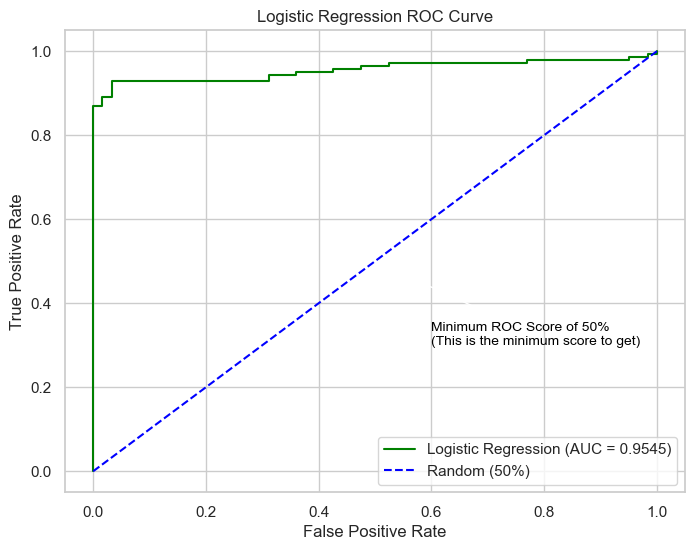

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# Compute ROC curve and AUC score
fpr_lr, tpr_lr, _ = roc_curve(y_test_enc, y_prob_lr)  # False Positive Rate, True Positive Rate
roc_auc = auc(fpr_lr, tpr_lr)  # Compute AUC

#Plot ROC Curve
plt.figure(figsize=(8, 6))
sns.set(style="whitegrid")

# ROCcurve(orange line)
plt.plot(fpr_lr, tpr_lr, color='green', label=f'Logistic Regression (AUC = {roc_auc:.4f})')

# Baseline(Random Model) at 50%
plt.plot([0, 1], [0, 1], color='blue', linestyle='--', label="Random (50%)")  

# Add annotation
plt.annotate("Minimum ROC Score of 50%\n(This is the minimum score to get)",
             xy=(0.5, 0.5), xytext=(0.6, 0.3),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10, color='black')

# Labels & Title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend(loc="lower right")

# Show the plot
plt.show()

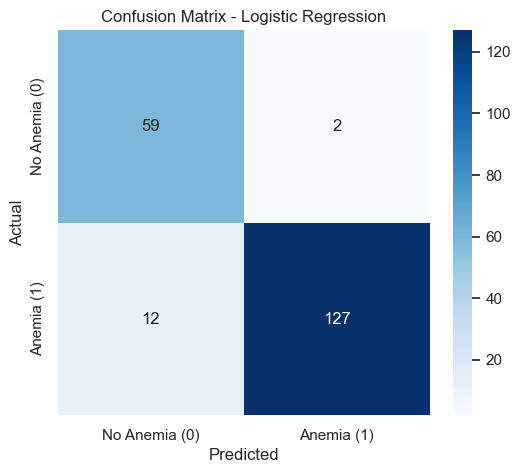


🔹 Final Results for Logistic Regression Model:
🔹 Accuracy: 0.930, AUC: 0.954


In [44]:
#Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score

# Compute confusion matrix
cm_lr = confusion_matrix(y_test_enc, y_pred_lr)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot = True, fmt = 'd', cmap = 'Blues', 
            xticklabels = ['No Anemia (0)', 'Anemia (1)'], 
            yticklabels = ['No Anemia (0)', 'Anemia (1)'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()
# Compute Accuracy & AUC
accuracy_lr = accuracy_score(y_test_enc, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test_enc, y_prob_lr)  # Using probability predictions

# Display Accuracy & AUC
print(f"\n🔹 Final Results for Logistic Regression Model:")
print(f"🔹 Accuracy: {accuracy_lr:.3f}, AUC: {roc_auc_lr:.3f}")


In [46]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import numpy as np

# Define K-Fold Cross Validation
k_folds = 5
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Store scores
accuracy_scores = []
auc_scores = []
classification_reports = []

for fold, (train_index, test_index) in enumerate(kf.split(X_train_fs_new, y_train_resampled), 1):
    # Split data into training and validation for this fold
    X_train_fold, X_test_fold = X_train_fs_new[train_index], X_train_fs_new[test_index]
    y_train_fold, y_test_fold = y_train_resampled[train_index], y_train_resampled[test_index]

    # Train the model
    classifier_lr = LogisticRegression(class_weight='balanced', random_state=0)
    classifier_lr.fit(X_train_fold, y_train_fold)

    # Predict on the validation fold
    y_pred_fold = classifier_lr.predict(X_test_fold)
    y_proba_fold = classifier_lr.predict_proba(X_test_fold)[:, 1]  # probability of class 1

    # Evaluate performance
    acc = accuracy_score(y_test_fold, y_pred_fold)
    auc = roc_auc_score(y_test_fold, y_proba_fold)

    accuracy_scores.append(acc)
    auc_scores.append(auc)
    classification_reports.append(classification_report(y_test_fold, y_pred_fold, output_dict=True))

    print(f"\n📘 Fold {fold} Accuracy: {acc:.4f}")
    print(f"📈 Fold {fold} AUC: {auc:.4f}")
    print(classification_report(y_test_fold, y_pred_fold))

# Average performance across folds
avg_accuracy = np.mean(accuracy_scores)
avg_auc = np.mean(auc_scores)

print(f"\n✅ Average Accuracy across {k_folds} folds: {avg_accuracy:.4f}")
print(f"✅ Average AUC across {k_folds} folds: {avg_auc:.4f}")



📘 Fold 1 Accuracy: 0.9343
📈 Fold 1 AUC: 0.9456
              precision    recall  f1-score   support

           0       0.91      0.96      0.94        99
           1       0.96      0.91      0.93        99

    accuracy                           0.93       198
   macro avg       0.94      0.93      0.93       198
weighted avg       0.94      0.93      0.93       198


📘 Fold 2 Accuracy: 0.8934
📈 Fold 2 AUC: 0.9131
              precision    recall  f1-score   support

           0       0.86      0.94      0.90        98
           1       0.93      0.85      0.89        99

    accuracy                           0.89       197
   macro avg       0.90      0.89      0.89       197
weighted avg       0.90      0.89      0.89       197


📘 Fold 3 Accuracy: 0.9594
📈 Fold 3 AUC: 0.9803
              precision    recall  f1-score   support

           0       0.97      0.95      0.96        98
           1       0.95      0.97      0.96        99

    accuracy                          

In [252]:
pip install optuna

   ---------------------------------------- 0.0/383.6 kB ? eta -:--:--
   - -------------------------------------- 10.2/383.6 kB ? eta -:--:--
   - -------------------------------------- 10.2/383.6 kB ? eta -:--:--
   - -------------------------------------- 10.2/383.6 kB ? eta -:--:--
   ---- ---------------------------------- 41.0/383.6 kB 245.8 kB/s eta 0:00:02
   ------ -------------------------------- 61.4/383.6 kB 272.3 kB/s eta 0:00:02
   ------ -------------------------------- 61.4/383.6 kB 272.3 kB/s eta 0:00:02
   --------- ----------------------------- 92.2/383.6 kB 291.5 kB/s eta 0:00:01
   --------- ----------------------------- 92.2/383.6 kB 291.5 kB/s eta 0:00:01
   ----------- -------------------------- 112.6/383.6 kB 273.1 kB/s eta 0:00:01
   ----------- -------------------------- 112.6/383.6 kB 273.1 kB/s eta 0:00:01
   ----------- -------------------------- 112.6/383.6 kB 273.1 kB/s eta 0:00:01
   ------------ ------------------------- 122.9/383.6 kB 218.3 kB/s eta 0

In [258]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from scipy.stats import loguniform
import optuna

# ---------------- GRID SEARCH ---------------- #
param_grid = [
    {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'penalty': ['l2'], 'solver': ['lbfgs']},  # lbfgs only supports 'l2'
    {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}  # liblinear supports both
]

grid_search = GridSearchCV(LogisticRegression(class_weight='balanced', random_state=0),
                           param_grid,
                           cv=5,
                           scoring='accuracy',
                           verbose=1,
                           n_jobs=-1)

grid_search.fit(X_train_fs_new, y_train_resampled)

best_grid_lr = grid_search.best_estimator_
print("\n🔹 GridSearch Best Hyperparameters:", grid_search.best_params_)
print("🔹 GridSearch Best Accuracy:", grid_search.best_score_)

# ---------------- RANDOM SEARCH ---------------- #
param_dist = {
    'C': loguniform(0.001, 100),  # log scale from 0.001 to 100
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],  # Only liblinear supports both l1 and l2
}

random_search = RandomizedSearchCV(LogisticRegression(class_weight='balanced', random_state=0),
                                   param_distributions=param_dist,
                                   n_iter=30,  # Try 30 random combinations
                                   cv=5,
                                   scoring='accuracy',
                                   random_state=42,
                                   verbose=1,
                                   n_jobs=-1)

random_search.fit(X_train_fs_new, y_train_resampled)

best_random_lr = random_search.best_estimator_
print("\n🔹 RandomSearch Best Hyperparameters:", random_search.best_params_)
print("🔹 RandomSearch Best Accuracy:", random_search.best_score_)

# ---------------- OPTUNA BAYESIAN OPTIMIZATION ---------------- #
def objective(trial):
    C = trial.suggest_float('C', 0.001, 100, log=True) 
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    solver = 'liblinear'  #safe for both l1 and l2

    model = LogisticRegression(C=C, penalty=penalty, solver=solver, class_weight='balanced', random_state=0)
    scores = cross_val_score(model, X_train_fs_new, y_train_resampled, cv=5, scoring='accuracy')
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

best_bayes_lr = LogisticRegression(**study.best_params, solver='liblinear', class_weight='balanced', random_state=0)
best_bayes_lr.fit(X_train_fs_new, y_train_resampled)

print("\n🔹 Bayesian Optimization Best Hyperparameters:", study.best_params)
print("🔹 Bayesian Optimization Best Accuracy:", study.best_value)


Fitting 5 folds for each of 18 candidates, totalling 90 fits

🔹 GridSearch Best Hyperparameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
🔹 GridSearch Best Accuracy: 0.9371173665589909
Fitting 5 folds for each of 30 candidates, totalling 150 fits


[I 2025-03-26 12:57:06,186] A new study created in memory with name: no-name-c09cf8a3-1abe-4ea0-a2e2-5ed1847ab109
[I 2025-03-26 12:57:06,197] Trial 0 finished with value: 0.9056760498384865 and parameters: {'C': 0.0065781571710255, 'penalty': 'l2'}. Best is trial 0 with value: 0.9056760498384865.
[I 2025-03-26 12:57:06,236] Trial 1 finished with value: 0.9320412244270113 and parameters: {'C': 8.769730474582195, 'penalty': 'l1'}. Best is trial 1 with value: 0.9320412244270113.
[I 2025-03-26 12:57:06,266] Trial 2 finished with value: 0.9198738655591449 and parameters: {'C': 0.32963820719662446, 'penalty': 'l2'}. Best is trial 1 with value: 0.9320412244270113.
[I 2025-03-26 12:57:06,281] Trial 3 finished with value: 0.9168333076962518 and parameters: {'C': 0.16698413054918446, 'penalty': 'l2'}. Best is trial 1 with value: 0.9320412244270113.
[I 2025-03-26 12:57:06,304] Trial 4 finished with value: 0.9300158949905143 and parameters: {'C': 1.6004866759821947, 'penalty': 'l1'}. Best is trial


🔹 RandomSearch Best Hyperparameters: {'C': 0.0745934328572655, 'penalty': 'l1', 'solver': 'liblinear'}
🔹 RandomSearch Best Accuracy: 0.9371224939752858


[I 2025-03-26 12:57:06,399] Trial 8 finished with value: 0.9168333076962518 and parameters: {'C': 0.164832170721715, 'penalty': 'l2'}. Best is trial 1 with value: 0.9320412244270113.
[I 2025-03-26 12:57:06,416] Trial 9 finished with value: 0.8722042762651899 and parameters: {'C': 0.015753447131211438, 'penalty': 'l1'}. Best is trial 1 with value: 0.9320412244270113.
[I 2025-03-26 12:57:06,472] Trial 10 finished with value: 0.9310259960006153 and parameters: {'C': 86.19181861372213, 'penalty': 'l1'}. Best is trial 1 with value: 0.9320412244270113.
[I 2025-03-26 12:57:06,564] Trial 11 finished with value: 0.9310259960006153 and parameters: {'C': 36.21403196455483, 'penalty': 'l1'}. Best is trial 1 with value: 0.9320412244270113.
[I 2025-03-26 12:57:06,622] Trial 12 finished with value: 0.9310259960006153 and parameters: {'C': 9.454863465231918, 'penalty': 'l1'}. Best is trial 1 with value: 0.9320412244270113.
[I 2025-03-26 12:57:06,662] Trial 13 finished with value: 0.9310259960006153 an


🔹 Bayesian Optimization Best Hyperparameters: {'C': 0.06606024737844728, 'penalty': 'l1'}
🔹 Bayesian Optimization Best Accuracy: 0.9381377224016818


In [260]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import make_scorer, roc_auc_score
from scipy.stats import loguniform
import optuna

# ---------------- GRID SEARCH ---------------- #
param_grid = [
    {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'penalty': ['l2'], 'solver': ['lbfgs']},
    {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}
]

grid_search = GridSearchCV(LogisticRegression(class_weight='balanced', random_state=0),
                           param_grid,
                           cv=5,
                           scoring='roc_auc',   # ✅ Change here
                           verbose=1,
                           n_jobs=-1)

grid_search.fit(X_train_fs_new, y_train_resampled)

best_grid_lr = grid_search.best_estimator_
print("\n🔹 GridSearch Best Hyperparameters:", grid_search.best_params_)
print("🔹 GridSearch Best AUC:", grid_search.best_score_)

# ---------------- RANDOM SEARCH ---------------- #
param_dist = {
    'C': loguniform(0.001, 100),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
}

random_search = RandomizedSearchCV(LogisticRegression(class_weight='balanced', random_state=0),
                                   param_distributions=param_dist,
                                   n_iter=30,
                                   cv=5,
                                   scoring='roc_auc',   # ✅ AUC here
                                   random_state=42,
                                   verbose=1,
                                   n_jobs=-1)

random_search.fit(X_train_fs_new, y_train_resampled)

best_random_lr = random_search.best_estimator_
print("\n🔹 RandomSearch Best Hyperparameters:", random_search.best_params_)
print("🔹 RandomSearch Best AUC:", random_search.best_score_)

# ---------------- OPTUNA BAYESIAN OPTIMIZATION ---------------- #
def objective(trial):
    C = trial.suggest_float('C', 0.001, 100, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    solver = 'liblinear'

    model = LogisticRegression(C=C, penalty=penalty, solver=solver,
                               class_weight='balanced', random_state=0)
    scores = cross_val_score(model, X_train_fs_new, y_train_resampled, cv=5, scoring='roc_auc')  # ✅ AUC scoring
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

best_bayes_lr = LogisticRegression(**study.best_params, solver='liblinear',
                                   class_weight='balanced', random_state=0)
best_bayes_lr.fit(X_train_fs_new, y_train_resampled)

print("\n🔹 Bayesian Optimization Best Hyperparameters:", study.best_params)
print("🔹 Bayesian Optimization Best AUC:", study.best_value)


Fitting 5 folds for each of 18 candidates, totalling 90 fits

🔹 GridSearch Best Hyperparameters: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
🔹 GridSearch Best AUC: 0.9536232246188956
Fitting 5 folds for each of 30 candidates, totalling 150 fits


[I 2025-03-26 12:57:38,985] A new study created in memory with name: no-name-d7d2a85e-4224-434f-a26a-086ac25c98f3
[I 2025-03-26 12:57:39,006] Trial 0 finished with value: 0.9450056116722785 and parameters: {'C': 0.0014459085021455466, 'penalty': 'l2'}. Best is trial 0 with value: 0.9450056116722785.
[I 2025-03-26 12:57:39,026] Trial 1 finished with value: 0.9511547134923758 and parameters: {'C': 0.14261309618082876, 'penalty': 'l2'}. Best is trial 1 with value: 0.9511547134923758.
[I 2025-03-26 12:57:39,045] Trial 2 finished with value: 0.9530643478695427 and parameters: {'C': 2.2603414269826465, 'penalty': 'l2'}. Best is trial 2 with value: 0.9530643478695427.
[I 2025-03-26 12:57:39,065] Trial 3 finished with value: 0.9534774668973803 and parameters: {'C': 5.765557532561031, 'penalty': 'l2'}. Best is trial 3 with value: 0.9534774668973803.
[I 2025-03-26 12:57:39,076] Trial 4 finished with value: 0.9500656950873403 and parameters: {'C': 0.06820674407436551, 'penalty': 'l2'}. Best is tr


🔹 RandomSearch Best Hyperparameters: {'C': 73.92266140516048, 'penalty': 'l1', 'solver': 'liblinear'}
🔹 RandomSearch Best AUC: 0.953603443213833


[I 2025-03-26 12:57:39,220] Trial 9 finished with value: 0.9535622146011757 and parameters: {'C': 55.162731256097096, 'penalty': 'l1'}. Best is trial 9 with value: 0.9535622146011757.
[I 2025-03-26 12:57:39,279] Trial 10 finished with value: 0.953603443213833 and parameters: {'C': 88.72891848899951, 'penalty': 'l1'}. Best is trial 10 with value: 0.953603443213833.
[I 2025-03-26 12:57:39,339] Trial 11 finished with value: 0.953603443213833 and parameters: {'C': 92.35757516392285, 'penalty': 'l1'}. Best is trial 10 with value: 0.953603443213833.
[I 2025-03-26 12:57:39,398] Trial 12 finished with value: 0.953603443213833 and parameters: {'C': 97.10483015638272, 'penalty': 'l1'}. Best is trial 10 with value: 0.953603443213833.
[I 2025-03-26 12:57:39,489] Trial 13 finished with value: 0.9535622146011757 and parameters: {'C': 20.36366404900358, 'penalty': 'l1'}. Best is trial 10 with value: 0.953603443213833.
[I 2025-03-26 12:57:39,541] Trial 14 finished with value: 0.9536438389252242 and pa


🔹 Bayesian Optimization Best Hyperparameters: {'C': 13.98889623515111, 'penalty': 'l1'}
🔹 Bayesian Optimization Best AUC: 0.9536442553758571


In [48]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from scipy.stats import loguniform
import optuna
import numpy as np

k_folds = 5
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# -------------------- Storage --------------------
results = {
    'grid': {'acc': [], 'auc': []},
    'random': {'acc': [], 'auc': []},
    'optuna': {'acc': [], 'auc': []}
}
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_fs_new, y_train_resampled), 1):
    X_train_fold = X_train_fs_new[train_idx]
    y_train_fold = y_train_resampled[train_idx]
    X_val_fold = X_train_fs_new[val_idx]
    y_val_fold = y_train_resampled[val_idx]
    
    # -------- Grid Search --------
    param_grid = [
        {'C': [0.01, 0.1, 1], 'penalty': ['l2'], 'solver': ['lbfgs']},
        {'C': [0.01, 0.1, 1], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}
    ]
    grid = GridSearchCV(LogisticRegression(class_weight='balanced', random_state=0),
                        param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
    grid.fit(X_train_fold, y_train_fold)
    best_grid = grid.best_estimator_
    y_pred_grid = best_grid.predict(X_val_fold)
    y_prob_grid = best_grid.predict_proba(X_val_fold)[:, 1]
    results['grid']['acc'].append(accuracy_score(y_val_fold, y_pred_grid))
    results['grid']['auc'].append(roc_auc_score(y_val_fold, y_prob_grid))

    # -------- Random Search --------
    param_dist = {
        'C': loguniform(0.01, 100),
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear']
    }
    random = RandomizedSearchCV(LogisticRegression(class_weight='balanced', random_state=0),
                                param_distributions=param_dist, n_iter=10,
                                cv=3, scoring='roc_auc', n_jobs=-1, random_state=42)
    random.fit(X_train_fold, y_train_fold)
    best_random = random.best_estimator_
    y_pred_rand = best_random.predict(X_val_fold)
    y_prob_rand = best_random.predict_proba(X_val_fold)[:, 1]
    results['random']['acc'].append(accuracy_score(y_val_fold, y_pred_rand))
    results['random']['auc'].append(roc_auc_score(y_val_fold, y_prob_rand))

    # -------- Optuna (Bayesian) --------
    def objective(trial):
        C = trial.suggest_float('C', 0.01, 100, log=True)
        penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
        solver = 'liblinear'
        model = LogisticRegression(C=C, penalty=penalty, solver=solver,
                                   class_weight='balanced', random_state=0)
        return cross_val_score(model, X_train_fold, y_train_fold,
                               scoring='roc_auc', cv=3).mean()
    
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20, show_progress_bar=False)
    
    best_bayes = LogisticRegression(**study.best_params, solver='liblinear',
                                    class_weight='balanced', random_state=0)
    best_bayes.fit(X_train_fold, y_train_fold)
    y_pred_bayes = best_bayes.predict(X_val_fold)
    y_prob_bayes = best_bayes.predict_proba(X_val_fold)[:, 1]
    results['optuna']['acc'].append(accuracy_score(y_val_fold, y_pred_bayes))
    results['optuna']['auc'].append(roc_auc_score(y_val_fold, y_prob_bayes))

    print(f"\n✅ Fold {fold} completed.\n")
for method in results:
    avg_acc = np.mean(results[method]['acc'])
    avg_auc = np.mean(results[method]['auc'])
    print(f"📌 {method.upper()} | Avg Accuracy: {avg_acc:.4f} | Avg AUC: {avg_auc:.4f}")


[I 2025-04-18 16:59:02,199] A new study created in memory with name: no-name-7c3ff93f-0f2e-4194-80b9-c982029cce4f
[I 2025-04-18 16:59:02,214] Trial 0 finished with value: 0.9534921501007393 and parameters: {'C': 2.7959484989079617, 'penalty': 'l2'}. Best is trial 0 with value: 0.9534921501007393.
[I 2025-04-18 16:59:02,229] Trial 1 finished with value: 0.9536665236362224 and parameters: {'C': 3.5143186963639548, 'penalty': 'l2'}. Best is trial 1 with value: 0.9536665236362224.
[I 2025-04-18 16:59:02,242] Trial 2 finished with value: 0.9538044038073173 and parameters: {'C': 0.21131360513263864, 'penalty': 'l1'}. Best is trial 2 with value: 0.9538044038073173.
[I 2025-04-18 16:59:02,254] Trial 3 finished with value: 0.9522203269216846 and parameters: {'C': 0.26018758491856986, 'penalty': 'l2'}. Best is trial 2 with value: 0.9538044038073173.
[I 2025-04-18 16:59:02,267] Trial 4 finished with value: 0.9538208846815571 and parameters: {'C': 4.718828186212733, 'penalty': 'l2'}. Best is trial


✅ Fold 1 completed.



[I 2025-04-18 16:59:02,874] Trial 8 finished with value: 0.9606754568586631 and parameters: {'C': 1.584329481005972, 'penalty': 'l2'}. Best is trial 0 with value: 0.9625838538052278.
[I 2025-04-18 16:59:02,886] Trial 9 finished with value: 0.9350084817642069 and parameters: {'C': 0.010314101501566876, 'penalty': 'l1'}. Best is trial 0 with value: 0.9625838538052278.
[I 2025-04-18 16:59:02,910] Trial 10 finished with value: 0.9629115583314056 and parameters: {'C': 0.24670758096185222, 'penalty': 'l1'}. Best is trial 10 with value: 0.9629115583314056.
[I 2025-04-18 16:59:02,926] Trial 11 finished with value: 0.9628730048577377 and parameters: {'C': 0.20925177426738445, 'penalty': 'l1'}. Best is trial 10 with value: 0.9629115583314056.
[I 2025-04-18 16:59:02,948] Trial 12 finished with value: 0.9628151746472358 and parameters: {'C': 0.3989513634852834, 'penalty': 'l1'}. Best is trial 10 with value: 0.9629115583314056.
[I 2025-04-18 16:59:02,972] Trial 13 finished with value: 0.96237180970


✅ Fold 2 completed.



[I 2025-04-18 16:59:03,307] Trial 3 finished with value: 0.9453697278124759 and parameters: {'C': 10.63469980194052, 'penalty': 'l2'}. Best is trial 3 with value: 0.9453697278124759.
[I 2025-04-18 16:59:03,324] Trial 4 finished with value: 0.9449649163389622 and parameters: {'C': 0.552191552621801, 'penalty': 'l1'}. Best is trial 3 with value: 0.9453697278124759.
[I 2025-04-18 16:59:03,337] Trial 5 finished with value: 0.9415336571825121 and parameters: {'C': 0.03676981306885271, 'penalty': 'l2'}. Best is trial 3 with value: 0.9453697278124759.
[I 2025-04-18 16:59:03,368] Trial 6 finished with value: 0.9457167090754877 and parameters: {'C': 13.76030333524445, 'penalty': 'l1'}. Best is trial 6 with value: 0.9457167090754877.
[I 2025-04-18 16:59:03,380] Trial 7 finished with value: 0.9417649780245201 and parameters: {'C': 0.03458324696529281, 'penalty': 'l1'}. Best is trial 6 with value: 0.9457167090754877.
[I 2025-04-18 16:59:03,393] Trial 8 finished with value: 0.9413601665510063 and p


✅ Fold 3 completed.



[I 2025-04-18 16:59:03,935] Trial 8 finished with value: 0.9544683475981186 and parameters: {'C': 0.2062571503316588, 'penalty': 'l1'}. Best is trial 2 with value: 0.9545261778086204.
[I 2025-04-18 16:59:03,948] Trial 9 finished with value: 0.953639447914257 and parameters: {'C': 11.190235819924588, 'penalty': 'l2'}. Best is trial 2 with value: 0.9545261778086204.
[I 2025-04-18 16:59:03,984] Trial 10 finished with value: 0.9549117125453003 and parameters: {'C': 13.924160664333492, 'penalty': 'l1'}. Best is trial 10 with value: 0.9549117125453003.
[I 2025-04-18 16:59:04,015] Trial 11 finished with value: 0.9548924358084663 and parameters: {'C': 13.46029898110966, 'penalty': 'l1'}. Best is trial 10 with value: 0.9549117125453003.
[I 2025-04-18 16:59:04,056] Trial 12 finished with value: 0.9550080962294701 and parameters: {'C': 20.14537065374719, 'penalty': 'l1'}. Best is trial 12 with value: 0.9550080962294701.
[I 2025-04-18 16:59:04,096] Trial 13 finished with value: 0.9550466497031382 


✅ Fold 4 completed.



[I 2025-04-18 16:59:04,514] Trial 7 finished with value: 0.9464299483383454 and parameters: {'C': 0.8465876361805207, 'penalty': 'l1'}. Best is trial 3 with value: 0.9472588480222068.
[I 2025-04-18 16:59:04,528] Trial 8 finished with value: 0.9456974323386538 and parameters: {'C': 0.2642365530931723, 'penalty': 'l1'}. Best is trial 3 with value: 0.9472588480222068.
[I 2025-04-18 16:59:04,540] Trial 9 finished with value: 0.9472781247590408 and parameters: {'C': 60.404734593529426, 'penalty': 'l2'}. Best is trial 9 with value: 0.9472781247590408.
[I 2025-04-18 16:59:04,559] Trial 10 finished with value: 0.9463142879173413 and parameters: {'C': 4.6925301191201285, 'penalty': 'l2'}. Best is trial 9 with value: 0.9472781247590408.
[I 2025-04-18 16:59:04,575] Trial 11 finished with value: 0.9472588480222068 and parameters: {'C': 56.44865497621978, 'penalty': 'l2'}. Best is trial 9 with value: 0.9472781247590408.
[I 2025-04-18 16:59:04,596] Trial 12 finished with value: 0.947220294548539 and


✅ Fold 5 completed.

📌 GRID | Avg Accuracy: 0.9371 | Avg AUC: 0.9517
📌 RANDOM | Avg Accuracy: 0.9331 | Avg AUC: 0.9519
📌 OPTUNA | Avg Accuracy: 0.9351 | Avg AUC: 0.9520


## Gaussian Naive Bayes (GNB)

In [64]:
# Given probabilities
p_spam = 0.3  # P(Spam): The probability that an email is spam.
p_word_given_spam = 0.8  # P(Word|Spam): Probability that a spam email contains the word.
p_word = 0.4  # P(Word): Probability that any email (spam or not) contains the word.

# Applying Bayes' Theorem
p_spam_given_word = (p_word_given_spam * p_spam) / p_word

# Print result
print(f"P(Spam | Word) = {p_spam_given_word:.2f}")

P(Spam | Word) = 0.60


In [50]:
# Import Gaussian Naïve Bayes
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score

classifier_gnb = GaussianNB()
classifier_gnb.fit(X_train_fs_new, y_train_resampled)

# Predict on the test set
y_pred_gnb = classifier_gnb.predict(X_test_fs_new)

In [52]:
# Compute Accuracy
accuracy_gnb = accuracy_score(y_test_enc, y_pred_gnb)

# Print classification report
print("\n🔹 Classification Report for GNB:")
print(classification_report(y_test_enc, y_pred_gnb))

# Print Accuracy
print(f"\n🔹 GNB Accuracy: {accuracy_gnb:.3f}")



🔹 Classification Report for GNB:
              precision    recall  f1-score   support

           0       0.75      0.97      0.84        61
           1       0.98      0.86      0.92       139

    accuracy                           0.89       200
   macro avg       0.87      0.91      0.88       200
weighted avg       0.91      0.89      0.89       200


🔹 GNB Accuracy: 0.890


In [54]:
#Predict
y_pred_gnb = classifier_gnb.predict(X_test_fs_new)
results_df = pd.DataFrame({
    'Predicted': y_pred_gnb,
    'Actual': y_test_enc
})
#Print
y_prob_gnb = classifier_gnb.predict_proba(X_test_fs_new)[:, 1] # Probability of class 1
results_df['Probability'] = y_prob_gnb
results_df['Probability'] = results_df['Probability'].round(4)
print(results_df.head(20))

    Predicted  Actual  Probability
0           1       1       0.9669
1           1       1       0.5703
2           1       1       0.7334
3           1       1       0.9947
4           0       0       0.0005
5           0       0       0.2263
6           0       0       0.0963
7           0       0       0.0011
8           0       1       0.2569
9           1       1       0.9761
10          1       1       0.9780
11          0       0       0.0010
12          1       1       0.9702
13          1       1       1.0000
14          0       0       0.0004
15          0       0       0.0004
16          1       1       0.7014
17          1       1       1.0000
18          1       1       0.9990
19          1       1       0.9993


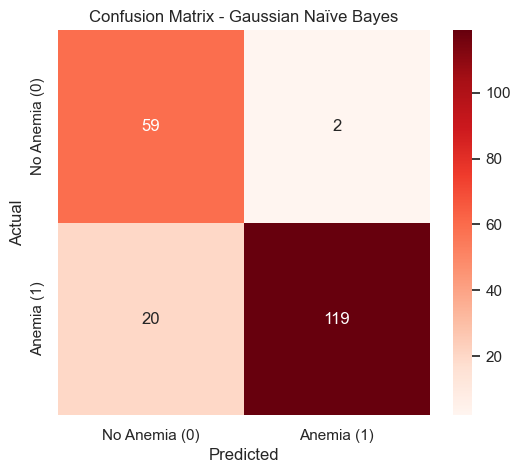


🔹 Final Results for GNB Model:
🔹 Accuracy: 0.890, AUC: 0.935


In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm_gnb = confusion_matrix(y_test_enc, y_pred_gnb)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Reds',
            xticklabels=['No Anemia (0)', 'Anemia (1)'],
            yticklabels=['No Anemia (0)', 'Anemia (1)'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Gaussian Naïve Bayes")
plt.show()

# Compute Accuracy & AUC
accuracy_gnb = accuracy_score(y_test_enc, y_pred_gnb)
roc_auc_gnb = roc_auc_score(y_test_enc, y_prob_gnb)  # Using probability predictions

# Display Accuracy & AUC
print(f"\n🔹 Final Results for GNB Model:")
print(f"🔹 Accuracy: {accuracy_gnb:.3f}, AUC: {roc_auc_gnb:.3f}")


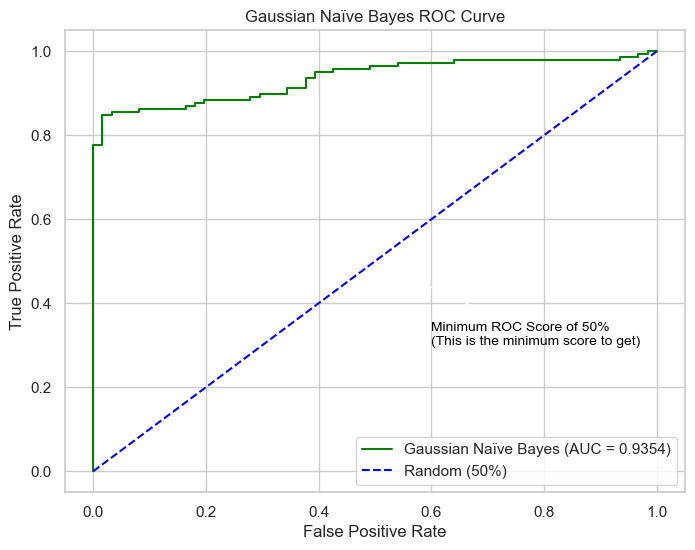

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# Compute ROC curve and AUC score for GNB
fpr_gnb, tpr_gnb, _ = roc_curve(y_test_enc, y_prob_gnb)  # False Positive Rate, True Positive Rate
roc_auc_gnb = auc(fpr_gnb, tpr_gnb)  # Compute AUC

# Plot ROC Curve
plt.figure(figsize=(8, 6))
sns.set(style="whitegrid")

# ROC curve (green line for GNB)
plt.plot(fpr_gnb, tpr_gnb, color='green', label=f'Gaussian Naïve Bayes (AUC = {roc_auc_gnb:.4f})')

# Baseline (Random Model) at 50%
plt.plot([0, 1], [0, 1], color='blue', linestyle='--', label="Random (50%)")  

# Add annotation
plt.annotate("Minimum ROC Score of 50%\n(This is the minimum score to get)",
             xy=(0.5, 0.5), xytext=(0.6, 0.3),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10, color='black')

# Labels & Title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Gaussian Naïve Bayes ROC Curve")
plt.legend(loc="lower right")

# Show the plot
plt.show()


In [60]:
from sklearn.model_selection import StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import numpy as np

# Define K-Fold Cross Validation
k_folds = 5
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Store scores
accuracy_scores = []
auc_scores = []
classification_reports = []

for fold, (train_index, test_index) in enumerate(kf.split(X_train_fs_new, y_train_resampled), 1):
    # Split data into training and validation for this fold
    X_train_fold, X_test_fold = X_train_fs_new[train_index], X_train_fs_new[test_index]
    y_train_fold, y_test_fold = y_train_resampled[train_index], y_train_resampled[test_index]

    # Train the model
    classifier_gnb = GaussianNB()
    classifier_gnb.fit(X_train_fold, y_train_fold)

    # Predict on the validation fold
    y_pred_fold = classifier_gnb.predict(X_test_fold)
    y_proba_fold = classifier_gnb.predict_proba(X_test_fold)[:, 1]  # probability of class 1

    # Evaluate performance
    acc = accuracy_score(y_test_fold, y_pred_fold)
    auc = roc_auc_score(y_test_fold, y_proba_fold)

    accuracy_scores.append(acc)
    auc_scores.append(auc)
    classification_reports.append(classification_report(y_test_fold, y_pred_fold, output_dict=True))

    print(f"\n📘 Fold {fold} Accuracy: {acc:.4f}")
    print(f"📈 Fold {fold} AUC: {auc:.4f}")
    print(classification_report(y_test_fold, y_pred_fold))

# Average performance across folds
avg_accuracy = np.mean(accuracy_scores)
avg_auc = np.mean(auc_scores)

print(f"\n✅ Average Accuracy across {k_folds} folds: {avg_accuracy:.4f}")
print(f"✅ Average AUC across {k_folds} folds: {avg_auc:.4f}")



📘 Fold 1 Accuracy: 0.8434
📈 Fold 1 AUC: 0.9361
              precision    recall  f1-score   support

           0       0.84      0.85      0.84        99
           1       0.85      0.84      0.84        99

    accuracy                           0.84       198
   macro avg       0.84      0.84      0.84       198
weighted avg       0.84      0.84      0.84       198


📘 Fold 2 Accuracy: 0.8426
📈 Fold 2 AUC: 0.8972
              precision    recall  f1-score   support

           0       0.82      0.88      0.85        98
           1       0.87      0.81      0.84        99

    accuracy                           0.84       197
   macro avg       0.84      0.84      0.84       197
weighted avg       0.84      0.84      0.84       197


📘 Fold 3 Accuracy: 0.8629
📈 Fold 3 AUC: 0.9396
              precision    recall  f1-score   support

           0       0.86      0.87      0.86        98
           1       0.87      0.86      0.86        99

    accuracy                          

In [64]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score
from scipy.stats import loguniform
import optuna
import numpy as np

k_folds = 5
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

results = {
    'grid': {'acc': [], 'auc': []},
    'random': {'acc': [], 'auc': []},
    'optuna': {'acc': [], 'auc': []}
}

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_fs_new, y_train_resampled), 1):
    X_train_fold = X_train_fs_new[train_idx]
    y_train_fold = y_train_resampled[train_idx]
    X_val_fold = X_train_fs_new[val_idx]
    y_val_fold = y_train_resampled[val_idx]

    # -------- Grid Search --------
    param_grid = {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]}
    grid = GridSearchCV(GaussianNB(), param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
    grid.fit(X_train_fold, y_train_fold)
    best_grid = grid.best_estimator_
    y_pred_grid = best_grid.predict(X_val_fold)
    y_prob_grid = best_grid.predict_proba(X_val_fold)[:, 1]
    results['grid']['acc'].append(accuracy_score(y_val_fold, y_pred_grid))
    results['grid']['auc'].append(roc_auc_score(y_val_fold, y_prob_grid))

    # -------- Random Search --------
    param_dist = {'var_smoothing': loguniform(1e-10, 1e-6)}
    random = RandomizedSearchCV(GaussianNB(), param_distributions=param_dist,
                                n_iter=10, cv=3, scoring='roc_auc', n_jobs=-1, random_state=42)
    random.fit(X_train_fold, y_train_fold)
    best_random = random.best_estimator_
    y_pred_rand = best_random.predict(X_val_fold)
    y_prob_rand = best_random.predict_proba(X_val_fold)[:, 1]
    results['random']['acc'].append(accuracy_score(y_val_fold, y_pred_rand))
    results['random']['auc'].append(roc_auc_score(y_val_fold, y_prob_rand))

    # -------- Optuna (Bayesian) --------
    def objective(trial):
        var_smoothing = trial.suggest_float('var_smoothing', 1e-10, 1e-6, log=True)
        model = GaussianNB(var_smoothing=var_smoothing)
        return cross_val_score(model, X_train_fold, y_train_fold, scoring='roc_auc', cv=3).mean()

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20, show_progress_bar=False)

    best_bayes = GaussianNB(**study.best_params)
    best_bayes.fit(X_train_fold, y_train_fold)
    y_pred_bayes = best_bayes.predict(X_val_fold)
    y_prob_bayes = best_bayes.predict_proba(X_val_fold)[:, 1]
    results['optuna']['acc'].append(accuracy_score(y_val_fold, y_pred_bayes))
    results['optuna']['auc'].append(roc_auc_score(y_val_fold, y_prob_bayes))

    print(f"\n✅ Fold {fold} completed.\n")
for method in results:
    avg_acc = np.mean(results[method]['acc'])
    avg_auc = np.mean(results[method]['auc'])
    print(f"📌 {method.upper()} | Avg Accuracy: {avg_acc:.4f} | Avg AUC: {avg_auc:.4f}")


[I 2025-04-18 17:01:11,084] A new study created in memory with name: no-name-a888d637-8141-4b2c-9cd4-e347a36ed064
[I 2025-04-18 17:01:11,094] Trial 0 finished with value: 0.922558432056713 and parameters: {'var_smoothing': 7.166662552604042e-08}. Best is trial 0 with value: 0.922558432056713.
[I 2025-04-18 17:01:11,104] Trial 1 finished with value: 0.922558432056713 and parameters: {'var_smoothing': 1.6916725702831785e-09}. Best is trial 0 with value: 0.922558432056713.
[I 2025-04-18 17:01:11,116] Trial 2 finished with value: 0.922558432056713 and parameters: {'var_smoothing': 3.485585814294055e-10}. Best is trial 0 with value: 0.922558432056713.
[I 2025-04-18 17:01:11,126] Trial 3 finished with value: 0.922558432056713 and parameters: {'var_smoothing': 2.7700154366326605e-09}. Best is trial 0 with value: 0.922558432056713.
[I 2025-04-18 17:01:11,138] Trial 4 finished with value: 0.922558432056713 and parameters: {'var_smoothing': 1.000785958003928e-10}. Best is trial 0 with value: 0.9


✅ Fold 1 completed.



[I 2025-04-18 17:01:11,534] Trial 12 finished with value: 0.926305035083661 and parameters: {'var_smoothing': 8.250206045521201e-08}. Best is trial 0 with value: 0.926305035083661.
[I 2025-04-18 17:01:11,553] Trial 13 finished with value: 0.926305035083661 and parameters: {'var_smoothing': 4.6759885167199966e-09}. Best is trial 0 with value: 0.926305035083661.
[I 2025-04-18 17:01:11,568] Trial 14 finished with value: 0.926305035083661 and parameters: {'var_smoothing': 1.428126479626112e-08}. Best is trial 0 with value: 0.926305035083661.
[I 2025-04-18 17:01:11,586] Trial 15 finished with value: 0.926305035083661 and parameters: {'var_smoothing': 1.9040579609077217e-07}. Best is trial 0 with value: 0.926305035083661.
[I 2025-04-18 17:01:11,599] Trial 16 finished with value: 0.926305035083661 and parameters: {'var_smoothing': 2.805627172716062e-09}. Best is trial 0 with value: 0.926305035083661.
[I 2025-04-18 17:01:11,622] Trial 17 finished with value: 0.926305035083661 and parameters: {


✅ Fold 2 completed.



[I 2025-04-18 17:01:11,859] Trial 10 finished with value: 0.919076258770915 and parameters: {'var_smoothing': 4.317060684781758e-10}. Best is trial 0 with value: 0.919076258770915.
[I 2025-04-18 17:01:11,874] Trial 11 finished with value: 0.919076258770915 and parameters: {'var_smoothing': 2.696571933211787e-10}. Best is trial 0 with value: 0.919076258770915.
[I 2025-04-18 17:01:11,888] Trial 12 finished with value: 0.919076258770915 and parameters: {'var_smoothing': 7.00016474317188e-07}. Best is trial 0 with value: 0.919076258770915.
[I 2025-04-18 17:01:11,902] Trial 13 finished with value: 0.919076258770915 and parameters: {'var_smoothing': 1.104644730133188e-08}. Best is trial 0 with value: 0.919076258770915.
[I 2025-04-18 17:01:11,916] Trial 14 finished with value: 0.919076258770915 and parameters: {'var_smoothing': 1.5640108608305915e-09}. Best is trial 0 with value: 0.919076258770915.
[I 2025-04-18 17:01:11,926] Trial 15 finished with value: 0.919076258770915 and parameters: {'v


✅ Fold 3 completed.



[I 2025-04-18 17:01:12,178] Trial 11 finished with value: 0.9251484308736218 and parameters: {'var_smoothing': 1.578480166479703e-08}. Best is trial 0 with value: 0.9251484308736218.
[I 2025-04-18 17:01:12,186] Trial 12 finished with value: 0.9251484308736218 and parameters: {'var_smoothing': 1.598712514854737e-08}. Best is trial 0 with value: 0.9251484308736218.
[I 2025-04-18 17:01:12,203] Trial 13 finished with value: 0.9251484308736218 and parameters: {'var_smoothing': 6.039740386842823e-08}. Best is trial 0 with value: 0.9251484308736218.
[I 2025-04-18 17:01:12,215] Trial 14 finished with value: 0.9251484308736218 and parameters: {'var_smoothing': 8.559209651077465e-09}. Best is trial 0 with value: 0.9251484308736218.
[I 2025-04-18 17:01:12,226] Trial 15 finished with value: 0.9251484308736218 and parameters: {'var_smoothing': 2.8092437696595753e-07}. Best is trial 0 with value: 0.9251484308736218.
[I 2025-04-18 17:01:12,240] Trial 16 finished with value: 0.9251484308736218 and par


✅ Fold 4 completed.



[I 2025-04-18 17:01:12,476] Trial 12 finished with value: 0.9185172334027296 and parameters: {'var_smoothing': 7.492414781222192e-10}. Best is trial 0 with value: 0.9185172334027296.
[I 2025-04-18 17:01:12,486] Trial 13 finished with value: 0.9185172334027296 and parameters: {'var_smoothing': 6.815840264911937e-10}. Best is trial 0 with value: 0.9185172334027296.
[I 2025-04-18 17:01:12,500] Trial 14 finished with value: 0.9185172334027296 and parameters: {'var_smoothing': 6.313011597234656e-10}. Best is trial 0 with value: 0.9185172334027296.
[I 2025-04-18 17:01:12,514] Trial 15 finished with value: 0.9185172334027296 and parameters: {'var_smoothing': 1.0588652699593543e-10}. Best is trial 0 with value: 0.9185172334027296.
[I 2025-04-18 17:01:12,526] Trial 16 finished with value: 0.9185172334027296 and parameters: {'var_smoothing': 1.6825751320256264e-09}. Best is trial 0 with value: 0.9185172334027296.
[I 2025-04-18 17:01:12,540] Trial 17 finished with value: 0.9185172334027296 and pa


✅ Fold 5 completed.

📌 GRID | Avg Accuracy: 0.8601 | Avg AUC: 0.9249
📌 RANDOM | Avg Accuracy: 0.8601 | Avg AUC: 0.9249
📌 OPTUNA | Avg Accuracy: 0.8601 | Avg AUC: 0.9249


## Decision Tree (DT)

In [166]:
# Import Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize Decision Tree model
classifier_dt = DecisionTreeClassifier(
    max_depth=5,          # Set maximum depth of the tree
    min_samples_split=10, # Minimum samples needed to split a node
    random_state=0        # Ensures reproducibility
)

# Train the model on training data
classifier_dt.fit(X_train_fs_new, y_train_resampled)

# Predict on the test set
y_pred_dt = classifier_dt.predict(X_test_fs_new)

# Print Accuracy & Classification Report
print(f"DT Accuracy: {accuracy_score(y_test_enc, y_pred_dt):.4f}")
print(classification_report(y_test_enc, y_pred_dt))


DT Accuracy: 0.9100
              precision    recall  f1-score   support

           0       0.78      0.98      0.87        61
           1       0.99      0.88      0.93       139

    accuracy                           0.91       200
   macro avg       0.89      0.93      0.90       200
weighted avg       0.93      0.91      0.91       200



In [168]:
# Predict labels
y_pred_dt = classifier_dt.predict(X_test_fs_new)

# Create DataFrame to store predictions
results_dt = pd.DataFrame({
    'Predicted': y_pred_dt,
    'Actual': y_test_enc
})

# Get probability predictions for Class 1
y_prob_dt = classifier_dt.predict_proba(X_test_fs_new)[:, 1]
results_dt['Probability'] = y_prob_dt

print(results_dt.head(20))  

    Predicted  Actual  Probability
0           1       1     1.000000
1           1       1     1.000000
2           1       1     1.000000
3           1       1     1.000000
4           0       0     0.040441
5           0       0     0.040441
6           0       0     0.040441
7           0       0     0.040441
8           0       1     0.096154
9           1       1     1.000000
10          1       1     1.000000
11          0       0     0.040441
12          1       1     1.000000
13          1       1     1.000000
14          0       0     0.040441
15          0       0     0.040441
16          1       1     1.000000
17          1       1     1.000000
18          1       1     1.000000
19          1       1     1.000000


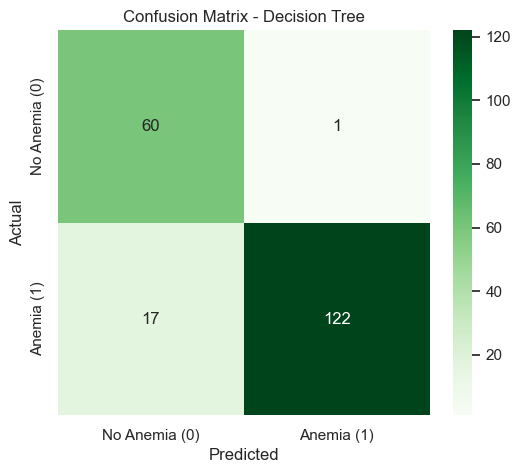


🔹 Final Results for Decision Tree Model:
🔹 Accuracy: 0.910, AUC: 0.950


In [170]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

# Compute confusion matrix for Decision Tree
cm_dt = confusion_matrix(y_test_enc, y_pred_dt)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['No Anemia (0)', 'Anemia (1)'], 
            yticklabels=['No Anemia (0)', 'Anemia (1)'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")

# Show the plot
plt.show()

# Compute Accuracy & AUC
accuracy_dt = accuracy_score(y_test_enc, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test_enc, y_prob_dt)  # Using probability predictions

# Display Accuracy & AUC
print(f"\n🔹 Final Results for Decision Tree Model:")
print(f"🔹 Accuracy: {accuracy_dt:.3f}, AUC: {roc_auc_dt:.3f}")


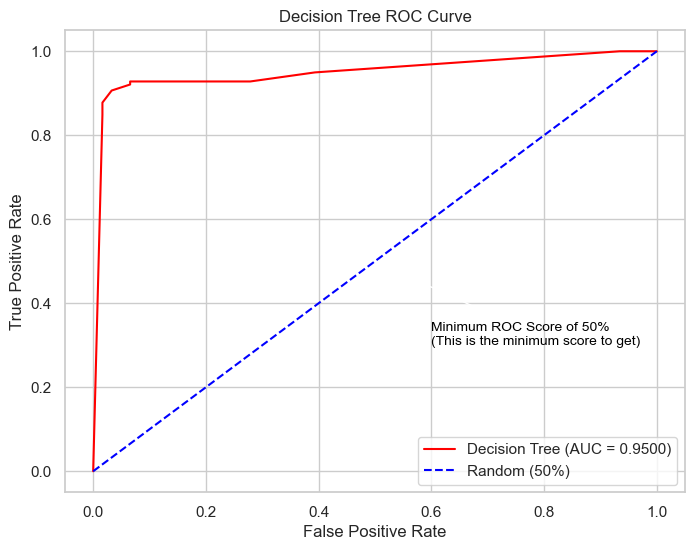

In [172]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# Compute ROC curve and AUC score for Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test_enc, y_prob_dt)  # False Positive Rate, True Positive Rate
roc_auc_dt = auc(fpr_dt, tpr_dt)  # Compute AUC

# Plot ROC Curve
plt.figure(figsize=(8, 6))
sns.set(style="whitegrid")

# ROC curve (green line for DT)
plt.plot(fpr_dt, tpr_dt, color='red', label=f'Decision Tree (AUC = {roc_auc_dt:.4f})')

# Baseline (Random Model) at 50%
plt.plot([0, 1], [0, 1], color='blue', linestyle='--', label="Random (50%)")

# Add annotation
plt.annotate("Minimum ROC Score of 50%\n(This is the minimum score to get)",
             xy=(0.5, 0.5), xytext=(0.6, 0.3),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10, color='black')

# Labels & Title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve")
plt.legend(loc="lower right")

# Show the plot
plt.show()


In [46]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import numpy as np

# Define Stratified K-Fold
k_folds = 5
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Storage
accuracy_scores = []
auc_scores = []
classification_reports = []

for fold, (train_index, test_index) in enumerate(kf.split(X_train_fs_new, y_train_resampled), 1):
    # Split for this fold
    X_train_fold, X_test_fold = X_train_fs_new[train_index], X_train_fs_new[test_index]
    y_train_fold, y_test_fold = y_train_resampled[train_index], y_train_resampled[test_index]

    # Initialize and train model
    classifier_dt = DecisionTreeClassifier(class_weight='balanced', random_state=0)
    classifier_dt.fit(X_train_fold, y_train_fold)

    # Predict
    y_pred_fold = classifier_dt.predict(X_test_fold)
    y_proba_fold = classifier_dt.predict_proba(X_test_fold)[:, 1]  # Probability for class 1

    # Evaluate
    acc = accuracy_score(y_test_fold, y_pred_fold)
    auc = roc_auc_score(y_test_fold, y_proba_fold)

    accuracy_scores.append(acc)
    auc_scores.append(auc)
    classification_reports.append(classification_report(y_test_fold, y_pred_fold, output_dict=True))

    print(f"\n🌿 Fold {fold} Accuracy: {acc:.4f}")
    print(f"📈 Fold {fold} AUC: {auc:.4f}")
    print(classification_report(y_test_fold, y_pred_fold))

# Final average scores
avg_accuracy = np.mean(accuracy_scores)
avg_auc = np.mean(auc_scores)

print(f"\n✅ Average Accuracy (DT) across {k_folds} folds: {avg_accuracy:.4f}")
print(f"✅ Average AUC (DT) across {k_folds} folds: {avg_auc:.4f}")



🌿 Fold 1 Accuracy: 0.9091
📈 Fold 1 AUC: 0.9091
              precision    recall  f1-score   support

           0       0.86      0.97      0.91        99
           1       0.97      0.85      0.90        99

    accuracy                           0.91       198
   macro avg       0.92      0.91      0.91       198
weighted avg       0.92      0.91      0.91       198


🌿 Fold 2 Accuracy: 0.9086
📈 Fold 2 AUC: 0.9089
              precision    recall  f1-score   support

           0       0.86      0.97      0.91        98
           1       0.97      0.85      0.90        99

    accuracy                           0.91       197
   macro avg       0.91      0.91      0.91       197
weighted avg       0.91      0.91      0.91       197


🌿 Fold 3 Accuracy: 0.9036
📈 Fold 3 AUC: 0.9034
              precision    recall  f1-score   support

           0       0.92      0.88      0.90        98
           1       0.88      0.93      0.91        99

    accuracy                          

In [262]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from scipy.stats import randint
import optuna

# ---------------- GRID SEARCH ---------------- #
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_dt = GridSearchCV(DecisionTreeClassifier(random_state=0),
                              param_grid_dt,
                              cv=5,
                              scoring='accuracy',
                              verbose=1,
                              n_jobs=-1)

grid_search_dt.fit(X_train_fs_new, y_train_resampled)

best_grid_dt = grid_search_dt.best_estimator_
print("\n🔹 GridSearch Best Hyperparameters (DT):", grid_search_dt.best_params_)
print("🔹 GridSearch Best Accuracy:", grid_search_dt.best_score_)

# ---------------- RANDOM SEARCH ---------------- #
param_dist_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': randint(5, 50),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10)
}

random_search_dt = RandomizedSearchCV(DecisionTreeClassifier(random_state=0),
                                      param_distributions=param_dist_dt,
                                      n_iter=30,  # Try 30 random combinations
                                      cv=5,
                                      scoring='accuracy',
                                      random_state=42,
                                      verbose=1,
                                      n_jobs=-1)

random_search_dt.fit(X_train_fs_new, y_train_resampled)

best_random_dt = random_search_dt.best_estimator_
print("\n🔹 RandomSearch Best Hyperparameters (DT):", random_search_dt.best_params_)
print("🔹 RandomSearch Best Accuracy:", random_search_dt.best_score_)

# ---------------- OPTUNA BAYESIAN OPTIMIZATION ---------------- #
def objective_dt(trial):
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])
    max_depth = trial.suggest_int('max_depth', 5, 50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

    model = DecisionTreeClassifier(criterion=criterion, max_depth=max_depth, 
                                   min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf, 
                                   random_state=0)

    scores = cross_val_score(model, X_train_fs_new, y_train_resampled, cv=5, scoring='accuracy')
    return scores.mean()

study_dt = optuna.create_study(direction='maximize')
study_dt.optimize(objective_dt, n_trials=50)

best_bayes_dt = DecisionTreeClassifier(**study_dt.best_params, random_state=0)
best_bayes_dt.fit(X_train_fs_new, y_train_resampled)

print("\n🔹 Bayesian Optimization Best Hyperparameters (DT):", study_dt.best_params)
print("🔹 Bayesian Optimization Best Accuracy:", study_dt.best_value)


Fitting 5 folds for each of 90 candidates, totalling 450 fits


[I 2025-03-26 13:01:10,484] A new study created in memory with name: no-name-0a0f0c77-ce44-44c1-a78b-fcccaba70d17
[I 2025-03-26 13:01:10,510] Trial 0 finished with value: 0.9077526534379328 and parameters: {'criterion': 'gini', 'max_depth': 23, 'min_samples_split': 7, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.9077526534379328.
[I 2025-03-26 13:01:10,536] Trial 1 finished with value: 0.9047223504076296 and parameters: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_split': 4, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.9077526534379328.



🔹 GridSearch Best Hyperparameters (DT): {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
🔹 GridSearch Best Accuracy: 0.9259960006152899
Fitting 5 folds for each of 30 candidates, totalling 150 fits

🔹 RandomSearch Best Hyperparameters (DT): {'criterion': 'gini', 'max_depth': 44, 'min_samples_leaf': 5, 'min_samples_split': 17}
🔹 RandomSearch Best Accuracy: 0.9198943752243245


[I 2025-03-26 13:01:10,562] Trial 2 finished with value: 0.9026816387222478 and parameters: {'criterion': 'entropy', 'max_depth': 35, 'min_samples_split': 4, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.9077526534379328.
[I 2025-03-26 13:01:10,586] Trial 3 finished with value: 0.9036661026508742 and parameters: {'criterion': 'gini', 'max_depth': 35, 'min_samples_split': 2, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.9077526534379328.
[I 2025-03-26 13:01:10,609] Trial 4 finished with value: 0.9127980310721429 and parameters: {'criterion': 'gini', 'max_depth': 47, 'min_samples_split': 3, 'min_samples_leaf': 2}. Best is trial 4 with value: 0.9127980310721429.
[I 2025-03-26 13:01:10,629] Trial 5 finished with value: 0.9148131056760498 and parameters: {'criterion': 'gini', 'max_depth': 43, 'min_samples_split': 2, 'min_samples_leaf': 9}. Best is trial 5 with value: 0.9148131056760498.
[I 2025-03-26 13:01:10,654] Trial 6 finished with value: 0.9057016869199609 and parameter


🔹 Bayesian Optimization Best Hyperparameters (DT): {'criterion': 'entropy', 'max_depth': 25, 'min_samples_split': 17, 'min_samples_leaf': 10}
🔹 Bayesian Optimization Best Accuracy: 0.9209096036507203


In [266]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import make_scorer, roc_auc_score
from scipy.stats import randint
import optuna

# ---------------- GRID SEARCH ---------------- #
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=0),
    param_grid=param_grid_dt,
    cv=5,
    scoring={'accuracy': 'accuracy', 'roc_auc': 'roc_auc'},  # 💡 Multiple scoring
    refit='roc_auc',   # 💡 Refit using best AUC model
    verbose=1,
    n_jobs=-1
)

grid_search_dt.fit(X_train_fs_new, y_train_resampled)

best_grid_dt = grid_search_dt.best_estimator_
print("\n🔹 GridSearch Best Hyperparameters (DT):", grid_search_dt.best_params_)
print("🔹 GridSearch Best AUC:", grid_search_dt.best_score_)  # Because refit='roc_auc'

# ---------------- RANDOM SEARCH ---------------- #
param_dist_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': randint(5, 50),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10)
}

random_search_dt = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=0),
    param_distributions=param_dist_dt,
    n_iter=30,
    cv=5,
    scoring={'accuracy': 'accuracy', 'roc_auc': 'roc_auc'},  # 💡 Add AUC scoring
    refit='roc_auc',
    random_state=42,
    verbose=1,
    n_jobs=-1
)

random_search_dt.fit(X_train_fs_new, y_train_resampled)

best_random_dt = random_search_dt.best_estimator_
print("\n🔹 RandomSearch Best Hyperparameters (DT):", random_search_dt.best_params_)
print("🔹 RandomSearch Best AUC:", random_search_dt.best_score_)

# ---------------- OPTUNA BAYESIAN OPTIMIZATION ---------------- #
def objective_dt(trial):
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])
    max_depth = trial.suggest_int('max_depth', 5, 50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

    model = DecisionTreeClassifier(
        criterion=criterion,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=0
    )

    # 💡 Use roc_auc scoring
    scores = cross_val_score(model, X_train_fs_new, y_train_resampled, cv=5, scoring='roc_auc')
    return scores.mean()

study_dt = optuna.create_study(direction='maximize')
study_dt.optimize(objective_dt, n_trials=50)

best_bayes_dt = DecisionTreeClassifier(**study_dt.best_params, random_state=0)
best_bayes_dt.fit(X_train_fs_new, y_train_resampled)

print("\n🔹 Bayesian Optimization Best Hyperparameters (DT):", study_dt.best_params)
print("🔹 Bayesian Optimization Best AUC:", study_dt.best_value)


Fitting 5 folds for each of 90 candidates, totalling 450 fits


[I 2025-03-26 13:08:11,712] A new study created in memory with name: no-name-d10931ce-19a4-4823-b484-bf5f47b7a560
[I 2025-03-26 13:08:11,739] Trial 0 finished with value: 0.9135364154844673 and parameters: {'criterion': 'entropy', 'max_depth': 34, 'min_samples_split': 7, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.9135364154844673.



🔹 GridSearch Best Hyperparameters (DT): {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}
🔹 GridSearch Best AUC: 0.9457487678266899
Fitting 5 folds for each of 30 candidates, totalling 150 fits

🔹 RandomSearch Best Hyperparameters (DT): {'criterion': 'gini', 'max_depth': 46, 'min_samples_leaf': 3, 'min_samples_split': 13}
🔹 RandomSearch Best AUC: 0.944338874209004


[I 2025-03-26 13:08:11,772] Trial 1 finished with value: 0.9344604569712794 and parameters: {'criterion': 'entropy', 'max_depth': 30, 'min_samples_split': 7, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.9344604569712794.
[I 2025-03-26 13:08:11,802] Trial 2 finished with value: 0.9472185262228553 and parameters: {'criterion': 'gini', 'max_depth': 43, 'min_samples_split': 3, 'min_samples_leaf': 10}. Best is trial 2 with value: 0.9472185262228553.
[I 2025-03-26 13:08:11,833] Trial 3 finished with value: 0.9412260098407284 and parameters: {'criterion': 'entropy', 'max_depth': 50, 'min_samples_split': 10, 'min_samples_leaf': 4}. Best is trial 2 with value: 0.9472185262228553.
[I 2025-03-26 13:08:11,858] Trial 4 finished with value: 0.9444645381874819 and parameters: {'criterion': 'gini', 'max_depth': 7, 'min_samples_split': 9, 'min_samples_leaf': 9}. Best is trial 2 with value: 0.9472185262228553.
[I 2025-03-26 13:08:11,884] Trial 5 finished with value: 0.9443558445722948 and param


🔹 Bayesian Optimization Best Hyperparameters (DT): {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 19, 'min_samples_leaf': 8}
🔹 Bayesian Optimization Best AUC: 0.9491792799152107


## Support Vector Machine (SVM)

In [88]:
from sklearn.svm import SVC
classifier_svm = SVC(kernel='rbf', class_weight="balanced", probability=True, random_state=0)
classifier_svm.fit(X_train_fs_new, y_train_resampled)
y_pred_svm = classifier_svm.predict(X_test_fs_new)

In [90]:
print("🔹 Classification Report of SVM:")
print(classification_report(y_test_enc, y_pred_svm))

🔹 Classification Report of SVM:
              precision    recall  f1-score   support

           0       0.79      0.98      0.88        61
           1       0.99      0.88      0.94       139

    accuracy                           0.92       200
   macro avg       0.89      0.93      0.91       200
weighted avg       0.93      0.92      0.92       200



In [92]:
#Predict
y_pred_svm = classifier_svm.predict(X_test_fs_new)
results_df = pd.DataFrame({
    'Predicted': y_pred_svm,
    'Actual': y_test_enc
})
#Print
y_prob_svm = classifier_svm.predict_proba(X_test_fs_new)[:, 1] # Probability of class 1
results_df['Probability'] = y_prob_svm
results_df['Probability'] = results_df['Probability'].round(4)
print(results_df)

     Predicted  Actual  Probability
0            1       1       0.9960
1            1       1       0.7534
2            1       1       0.9563
3            1       1       1.0000
4            0       0       0.0151
..         ...     ...          ...
195          1       1       0.7004
196          1       1       0.9290
197          0       0       0.1063
198          0       1       0.5484
199          1       1       1.0000

[200 rows x 3 columns]


In [13]:
# Compute ROC curve and AUC score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

fpr_svm, tpr_svm, _ = roc_curve(y_test_enc, y_prob_svm)  # False Positive Rate, True Positive Rate
roc_auc = auc(fpr_svm, tpr_svm)  # Compute AUC

#Plot ROC Curve
plt.figure(figsize=(8, 6))
sns.set(style="whitegrid")

# ROCcurve(orange line)
plt.plot(fpr_svm, tpr_svm, color='black', label=f'SVM (AUC = {roc_auc:.2f})')

# Baseline(Random Model) at 50%
plt.plot([0, 1], [0, 1], color='blue', linestyle='--', label="Random (50%)")  

# Add annotation
plt.annotate("Minimum ROC Score of 50%\n(This is the minimum score to get)",
             xy=(0.5, 0.5), xytext=(0.6, 0.3),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10, color='black')

# Labels & Title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.legend(loc="lower right")

# Show the plot
plt.show()

NameError: name 'y_test_enc' is not defined

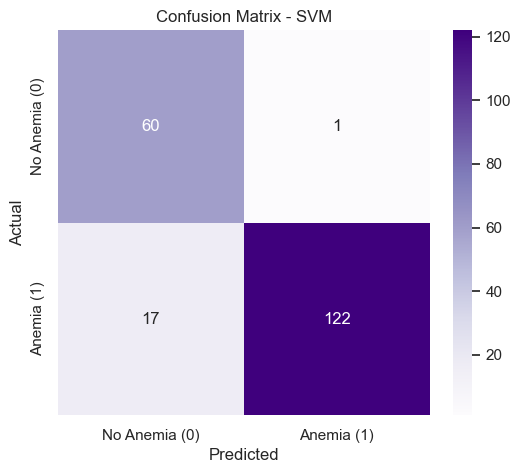


🔹 Final Results for Support Vector Machine Model:
🔹 Accuracy: 0.910, AUC: 0.958


In [133]:
#Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test_enc, y_pred_svm)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Purples', 
            xticklabels = ['No Anemia (0)', 'Anemia (1)'], 
            yticklabels = ['No Anemia (0)', 'Anemia (1)'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")
plt.show()
# Compute Accuracy & AUC
accuracy_svm = accuracy_score(y_test_enc, y_pred_svm)
roc_auc_svm = roc_auc_score(y_test_enc, y_prob_svm)  # Using probability predictions

# Display Accuracy & AUC
print(f"\n🔹 Final Results for Support Vector Machine Model:")
print(f"🔹 Accuracy: {accuracy_svm:.3f}, AUC: {roc_auc_svm:.3f}")

In [48]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import numpy as np

# Stratified K-Fold setup
k_folds = 5
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Storage for metrics
accuracy_scores = []
auc_scores = []
classification_reports = []

for fold, (train_index, test_index) in enumerate(kf.split(X_train_fs_new, y_train_resampled), 1):
    # Split data
    X_train_fold, X_test_fold = X_train_fs_new[train_index], X_train_fs_new[test_index]
    y_train_fold, y_test_fold = y_train_resampled[train_index], y_train_resampled[test_index]

    # Initialize and train model
    classifier_svm = SVC(probability=True, kernel='rbf', class_weight='balanced', random_state=0)
    classifier_svm.fit(X_train_fold, y_train_fold)

    # Predict
    y_pred_fold = classifier_svm.predict(X_test_fold)
    y_proba_fold = classifier_svm.predict_proba(X_test_fold)[:, 1]  # Probability for class 1

    # Evaluate
    acc = accuracy_score(y_test_fold, y_pred_fold)
    auc = roc_auc_score(y_test_fold, y_proba_fold)

    accuracy_scores.append(acc)
    auc_scores.append(auc)
    classification_reports.append(classification_report(y_test_fold, y_pred_fold, output_dict=True))

    print(f"\n🌀 Fold {fold} Accuracy: {acc:.4f}")
    print(f"📈 Fold {fold} AUC: {auc:.4f}")
    print(classification_report(y_test_fold, y_pred_fold))

# Final averaged results
avg_accuracy = np.mean(accuracy_scores)
avg_auc = np.mean(auc_scores)

print(f"\n✅ Average Accuracy (SVM) across {k_folds} folds: {avg_accuracy:.4f}")
print(f"✅ Average AUC (SVM) across {k_folds} folds: {avg_auc:.4f}")



🌀 Fold 1 Accuracy: 0.9293
📈 Fold 1 AUC: 0.9407
              precision    recall  f1-score   support

           0       0.88      0.99      0.93        99
           1       0.99      0.87      0.92        99

    accuracy                           0.93       198
   macro avg       0.94      0.93      0.93       198
weighted avg       0.94      0.93      0.93       198


🌀 Fold 2 Accuracy: 0.9086
📈 Fold 2 AUC: 0.9116
              precision    recall  f1-score   support

           0       0.87      0.96      0.91        98
           1       0.96      0.86      0.90        99

    accuracy                           0.91       197
   macro avg       0.91      0.91      0.91       197
weighted avg       0.91      0.91      0.91       197


🌀 Fold 3 Accuracy: 0.9442
📈 Fold 3 AUC: 0.9840
              precision    recall  f1-score   support

           0       0.93      0.96      0.94        98
           1       0.96      0.93      0.94        99

    accuracy                          

In [270]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from scipy.stats import loguniform
import optuna

# ---------------- GRID SEARCH ---------------- #
param_grid_svm = {
    'C': [0.1, 1, 10, 100, 1000],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3, 4]  # Only affects 'poly' kernel
}

grid_search_svm = GridSearchCV(SVC(class_weight='balanced', random_state=0),
                               param_grid_svm,
                               cv=5,
                               scoring='accuracy',
                               verbose=1,
                               n_jobs=-1)

grid_search_svm.fit(X_train_fs_new, y_train_resampled)

best_grid_svm = grid_search_svm.best_estimator_
print("\n🔹 GridSearch Best Hyperparameters (SVM):", grid_search_svm.best_params_)
print("🔹 GridSearch Best Accuracy:", grid_search_svm.best_score_)

# ---------------- RANDOM SEARCH ---------------- #
param_dist_svm = {
    'C': loguniform(0.001, 1000),
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3, 4]
}

random_search_svm = RandomizedSearchCV(SVC(class_weight='balanced', random_state=0),
                                       param_distributions=param_dist_svm,
                                       n_iter=30,  # Try 30 random combinations
                                       cv=5,
                                       scoring='accuracy',
                                       random_state=42,
                                       verbose=1,
                                       n_jobs=-1)

random_search_svm.fit(X_train_fs_new, y_train_resampled)

best_random_svm = random_search_svm.best_estimator_
print("\n🔹 RandomSearch Best Hyperparameters (SVM):", random_search_svm.best_params_)
print("🔹 RandomSearch Best Accuracy:", random_search_svm.best_score_)

# ---------------- OPTUNA BAYESIAN OPTIMIZATION ---------------- #
def objective_svm(trial):
    C = trial.suggest_float('C', 0.001, 1000, log=True)
    kernel = trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly', 'sigmoid'])
    gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])
    
    degree = 3  # Default degree for non-poly kernels
    if kernel == 'poly':
        degree = trial.suggest_int('degree', 2, 4)

    model = SVC(C=C, kernel=kernel, gamma=gamma, degree=degree, class_weight='balanced', random_state=0)
    scores = cross_val_score(model, X_train_fs_new, y_train_resampled, cv=5, scoring='accuracy')
    return scores.mean()

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=50)

best_bayes_svm = SVC(**study_svm.best_params, class_weight='balanced', random_state=0)
best_bayes_svm.fit(X_train_fs_new, y_train_resampled)

print("\n🔹 Bayesian Optimization Best Hyperparameters (SVM):", study_svm.best_params)
print("🔹 Bayesian Optimization Best Accuracy:", study_svm.best_value)


Fitting 5 folds for each of 120 candidates, totalling 600 fits

🔹 GridSearch Best Hyperparameters (SVM): {'C': 10, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}
🔹 GridSearch Best Accuracy: 0.9371327488078757
Fitting 5 folds for each of 30 candidates, totalling 150 fits


[I 2025-03-26 13:10:04,256] A new study created in memory with name: no-name-02245611-7b01-45c7-9b3d-87f8b84d0cb6
[I 2025-03-26 13:10:04,420] Trial 0 finished with value: 0.6458134645951905 and parameters: {'C': 0.005283384642358953, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 0 with value: 0.6458134645951905.



🔹 RandomSearch Best Hyperparameters (SVM): {'C': 4.676478725076045, 'degree': 2, 'gamma': 'auto', 'kernel': 'linear'}
🔹 RandomSearch Best Accuracy: 0.9361175203814798


[I 2025-03-26 13:10:04,485] Trial 1 finished with value: 0.8306516946110853 and parameters: {'C': 1.7305096198908363, 'kernel': 'sigmoid', 'gamma': 'auto'}. Best is trial 1 with value: 0.8306516946110853.
[I 2025-03-26 13:10:04,525] Trial 2 finished with value: 0.9290109213967082 and parameters: {'C': 0.22155157105193254, 'kernel': 'linear', 'gamma': 'scale'}. Best is trial 2 with value: 0.9290109213967082.
[I 2025-03-26 13:10:04,634] Trial 3 finished with value: 0.9138183869148335 and parameters: {'C': 0.10003110233118646, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 2 with value: 0.9290109213967082.
[I 2025-03-26 13:10:04,691] Trial 4 finished with value: 0.9381377224016818 and parameters: {'C': 2.408711135753723, 'kernel': 'linear', 'gamma': 'scale'}. Best is trial 4 with value: 0.9381377224016818.
[I 2025-03-26 13:10:04,755] Trial 5 finished with value: 0.9199046300569144 and parameters: {'C': 5.632220942994599, 'kernel': 'poly', 'gamma': 'scale', 'degree': 4}. Best is trial 4


🔹 Bayesian Optimization Best Hyperparameters (SVM): {'C': 2.408711135753723, 'kernel': 'linear', 'gamma': 'scale'}
🔹 Bayesian Optimization Best Accuracy: 0.9381377224016818


In [274]:
from scipy.stats import uniform  # 🔧 FIXED: Import this for the 'uniform' distribution
#Grid Search
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

grid_search_svm = GridSearchCV(
    estimator=SVC(probability=True, random_state=0),
    param_grid=param_grid_svm,
    cv=5,
    scoring={'accuracy': 'accuracy', 'roc_auc': 'roc_auc'},
    refit='roc_auc',
    verbose=1,
    n_jobs=-1
)

grid_search_svm.fit(X_train_fs_new, y_train_resampled)

print("\n🔹 GridSearch Best Hyperparameters (SVM):", grid_search_svm.best_params_)
print("🔹 GridSearch Best AUC:", grid_search_svm.best_score_)
best_grid_svm = grid_search_svm.best_estimator_
param_dist_svm = {
    'C': uniform(0.1, 100),
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}
#Randomize search
random_search_svm = RandomizedSearchCV(
    estimator=SVC(probability=True, random_state=0),
    param_distributions=param_dist_svm,
    n_iter=30,
    cv=5,
    scoring={'accuracy': 'accuracy', 'roc_auc': 'roc_auc'},
    refit='roc_auc',
    random_state=42,
    verbose=1,
    n_jobs=-1
)

random_search_svm.fit(X_train_fs_new, y_train_resampled)

print("\n🔹 RandomSearch Best Hyperparameters (SVM):", random_search_svm.best_params_)
print("🔹 RandomSearch Best AUC:", random_search_svm.best_score_)
best_random_svm = random_search_svm.best_estimator_
#Bayesian
def objective_svm(trial):
    C = trial.suggest_loguniform('C', 0.1, 100)
    kernel = trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly'])
    gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])

    model = SVC(C=C, kernel=kernel, gamma=gamma, probability=True, random_state=0)
    scores = cross_val_score(model, X_train_fs_new, y_train_resampled, cv=5, scoring='roc_auc')
    return scores.mean()

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=50)

print("\n🔹 Bayesian Optimization Best Hyperparameters (SVM):", study_svm.best_params)
print("🔹 Bayesian Optimization Best AUC:", study_svm.best_value)

best_bayes_svm = SVC(**study_svm.best_params, probability=True, random_state=0)
best_bayes_svm.fit(X_train_fs_new, y_train_resampled)


Fitting 5 folds for each of 24 candidates, totalling 120 fits

🔹 GridSearch Best Hyperparameters (SVM): {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
🔹 GridSearch Best AUC: 0.9540615389100238
Fitting 5 folds for each of 30 candidates, totalling 150 fits


[I 2025-03-26 13:10:59,799] A new study created in memory with name: no-name-3afb2120-29f5-499f-9cf6-b2f80a9beaa6



🔹 RandomSearch Best Hyperparameters (SVM): {'C': 5.908361216819946, 'gamma': 'auto', 'kernel': 'linear'}
🔹 RandomSearch Best AUC: 0.9534202049353565


C:\Users\HungPhatPC\AppData\Local\Temp\ipykernel_17012\1729344988.py:49: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C = trial.suggest_loguniform('C', 0.1, 100)
[I 2025-03-26 13:11:00,080] Trial 0 finished with value: 0.9407440723458039 and parameters: {'C': 8.052004104962196, 'kernel': 'poly', 'gamma': 'auto'}. Best is trial 0 with value: 0.9407440723458039.
C:\Users\HungPhatPC\AppData\Local\Temp\ipykernel_17012\1729344988.py:49: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C = trial.suggest_loguniform('C', 0.1, 100)
[I 2025-03-26 13:11:00,559] Trial 1 finished with value: 0.9429654200216971 and parameters: {'C': 85.36743434337265, 'kernel': 'poly', 'gamma': 'auto'}


🔹 Bayesian Optimization Best Hyperparameters (SVM): {'C': 0.6947112990903589, 'kernel': 'rbf', 'gamma': 'scale'}
🔹 Bayesian Optimization Best AUC: 0.9546568550897556


SVC(C=0.6947112990903589, probability=True, random_state=0)

## ANN 

In [130]:
pip install torch

Note: you may need to restart the kernel to use updated packages.


In [52]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Convert selected features into PyTorch tensors
X_train_tensor = torch.tensor(X_train_fs_new, dtype=torch.double)
y_train_tensor = torch.tensor(y_train_resampled, dtype=torch.double).view(-1, 1)
X_test_tensor = torch.tensor(X_test_fs_new, dtype=torch.double)
y_test_tensor = torch.tensor(y_test_enc, dtype=torch.double).view(-1, 1)


In [53]:
# Define ANN architecture
class ANNModel(nn.Module):
    def __init__(self, input_size):
        super(ANNModel, self).__init__()
        self.fc1 = nn.Linear(input_size, 16, dtype=torch.double)  # Hidden layer with 16 neurons
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 1, dtype=torch.double)  # Output layer (binary classification)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

# Initialize the model
input_size = X_train_fs_new.shape[1]
model = ANNModel(input_size)

# Define loss function and optimizer
criterion = nn.BCELoss()  # Binary Cross-Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 100
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

print("Training complete!")


Epoch [10/100], Loss: 0.6804
Epoch [20/100], Loss: 0.6564
Epoch [30/100], Loss: 0.6327
Epoch [40/100], Loss: 0.6092
Epoch [50/100], Loss: 0.5857
Epoch [60/100], Loss: 0.5624
Epoch [70/100], Loss: 0.5396
Epoch [80/100], Loss: 0.5173
Epoch [90/100], Loss: 0.4958
Epoch [100/100], Loss: 0.4752
Training complete!


In [60]:
# Evaluate the model
with torch.no_grad():
    y_test_pred = model(X_test_tensor)
    y_test_pred_label = (y_test_pred > 0.5).float()

# Convert to numpy for sklearn metrics
y_test_pred_label_np = y_test_pred_label.numpy()
y_test_pred_prob_np = y_test_pred.numpy()
y_test_np = y_test_tensor.numpy()

# Calculate accuracy and AUC
acc = accuracy_score(y_test_np, y_test_pred_label_np)
auc = roc_auc_score(y_test_np, y_test_pred_prob_np)
# Display classification report
print("\n🔹Classification Report of ANN:")
print(classification_report(y_test_np, y_test_pred_label_np))

# Display final accuracy and AUC
print("\n🔹Final Results for ANN Model:")
print(f"Accuracy: {acc:.3f}, AUC: {auc:.3f}")




🔹Classification Report of ANN:
              precision    recall  f1-score   support

         0.0       0.72      0.95      0.82        61
         1.0       0.97      0.83      0.90       139

    accuracy                           0.87       200
   macro avg       0.85      0.89      0.86       200
weighted avg       0.90      0.87      0.87       200


🔹Final Results for ANN Model:
Accuracy: 0.870, AUC: 0.944


In [180]:
# Predict with ANN
with torch.no_grad():
    y_pred_ann_tensor = model(X_test_tensor)  # Get raw output (logits)
    y_pred_ann_label = (y_pred_ann_tensor > 0.5).float()  # Convert to binary (0 or 1)

# Convert to NumPy for DataFrame output
y_pred_ann_np = y_pred_ann_label.numpy()
y_prob_ann_np = y_pred_ann_tensor.numpy()  # Probabilities

# Store predictions in a DataFrame like LR
results_ann_df = pd.DataFrame({
    'Predicted': y_pred_ann_np.flatten(),
    'Actual': y_test_enc.flatten(),
    'Probability': y_prob_ann_np.flatten()
})

# Round probability values like LR
results_ann_df['Probability'] = results_ann_df['Probability'].round(4)

# Print first 20 rows
print(results_ann_df.head(20))


    Predicted  Actual  Probability
0         1.0       1       0.6977
1         1.0       1       0.5815
2         1.0       1       0.5802
3         1.0       1       0.7569
4         0.0       0       0.3580
5         0.0       0       0.4753
6         0.0       0       0.4147
7         0.0       0       0.4155
8         1.0       1       0.5296
9         1.0       1       0.5248
10        1.0       1       0.6528
11        0.0       0       0.3315
12        1.0       1       0.7098
13        1.0       1       0.9169
14        0.0       0       0.3613
15        0.0       0       0.3702
16        1.0       1       0.5844
17        1.0       1       0.9875
18        1.0       1       0.7853
19        1.0       1       0.7974


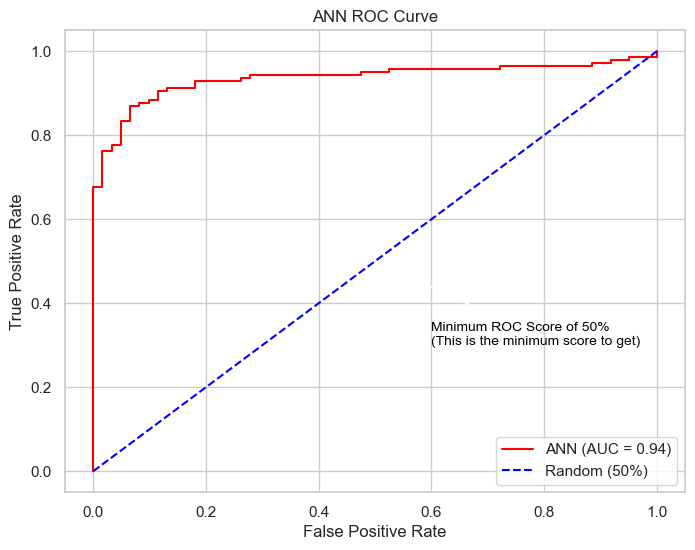

In [184]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
# Compute ROC curve and AUC score
fpr_ann, tpr_ann, _ = roc_curve(y_test_np, y_test_pred_prob_np)
roc_auc = auc(fpr_ann, tpr_ann)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
sns.set(style="whitegrid")

# ROC curve
plt.plot(fpr_ann, tpr_ann, color='Red', label=f'ANN (AUC = {roc_auc:.2f})')

# Baseline (Random Model) at 50%
plt.plot([0, 1], [0, 1], color='blue', linestyle='--', label="Random (50%)")  

# Add annotation
plt.annotate("Minimum ROC Score of 50%\n(This is the minimum score to get)",
             xy=(0.5, 0.5), xytext=(0.6, 0.3),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10, color='black')

# Labels & Title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ANN ROC Curve")
plt.legend(loc="lower right")

# Show the plot
plt.show()


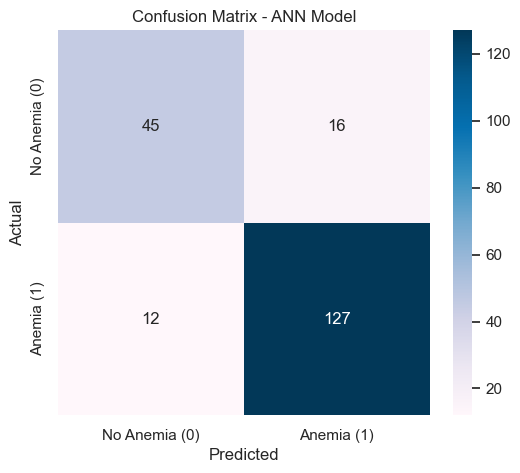


🔹Final Results for ANN Model:
Accuracy: 0.860, AUC: 0.936


In [106]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
# Compute confusion matrix
cm_ann = confusion_matrix(y_test_np, y_test_pred_label_np)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='PuBu',
            xticklabels=['No Anemia (0)', 'Anemia (1)'],
            yticklabels=['No Anemia (0)', 'Anemia (1)'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - ANN Model")
plt.show()

# Calculate accuracy and AUC
acc = accuracy_score(y_test_np, y_test_pred_label_np)
auc = roc_auc_score(y_test_np, y_test_pred_prob_np)

# Display final accuracy and AUC
print("\n🔹Final Results for ANN Model:")
print(f"Accuracy: {acc:.3f}, AUC: {auc:.3f}")

In [108]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold

# Define K-Fold Cross Validation
k_folds = 5
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Store scores
accuracy_scores = []
classification_reports = []

for train_index, test_index in kf.split(X_train_fs, y_train_resampled):
    # Split data into training and validation for this fold
    X_train_fold, X_test_fold = X_train_fs[train_index], X_train_fs[test_index]
    y_train_fold, y_test_fold = y_train_resampled[train_index], y_train_resampled[test_index]

    # Convert to PyTorch tensors
    X_train_fold_tensor = torch.tensor(X_train_fold, dtype=torch.double)
    y_train_fold_tensor = torch.tensor(y_train_fold, dtype=torch.double).view(-1, 1)
    X_test_fold_tensor = torch.tensor(X_test_fold, dtype=torch.double)
    y_test_fold_tensor = torch.tensor(y_test_fold, dtype=torch.double).view(-1, 1)
    
    # Initialize the model
    input_size = X_train_fold.shape[1]
    model = ANNModel(input_size)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # Training loop
    epochs = 100
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X_train_fold_tensor)
        loss = criterion(outputs, y_train_fold_tensor)
        loss.backward()
        optimizer.step()
        
    # Evaluate the model
    with torch.no_grad():
        y_test_pred_fold = model(X_test_fold_tensor)
        y_test_pred_label_fold = (y_test_pred_fold > 0.5).float()
    
    # Convert to numpy for sklearn metrics
    y_test_pred_label_fold_np = y_test_pred_label_fold.numpy()
    y_test_fold_np = y_test_fold_tensor.numpy()
    
    # Evaluate performance
    acc = accuracy_score(y_test_fold_np, y_test_pred_label_fold_np)
    accuracy_scores.append(acc)
    classification_reports.append(classification_report(y_test_fold_np, y_test_pred_label_fold_np, output_dict=True))

    print(f"Fold Accuracy: {acc:.4f}")
    print(classification_report(y_test_fold_np, y_test_pred_label_fold_np))

# Average performance across folds
avg_accuracy = np.mean(accuracy_scores)
print(f"\nAverage Accuracy across {k_folds} folds: {avg_accuracy:.4f}")

Fold Accuracy: 0.8838
              precision    recall  f1-score   support

         0.0       0.82      0.99      0.89        99
         1.0       0.99      0.78      0.87        99

    accuracy                           0.88       198
   macro avg       0.90      0.88      0.88       198
weighted avg       0.90      0.88      0.88       198

Fold Accuracy: 0.8680
              precision    recall  f1-score   support

         0.0       0.83      0.93      0.88        98
         1.0       0.92      0.81      0.86        99

    accuracy                           0.87       197
   macro avg       0.87      0.87      0.87       197
weighted avg       0.87      0.87      0.87       197

Fold Accuracy: 0.8376
              precision    recall  f1-score   support

         0.0       0.75      1.00      0.86        98
         1.0       1.00      0.68      0.81        99

    accuracy                           0.84       197
   macro avg       0.88      0.84      0.83       197
weighted

In [62]:
from sklearn.metrics import roc_auc_score

# Additional score list
auc_scores = []

for train_index, test_index in kf.split(X_train_fs, y_train_resampled):
    # Split data
    X_train_fold, X_test_fold = X_train_fs[train_index], X_train_fs[test_index]
    y_train_fold, y_test_fold = y_train_resampled[train_index], y_train_resampled[test_index]

    # Tensors
    X_train_tensor = torch.tensor(X_train_fold, dtype=torch.double)
    y_train_tensor = torch.tensor(y_train_fold, dtype=torch.double).view(-1, 1)
    X_test_tensor = torch.tensor(X_test_fold, dtype=torch.double)
    y_test_tensor = torch.tensor(y_test_fold, dtype=torch.double).view(-1, 1)

    # Model
    input_size = X_train_tensor.shape[1]
    model = ANNModel(input_size)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Train
    for epoch in range(100):
        optimizer.zero_grad()
        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        loss.backward()
        optimizer.step()

    # Predict
    with torch.no_grad():
        y_pred_probs = model(X_test_tensor)               # 💡 Keep as raw sigmoid output
        y_pred_labels = (y_pred_probs > 0.5).float()

    # Convert to NumPy
    y_true = y_test_tensor.numpy()
    y_labels = y_pred_labels.numpy()
    y_probs = y_pred_probs.numpy()

    # Metrics
    acc = accuracy_score(y_true, y_labels)
    auc = roc_auc_score(y_true, y_probs)

    accuracy_scores.append(acc)
    auc_scores.append(auc)
    classification_reports.append(classification_report(y_true, y_labels, output_dict=True))

    print(f"📘 Fold Accuracy: {acc:.4f}")
    print(f"📈 Fold AUC: {auc:.4f}")
    print(classification_report(y_true, y_labels))

# Final results
avg_accuracy = np.mean(accuracy_scores)
avg_auc = np.mean(auc_scores)

print(f"\n✅ Average Accuracy (ANN) across {k_folds} folds: {avg_accuracy:.4f}")
print(f"✅ Average AUC (ANN) across {k_folds} folds: {avg_auc:.4f}")


📘 Fold Accuracy: 0.9242
📈 Fold AUC: 0.9644
              precision    recall  f1-score   support

         0.0       0.88      0.98      0.93        99
         1.0       0.98      0.87      0.92        99

    accuracy                           0.92       198
   macro avg       0.93      0.92      0.92       198
weighted avg       0.93      0.92      0.92       198

📘 Fold Accuracy: 0.8934
📈 Fold AUC: 0.9384
              precision    recall  f1-score   support

         0.0       0.85      0.95      0.90        98
         1.0       0.94      0.84      0.89        99

    accuracy                           0.89       197
   macro avg       0.90      0.89      0.89       197
weighted avg       0.90      0.89      0.89       197

📘 Fold Accuracy: 0.9239
📈 Fold AUC: 0.9858
              precision    recall  f1-score   support

         0.0       0.87      0.99      0.93        98
         1.0       0.99      0.86      0.92        99

    accuracy                           0.92       197

In [266]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from scipy.stats import randint, uniform
import optuna

# ---------------- DEFINE ANN MODEL ---------------- #
class ANNModel(nn.Module):
    def __init__(self, input_size, hidden_size, activation_fn):
        super(ANNModel, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size, dtype=torch.double)
        self.activation = activation_fn
        self.fc2 = nn.Linear(hidden_size, 1, dtype=torch.double)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.activation(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

# Convert dataset to PyTorch tensors
X_train_tensor = torch.tensor(X_train_fs_new, dtype=torch.double)
y_train_tensor = torch.tensor(y_train_resampled, dtype=torch.double).view(-1, 1)
X_test_tensor = torch.tensor(X_test_fs_new, dtype=torch.double)
y_test_tensor = torch.tensor(y_test_enc, dtype=torch.double).view(-1, 1)

input_size = X_train_fs_new.shape[1]  # Number of features

# ---------------- GRID SEARCH ---------------- #
grid_params = {
    'hidden_size': [8, 16, 32, 64],
    'activation_fn': [nn.ReLU(), nn.Tanh(), nn.Sigmoid()],
    'learning_rate': [0.001, 0.01, 0.1],
}

best_acc = 0
best_grid_model = None
best_grid_params = {}

for hidden_size in grid_params['hidden_size']:
    for activation_fn in grid_params['activation_fn']:
        for lr in grid_params['learning_rate']:
            model = ANNModel(input_size, hidden_size, activation_fn)
            criterion = nn.BCELoss()
            optimizer = optim.Adam(model.parameters(), lr=lr)
            
            # Train model
            epochs = 50
            for epoch in range(epochs):
                optimizer.zero_grad()
                outputs = model(X_train_tensor)
                loss = criterion(outputs, y_train_tensor)
                loss.backward()
                optimizer.step()

            # Evaluate
            with torch.no_grad():
                y_test_pred = model(X_test_tensor)
                y_test_pred_label = (y_test_pred > 0.5).float()
            acc = accuracy_score(y_test_tensor.numpy(), y_test_pred_label.numpy())
            
            if acc > best_acc:
                best_acc = acc
                best_grid_model = model
                best_grid_params = {'hidden_size': hidden_size, 'activation_fn': activation_fn, 'learning_rate': lr}

print("\n🔹 Grid Search Best Hyperparameters (ANN):", best_grid_params)
print("🔹 Grid Search Best Accuracy:", best_acc)

# ---------------- RANDOMIZED SEARCH ---------------- #
random_params = {
    'hidden_size': randint(8, 128),
    'activation_fn': [nn.ReLU(), nn.Tanh(), nn.Sigmoid()],
    'learning_rate': uniform(0.0001, 0.1),
}

best_random_acc = 0
best_random_model = None
best_random_params = {}

for _ in range(20):  # 20 random trials
    hidden_size = random_params['hidden_size'].rvs()
    activation_fn = np.random.choice(random_params['activation_fn'])
    lr = random_params['learning_rate'].rvs()
    
    model = ANNModel(input_size, hidden_size, activation_fn)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Train model
    for epoch in range(50):
        optimizer.zero_grad()
        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        loss.backward()
        optimizer.step()

    # Evaluate
    with torch.no_grad():
        y_test_pred = model(X_test_tensor)
        y_test_pred_label = (y_test_pred > 0.5).float()
    acc = accuracy_score(y_test_tensor.numpy(), y_test_pred_label.numpy())

    if acc > best_random_acc:
        best_random_acc = acc
        best_random_model = model
        best_random_params = {'hidden_size': hidden_size, 'activation_fn': activation_fn, 'learning_rate': lr}

print("\n🔹 Random Search Best Hyperparameters (ANN):", best_random_params)
print("🔹 Random Search Best Accuracy:", best_random_acc)

# ---------------- OPTUNA BAYESIAN OPTIMIZATION ---------------- #
def objective_ann(trial):
    hidden_size = trial.suggest_int('hidden_size', 8, 128)
    activation_fn_name = trial.suggest_categorical('activation_fn', ['ReLU', 'Tanh', 'Sigmoid'])
    lr = trial.suggest_float('learning_rate', 0.0001, 0.1, log=True)

    # Map string to PyTorch activation function
    activation_fn = {
        'ReLU': nn.ReLU(),
        'Tanh': nn.Tanh(),
        'Sigmoid': nn.Sigmoid()
    }[activation_fn_name]

    model = ANNModel(input_size, hidden_size, activation_fn)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Train model
    for epoch in range(50):
        optimizer.zero_grad()
        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        loss.backward()
        optimizer.step()

    # Evaluate
    with torch.no_grad():
        y_test_pred = model(X_test_tensor)
        y_test_pred_label = (y_test_pred > 0.5).float()
    acc = accuracy_score(y_test_tensor.numpy(), y_test_pred_label.numpy())

    return acc

study_ann = optuna.create_study(direction='maximize')
study_ann.optimize(objective_ann, n_trials=30)

best_bayes_ann_params = study_ann.best_params
best_bayes_ann = ANNModel(input_size, best_bayes_ann_params['hidden_size'], best_bayes_ann_params['activation_fn'])
best_bayes_ann.eval()

print("\n🔹 Bayesian Optimization Best Hyperparameters (ANN):", best_bayes_ann_params)
print("🔹 Bayesian Optimization Best Accuracy:", study_ann.best_value)



🔹 Grid Search Best Hyperparameters (ANN): {'hidden_size': 64, 'activation_fn': Sigmoid(), 'learning_rate': 0.1}
🔹 Grid Search Best Accuracy: 0.94


[I 2025-03-21 17:52:05,653] A new study created in memory with name: no-name-840fb308-d306-4fae-852e-a4b5cc605654
[I 2025-03-21 17:52:05,700] Trial 0 finished with value: 0.88 and parameters: {'hidden_size': 9, 'activation_fn': 'ReLU', 'learning_rate': 0.002657117143318931}. Best is trial 0 with value: 0.88.
[I 2025-03-21 17:52:05,769] Trial 1 finished with value: 0.935 and parameters: {'hidden_size': 80, 'activation_fn': 'Sigmoid', 'learning_rate': 0.06488914353847099}. Best is trial 1 with value: 0.935.
[I 2025-03-21 17:52:05,845] Trial 2 finished with value: 0.86 and parameters: {'hidden_size': 83, 'activation_fn': 'Sigmoid', 'learning_rate': 0.001227435303159549}. Best is trial 1 with value: 0.935.



🔹 Random Search Best Hyperparameters (ANN): {'hidden_size': 85, 'activation_fn': Sigmoid(), 'learning_rate': 0.08029962869653935}
🔹 Random Search Best Accuracy: 0.94


[I 2025-03-21 17:52:05,931] Trial 3 finished with value: 0.915 and parameters: {'hidden_size': 93, 'activation_fn': 'Tanh', 'learning_rate': 0.00583855327559802}. Best is trial 1 with value: 0.935.
[I 2025-03-21 17:52:06,007] Trial 4 finished with value: 0.89 and parameters: {'hidden_size': 87, 'activation_fn': 'Tanh', 'learning_rate': 0.0011764222217476553}. Best is trial 1 with value: 0.935.
[I 2025-03-21 17:52:06,094] Trial 5 finished with value: 0.88 and parameters: {'hidden_size': 125, 'activation_fn': 'Sigmoid', 'learning_rate': 0.0029928185154378182}. Best is trial 1 with value: 0.935.
[I 2025-03-21 17:52:06,182] Trial 6 finished with value: 0.935 and parameters: {'hidden_size': 125, 'activation_fn': 'Sigmoid', 'learning_rate': 0.0956676090966189}. Best is trial 1 with value: 0.935.
[I 2025-03-21 17:52:06,232] Trial 7 finished with value: 0.935 and parameters: {'hidden_size': 23, 'activation_fn': 'ReLU', 'learning_rate': 0.06685853878376087}. Best is trial 1 with value: 0.935.
[


🔹 Bayesian Optimization Best Hyperparameters (ANN): {'hidden_size': 80, 'activation_fn': 'Sigmoid', 'learning_rate': 0.06488914353847099}
🔹 Bayesian Optimization Best Accuracy: 0.935


In [291]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from scipy.stats import randint, uniform
import optuna

# ---------------- DEFINE ANN MODEL ---------------- #
class ANNModel(nn.Module):
    def __init__(self, input_size, hidden_size, activation_fn):
        super(ANNModel, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size, dtype=torch.double)
        self.activation = activation_fn
        self.fc2 = nn.Linear(hidden_size, 1, dtype=torch.double)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.activation(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

# Convert dataset to PyTorch tensors
X_train_tensor = torch.tensor(X_train_fs_new, dtype=torch.double)
y_train_tensor = torch.tensor(y_train_resampled, dtype=torch.double).view(-1, 1)
X_test_tensor = torch.tensor(X_test_fs_new, dtype=torch.double)
y_test_tensor = torch.tensor(y_test_enc, dtype=torch.double).view(-1, 1)

input_size = X_train_fs_new.shape[1]  # Number of features

# ---------------- GRID SEARCH ---------------- #
grid_params = {
    'hidden_size': [8, 16, 32, 64],
    'activation_fn': [nn.ReLU(), nn.Tanh(), nn.Sigmoid()],
    'learning_rate': [0.001, 0.01, 0.1],
}

best_acc = 0
best_auc = 0
best_grid_model = None
best_grid_params = {}

for hidden_size in grid_params['hidden_size']:
    for activation_fn in grid_params['activation_fn']:
        for lr in grid_params['learning_rate']:
            model = ANNModel(input_size, hidden_size, activation_fn)
            criterion = nn.BCELoss()
            optimizer = optim.Adam(model.parameters(), lr=lr)
            
            for epoch in range(50):
                optimizer.zero_grad()
                outputs = model(X_train_tensor)
                loss = criterion(outputs, y_train_tensor)
                loss.backward()
                optimizer.step()

            with torch.no_grad():
                y_test_pred = model(X_test_tensor)
                y_pred_label = (y_test_pred > 0.5).float()
                y_true = y_test_tensor.numpy()
                y_proba = y_test_pred.numpy()

            acc = accuracy_score(y_true, y_pred_label.numpy())
            auc = roc_auc_score(y_true, y_proba)

            if auc > best_auc:  # You can use AUC as your main metric
                best_acc = acc
                best_auc = auc
                best_grid_model = model
                best_grid_params = {
                    'hidden_size': hidden_size,
                    'activation_fn': activation_fn,
                    'learning_rate': lr
                }

print("\n🔹 Grid Search Best Hyperparameters (ANN):", best_grid_params)
print("🔹 Grid Search Best Accuracy:", best_acc)
print("🔹 Grid Search Best AUC:", best_auc)

# ---------------- RANDOMIZED SEARCH ---------------- #
random_params = {
    'hidden_size': randint(8, 128),
    'activation_fn': [nn.ReLU(), nn.Tanh(), nn.Sigmoid()],
    'learning_rate': uniform(0.0001, 0.1),
}

best_random_acc = 0
best_random_model = None
best_random_params = {}

for _ in range(20):  # 20 random trials
    hidden_size = random_params['hidden_size'].rvs()
    activation_fn = np.random.choice(random_params['activation_fn'])
    lr = random_params['learning_rate'].rvs()
    
    model = ANNModel(input_size, hidden_size, activation_fn)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Train model
    for epoch in range(50):
        optimizer.zero_grad()
        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        loss.backward()
        optimizer.step()

    # Evaluate
    with torch.no_grad():
        y_test_pred = model(X_test_tensor)
        y_test_pred_label = (y_test_pred > 0.5).float()
    acc = accuracy_score(y_test_tensor.numpy(), y_test_pred_label.numpy())

    if acc > best_random_acc:
        best_random_acc = acc
        best_random_model = model
        best_random_params = {'hidden_size': hidden_size, 'activation_fn': activation_fn, 'learning_rate': lr}

print("\n🔹 Random Search Best Hyperparameters (ANN):", best_random_params)
print("🔹 Random Search Best Accuracy:", best_random_acc)

# ---------------- OPTUNA BAYESIAN OPTIMIZATION ---------------- #
from sklearn.metrics import accuracy_score, roc_auc_score

def objective_ann(trial):
    hidden_size = trial.suggest_int('hidden_size', 8, 128)
    activation_fn_name = trial.suggest_categorical('activation_fn', ['ReLU', 'Tanh', 'Sigmoid'])
    lr = trial.suggest_float('learning_rate', 0.0001, 0.1, log=True)

    # Map string to PyTorch activation function
    activation_fn = {
        'ReLU': nn.ReLU(),
        'Tanh': nn.Tanh(),
        'Sigmoid': nn.Sigmoid()
    }[activation_fn_name]

    model = ANNModel(input_size, hidden_size, activation_fn)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Train model
    for epoch in range(50):
        optimizer.zero_grad()
        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        loss.backward()
        optimizer.step()

    # Evaluate
    with torch.no_grad():
        y_test_pred = model(X_test_tensor)
        y_test_pred_label = (y_test_pred > 0.5).float()

        y_true = y_test_tensor.numpy()
        y_proba = y_test_pred.numpy()
        y_label = y_test_pred_label.numpy()

        acc = accuracy_score(y_true, y_label)
        auc = roc_auc_score(y_true, y_proba)

    return auc  # 🧠 Use AUC as optimization target

study_ann = optuna.create_study(direction='maximize')
study_ann.optimize(objective_ann, n_trials=30)

best_bayes_ann_params = study_ann.best_params
best_bayes_ann = ANNModel(input_size, best_bayes_ann_params['hidden_size'], best_bayes_ann_params['activation_fn'])
best_bayes_ann.eval()

print("\n🔹 Bayesian Optimization Best Hyperparameters (ANN):", study_ann.best_params)
print("🔹 Bayesian Optimization Best AUC:", study_ann.best_value)

# Optional: Evaluate final model for accuracy
best_params = study_ann.best_params
best_activation = {
    'ReLU': nn.ReLU(),
    'Tanh': nn.Tanh(),
    'Sigmoid': nn.Sigmoid()
}[best_params['activation_fn']]

best_bayes_ann = ANNModel(input_size, best_params['hidden_size'], best_activation)
best_bayes_ann.eval()

# Evaluate
with torch.no_grad():
    y_pred = best_bayes_ann(X_test_tensor)
    y_label = (y_pred > 0.5).float()
    acc = accuracy_score(y_test_tensor.numpy(), y_label.numpy())
    auc = roc_auc_score(y_test_tensor.numpy(), y_pred.numpy())

print("🔹 Final Accuracy (Bayesian ANN):", acc)
print("🔹 Final AUC (Bayesian ANN):", auc)




🔹 Grid Search Best Hyperparameters (ANN): {'hidden_size': 32, 'activation_fn': ReLU(), 'learning_rate': 0.1}
🔹 Grid Search Best Accuracy: 0.935
🔹 Grid Search Best AUC: 0.966033730392735


[I 2025-03-26 13:20:16,715] A new study created in memory with name: no-name-ebdd3001-9af0-4be2-94b4-9b746b5d4ac0
[I 2025-03-26 13:20:16,768] Trial 0 finished with value: 0.9455124425050123 and parameters: {'hidden_size': 124, 'activation_fn': 'Sigmoid', 'learning_rate': 0.0027822049994373267}. Best is trial 0 with value: 0.9455124425050123.
[I 2025-03-26 13:20:16,818] Trial 1 finished with value: 0.841018988088218 and parameters: {'hidden_size': 28, 'activation_fn': 'Sigmoid', 'learning_rate': 0.0005674146493905354}. Best is trial 0 with value: 0.9455124425050123.
[I 2025-03-26 13:20:16,868] Trial 2 finished with value: 0.8901993159570704 and parameters: {'hidden_size': 82, 'activation_fn': 'Sigmoid', 'learning_rate': 0.00041723554256170293}. Best is trial 0 with value: 0.9455124425050123.
[I 2025-03-26 13:20:16,908] Trial 3 finished with value: 0.948225026536148 and parameters: {'hidden_size': 37, 'activation_fn': 'Tanh', 'learning_rate': 0.002554568027227092}. Best is trial 3 with v


🔹 Random Search Best Hyperparameters (ANN): {'hidden_size': 60, 'activation_fn': Sigmoid(), 'learning_rate': 0.0763652558756141}
🔹 Random Search Best Accuracy: 0.94


[I 2025-03-26 13:20:16,968] Trial 4 finished with value: 0.9512914258756928 and parameters: {'hidden_size': 125, 'activation_fn': 'Sigmoid', 'learning_rate': 0.004427697456958002}. Best is trial 4 with value: 0.9512914258756928.
[I 2025-03-26 13:20:17,018] Trial 5 finished with value: 0.7082203089987027 and parameters: {'hidden_size': 40, 'activation_fn': 'ReLU', 'learning_rate': 0.00011315274053504029}. Best is trial 4 with value: 0.9512914258756928.
[I 2025-03-26 13:20:17,070] Trial 6 finished with value: 0.6920627432480245 and parameters: {'hidden_size': 56, 'activation_fn': 'Tanh', 'learning_rate': 0.0001721954314602135}. Best is trial 4 with value: 0.9512914258756928.
[I 2025-03-26 13:20:17,123] Trial 7 finished with value: 0.9622597004363722 and parameters: {'hidden_size': 87, 'activation_fn': 'Tanh', 'learning_rate': 0.03057788888398341}. Best is trial 7 with value: 0.9622597004363722.
[I 2025-03-26 13:20:17,178] Trial 8 finished with value: 0.9604906238943272 and parameters: {'


🔹 Bayesian Optimization Best Hyperparameters (ANN): {'hidden_size': 71, 'activation_fn': 'ReLU', 'learning_rate': 0.03685869220689187}
🔹 Bayesian Optimization Best AUC: 0.9641467154145535
🔹 Final Accuracy (Bayesian ANN): 0.62
🔹 Final AUC (Bayesian ANN): 0.5135039509376106


## KAN

In [76]:
pip show pykan


Name: pykan
Version: 0.2.8
Summary: Kolmogorov Arnold Networks
Home-page: 
Author: Ziming Liu
Author-email: zmliu@mit.edu
License: 
Location: C:\Users\PcCenter.vn\anaconda3\Lib\site-packages
Requires: 
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [74]:
pip install pykan

   ---------------------------------------- 0.0/78.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/78.1 kB ? eta -:--:--
   ----- ---------------------------------- 10.2/78.1 kB ? eta -:--:--
   --------------- ------------------------ 30.7/78.1 kB 325.1 kB/s eta 0:00:01
   -------------------- ------------------- 41.0/78.1 kB 279.3 kB/s eta 0:00:01
   ------------------------------------ --- 71.7/78.1 kB 435.7 kB/s eta 0:00:01
   ---------------------------------------- 78.1/78.1 kB 394.3 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [45]:
from kan import *
torch.set_default_dtype(torch.float64)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# create a KAN: 2D inputs, 1D output, and 5 hidden neurons. cubic spline (k=3), 5 grid intervals (grid=5).
model = KAN(width=[2,5,1], grid=3, k=3, seed=42, device=device)

cpu
checkpoint directory created: ./model
saving model version 0.0


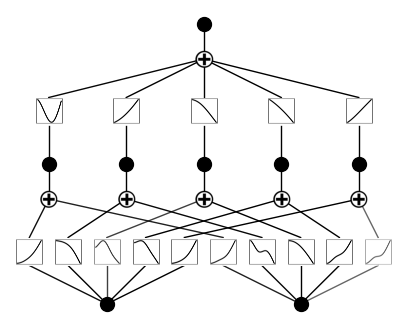

In [46]:
from kan.utils import create_dataset
# create dataset f(x,y) = exp(sin(pi*x)+y^2)
f = lambda x: torch.exp(torch.sin(torch.pi*x[:,[0]]) + x[:,[1]]**2)
dataset = create_dataset(f, n_var=2, device=device)
dataset['train_input'].shape, dataset['train_label'].shape

# plot KAN at initialization
model(dataset['train_input']);
model.plot()

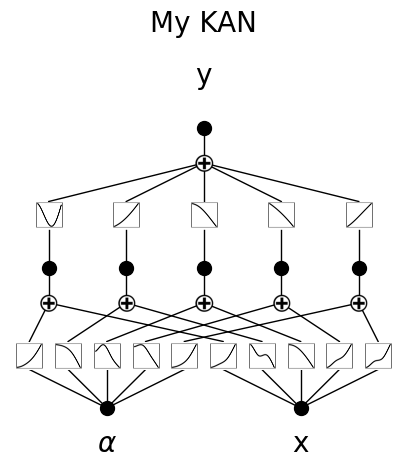

In [41]:
model.plot(beta=100, in_vars=[r'$\alpha$', 'x'], out_vars=['y'], title = 'My KAN')

In [47]:
# Convert selected features into PyTorch tensors (Ensure float64)
X_train_tensor_kan = torch.tensor(X_train_fs, dtype=torch.float64)
y_train_tensor_kan = torch.tensor(y_train_resampled, dtype=torch.float64).view(-1, 1)

X_test_tensor_kan = torch.tensor(X_test_fs, dtype=torch.float64)
y_test_tensor_kan = torch.tensor(y_test_enc, dtype=torch.float64).view(-1, 1)
# Check tensor shapes'
print("Train Tensor Shape:", X_train_tensor_kan.shape, y_train_tensor_kan.shape)
print("Test Tensor Shape:", X_test_tensor_kan.shape, y_test_tensor_kan.shape)


Train Tensor Shape: torch.Size([986, 9]) torch.Size([986, 1])
Test Tensor Shape: torch.Size([200, 9]) torch.Size([200, 1])


In [51]:
# Set device (use GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Define the KAN model
kan_model = KAN(
    width=[X_train_tensor_kan.shape[1], 5, 1],  # Input → 5 hidden neurons → Output
    grid=5,  # Grid intervals
    k=3,     # Spline order
    seed=42,
    device=device
)

# Move model to the correct device
kan_model.to(device)

# Print model summary
print(kan_model)


Using device: cpu
checkpoint directory created: ./model
saving model version 0.0
MultKAN(
  (act_fun): ModuleList(
    (0-1): 2 x KANLayer(
      (base_fun): SiLU()
    )
  )
  (base_fun): SiLU()
  (symbolic_fun): ModuleList(
    (0-1): 2 x Symbolic_KANLayer()
  )
)


In [53]:
import torch.optim as optim

# Define loss function and optimizer
criterion = torch.nn.BCELoss()  # Binary classification (use MSELoss for regression)
optimizer = optim.Adam(kan_model.parameters(), lr=0.001)


In [54]:
# If KAN model already applies sigmoid internally
criterion = torch.nn.BCELoss()  # Use this
optimizer = optim.Adam(kan_model.parameters(), lr=1e-4)  # Reduce LR

# Add LR scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.9)  


In [57]:
from sklearn.metrics import roc_curve, auc
# Move tensors to the correct device
X_train_tensor_kan, y_train_tensor_kan = X_train_tensor_kan.to(device), y_train_tensor_kan.to(device)
X_test_tensor_kan, y_test_tensor_kan = X_test_tensor_kan.to(device), y_test_tensor_kan.to(device)
criterion = torch.nn.BCEWithLogitsLoss()  # Use BCEWithLogitsLoss to handle raw logits
optimizer = torch.optim.Adam(kan_model.parameters(), lr=0.001)
# Training loop (fixed order)
epochs = 100
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = kan_model(X_train_tensor_kan)
    loss = criterion(outputs, y_train_tensor_kan)
    loss.backward()
    optimizer.step()
    scheduler.step()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")



print("Training complete!")



C:\Users\HungPhatPC\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch [10/100], Loss: 0.6636
Epoch [20/100], Loss: 0.6513
Epoch [30/100], Loss: 0.6378
Epoch [40/100], Loss: 0.6226
Epoch [50/100], Loss: 0.6057
Epoch [60/100], Loss: 0.5869
Epoch [70/100], Loss: 0.5663
Epoch [80/100], Loss: 0.5442
Epoch [90/100], Loss: 0.5208
Epoch [100/100], Loss: 0.4964
Training complete!


In [59]:
# Ensure KAN model is in evaluation mode
kan_model.eval()

# Get predictions using the full feature set
with torch.no_grad():
    y_test_kan = kan_model(X_test_tensor_kan)  # Raw logits
    y_pred_prob_kan = torch.sigmoid(y_test_kan).cpu().numpy()  # Convert to probabilities
    y_pred_label_kan = (y_pred_prob_kan > 0.5).astype(int) # Threshold at 0.5

# Convert tensors to NumPy for evaluation
y_test_enc_np = y_test_tensor_kan.cpu().numpy()  # Ensure test labels are also in NumPy


In [63]:
from sklearn.metrics import classification_report, accuracy_score
# Compute classification report
report = classification_report(y_test_enc_np, (y_pred_label_kan))
print("\n- KAN Model Classification Report ⭐")
print(report)



- KAN Model Classification Report ⭐
              precision    recall  f1-score   support

         0.0       0.77      0.92      0.84        61
         1.0       0.96      0.88      0.92       139

    accuracy                           0.89       200
   macro avg       0.86      0.90      0.88       200
weighted avg       0.90      0.89      0.89       200



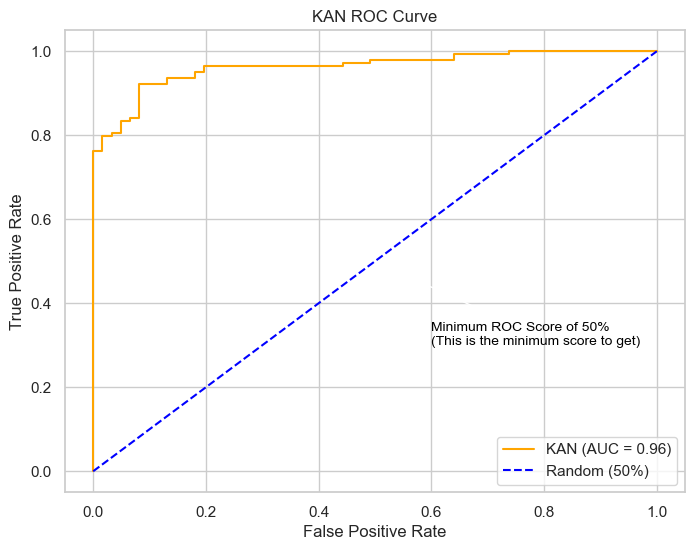

In [67]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure test data is in tensor format
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

# Get probability predictions from KAN
with torch.no_grad():
    y_pred_logits_kan = kan_model(X_test_tensor)  # Raw outputs (logits)
    y_pred_prob_kan = torch.sigmoid(y_pred_logits_kan)  # Convert logits to probabilities

# Convert to numpy array for sklearn metrics
y_pred_prob_kan_np = y_pred_prob_kan.cpu().numpy().squeeze()  # Ensure correct shape
y_test_enc_np = y_test_tensor_kan.cpu().numpy().astype(int)
# Compute ROC curve and AUC score for KAN
fpr_kan, tpr_kan, _ = roc_curve(y_test_enc, y_pred_prob_kan_np)  # False Positive Rate, True Positive Rate
roc_auc = auc(fpr_kan, tpr_kan)  # Compute AUC

# Plot ROC Curve
plt.figure(figsize=(8, 6))
sns.set(style="whitegrid")

# ROC curve (black line)
plt.plot(fpr_kan, tpr_kan, color='orange', label=f'KAN (AUC = {roc_auc:.2f})')

# Baseline (Random Model) at 50%
plt.plot([0, 1], [0, 1], color='blue', linestyle='--', label="Random (50%)")  

# Add annotation
plt.annotate("Minimum ROC Score of 50%\n(This is the minimum score to get)",
             xy=(0.5, 0.5), xytext=(0.6, 0.3),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10, color='black')

# Labels & Title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("KAN ROC Curve")
plt.legend(loc="lower right")

# Show the plot
plt.show()


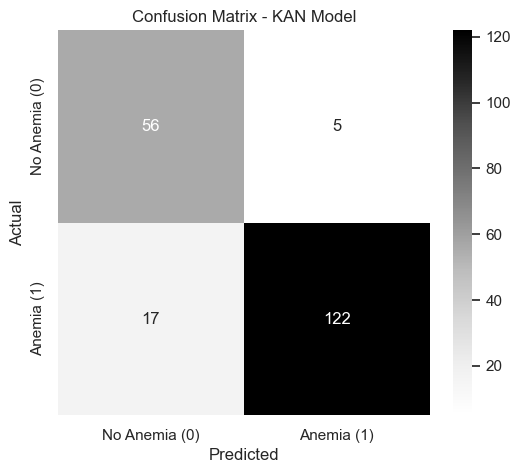


Final Results for KAN Model:
Accuracy: 0.890, AUC: 0.962


In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

kan_model.eval()

# Get predictions from KAN
with torch.no_grad():
    y_pred_logits_kan = kan_model(X_test_tensor)  #Get raw logits
    y_pred_prob_kan = torch.sigmoid(y_pred_logits_kan)  # Convert to probabilities
    y_pred_label_kan = (y_pred_prob_kan > 0.5).float()  # Convert probabilities to binary labels

# Convert tensors to NumPy for evaluation
y_pred_label_kan_np = y_pred_label_kan.cpu().numpy()
y_test_np = y_test_tensor_kan.cpu().numpy()

# Compute confusion matrix
cm_kan = confusion_matrix(y_test_np, y_pred_label_kan_np)
# Compute accuracy & AUC score
acc = accuracy_score(y_test_np, y_pred_label_kan_np)
roc_auc = roc_auc_score(y_test_np, y_pred_prob_kan.cpu().numpy())  # Use probabilities for AUC

#Confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_kan, annot=True, fmt='d', cmap='Greys',
            xticklabels=['No Anemia (0)', 'Anemia (1)'],
            yticklabels=['No Anemia (0)', 'Anemia (1)'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KAN Model")
plt.show()
# Display accuracy and AUC
print("\nFinal Results for KAN Model:")
print(f"Accuracy: {acc:.3f}, AUC: {roc_auc:.3f}")


[[8, 0], [5, 0], [1, 0]]


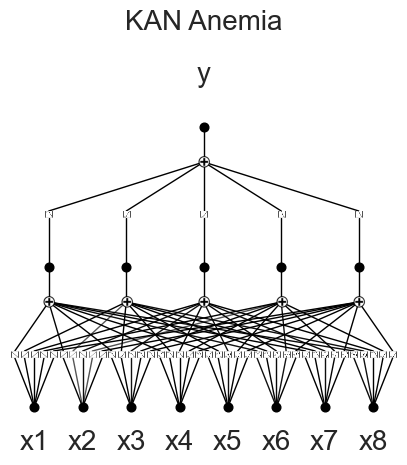

In [212]:
print(kan_model.width)  # This will show the input layer size
kan_model.plot(beta=100, 
               in_vars=[f'x{i+1}' for i in range(10)],  
               out_vars=['y'], 
               title="KAN Anemia")


In [117]:
import torch
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold

# Define K-Fold Cross Validation
k_folds = 10
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Store performance metrics
accuracy_scores = []
auc_scores = []
classification_reports = []


for fold, (train_index, test_index) in enumerate(kf.split(X_train_fs_new, y_train_resampled)):
    print(f"\n🔹 Fold {fold+1}/{k_folds}")

    # Split data into training and validation for this fold
    X_train_fold, X_test_fold = X_train_fs_new[train_index], X_train_fs_new[test_index]
    y_train_fold, y_test_fold = y_train_resampled[train_index], y_train_resampled[test_index]

    # Convert to PyTorch tensors
    X_train_fold_tensor = torch.tensor(X_train_fold, dtype=torch.float64)
    y_train_fold_tensor = torch.tensor(y_train_fold, dtype=torch.float64).view(-1, 1)
    X_test_fold_tensor = torch.tensor(X_test_fold, dtype=torch.float64)
    y_test_fold_tensor = torch.tensor(y_test_fold, dtype=torch.float64).view(-1, 1)
    
    # Move tensors to the correct device (CPU/GPU)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    X_train_fold_tensor, y_train_fold_tensor = X_train_fold_tensor.to(device), y_train_fold_tensor.to(device)
    X_test_fold_tensor, y_test_fold_tensor = X_test_fold_tensor.to(device), y_test_fold_tensor.to(device)

    # Initialize the KAN model for this fold
    kan_model = KAN(
        width=[X_train_fold_tensor.shape[1], 5, 1],  # Input → Hidden → Output
        grid=5,  # Grid intervals
        k=3,  # Spline order
        seed=42,
        device=device
    ).to(device)

    # Define loss function and optimizer
    criterion = torch.nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(kan_model.parameters(), lr=0.001)

    # Training loop
    epochs = 100
    for epoch in range(epochs):
        kan_model.train()
        optimizer.zero_grad()
        outputs = kan_model(X_train_fold_tensor)
        loss = criterion(outputs, y_train_fold_tensor)
        loss.backward()
        optimizer.step()
        
        # Print loss every 20 epochs
        if (epoch + 1) % 20 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

    # Evaluate the model
    kan_model.eval()
    with torch.no_grad():
        y_test_logits_fold = kan_model(X_test_fold_tensor)  # Raw logits
        y_test_prob_fold = torch.sigmoid(y_test_logits_fold).cpu().numpy()  # Convert logits to probabilities
        y_test_pred_label_fold = (y_test_prob_fold > 0.5).astype(int)  # Convert probabilities to binary labels

    # Convert to NumPy for sklearn metrics
    y_test_fold_np = y_test_fold_tensor.cpu().numpy()

    # Compute performance metrics
    acc = accuracy_score(y_test_fold_np, y_test_pred_label_fold)
    auc = roc_auc_score(y_test_fold_np, y_test_prob_fold)

    accuracy_scores.append(acc)
    auc_scores.append(auc)
    classification_reports.append(classification_report(y_test_fold_np, y_test_pred_label_fold, output_dict=True))

    print(f"Fold Accuracy: {acc:.4f}, AUC: {auc:.4f}")
 
# Average performance across folds
avg_accuracy_kan = np.mean(accuracy_scores)
print(f"\nAverage Accuracy across {k_folds} folds: {avg_accuracy_kan:.4f}")


🔹 Fold 1/10
checkpoint directory created: ./model
saving model version 0.0
Epoch [20/100], Loss: 0.6909
Epoch [40/100], Loss: 0.6698
Epoch [60/100], Loss: 0.6420
Epoch [80/100], Loss: 0.6066
Epoch [100/100], Loss: 0.5655
Fold Accuracy: 0.8586, AUC: 0.8967

🔹 Fold 2/10
checkpoint directory created: ./model
saving model version 0.0
Epoch [20/100], Loss: 0.6907
Epoch [40/100], Loss: 0.6695
Epoch [60/100], Loss: 0.6419
Epoch [80/100], Loss: 0.6067
Epoch [100/100], Loss: 0.5653
Fold Accuracy: 0.8081, AUC: 0.8849

🔹 Fold 3/10
checkpoint directory created: ./model
saving model version 0.0
Epoch [20/100], Loss: 0.6908
Epoch [40/100], Loss: 0.6697
Epoch [60/100], Loss: 0.6421
Epoch [80/100], Loss: 0.6065
Epoch [100/100], Loss: 0.5649
Fold Accuracy: 0.7778, AUC: 0.8694

🔹 Fold 4/10
checkpoint directory created: ./model
saving model version 0.0
Epoch [20/100], Loss: 0.6905
Epoch [40/100], Loss: 0.6695
Epoch [60/100], Loss: 0.6421
Epoch [80/100], Loss: 0.6071
Epoch [100/100], Loss: 0.5662
Fold Ac

In [71]:
import torch
import torch.optim as optim
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from scipy.stats import randint, uniform
import optuna

# ---------------- DEFINE KAN MODEL ---------------- #
class KANModel(torch.nn.Module):
    def __init__(self, input_size, hidden_size, grid, k):
        super(KANModel, self).__init__()
        self.fc1 = torch.nn.Linear(input_size, hidden_size, dtype=torch.double)
        self.fc2 = torch.nn.Linear(hidden_size, 1, dtype=torch.double)
        self.sigmoid = torch.nn.Sigmoid()
    
    def forward(self, x):
        x = self.fc1(x)
        x = torch.relu(x)  # Activation function
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

# Convert dataset to PyTorch tensors
X_train_tensor = torch.tensor(X_train_fs, dtype=torch.float64)
y_train_tensor = torch.tensor(y_train_resampled, dtype=torch.float64).view(-1, 1)
X_test_tensor = torch.tensor(X_test_fs, dtype=torch.float64)
y_test_tensor = torch.tensor(y_test_enc, dtype=torch.float64).view(-1, 1)

input_size = X_train_fs.shape[1]  # Number of features

# ---------------- GRID SEARCH ---------------- #
grid_params = {
    'hidden_size': [4, 8, 16, 32],
    'grid': [3, 5, 7],
    'k': [2, 3, 4],
    'learning_rate': [0.001, 0.01, 0.1]
}

best_acc = 0
best_grid_model = None
best_grid_params = {}

best_acc = 0
best_auc = 0
best_grid_model = None
best_grid_params = {}

for hidden_size in grid_params['hidden_size']:
    for grid in grid_params['grid']:
        for k in grid_params['k']:
            for lr in grid_params['learning_rate']:
                model = KANModel(input_size, hidden_size, grid, k)
                criterion = torch.nn.BCELoss()
                optimizer = optim.Adam(model.parameters(), lr=lr)

                # Train model
                for epoch in range(50):
                    optimizer.zero_grad()
                    outputs = model(X_train_tensor)
                    loss = criterion(outputs, y_train_tensor)
                    loss.backward()
                    optimizer.step()

                # Evaluate
                with torch.no_grad():
                    y_pred = model(X_test_tensor)
                    y_label = (y_pred > 0.5).float()
                    y_true = y_test_tensor.numpy()
                    y_proba = y_pred.numpy()

                    acc = accuracy_score(y_true, y_label.numpy())
                    auc = roc_auc_score(y_true, y_proba)

                if auc > best_auc:  # 🔥 AUC-based selection
                    best_acc = acc
                    best_auc = auc
                    best_grid_model = model
                    best_grid_params = {
                        'hidden_size': hidden_size,
                        'grid': grid,
                        'k': k,
                        'learning_rate': lr
                    }

print("\n🔹 Grid Search Best Hyperparameters (KAN):", best_grid_params)
print("🔹 Grid Search Best Accuracy:", best_acc)
print("🔹 Grid Search Best AUC:", best_auc)


# ---------------- RANDOMIZED SEARCH ---------------- #
random_params = {
    'hidden_size': randint(4, 32),
    'grid': randint(3, 7),
    'k': randint(2, 5),
    'learning_rate': uniform(0.0001, 0.1)
}

best_random_acc = 0
best_random_auc = 0
best_random_model = None
best_random_params = {}

for _ in range(20):  # 20 random trials
    hidden_size = random_params['hidden_size'].rvs()
    grid = random_params['grid'].rvs()
    k = random_params['k'].rvs()
    lr = random_params['learning_rate'].rvs()

    model = KANModel(input_size, hidden_size, grid, k)
    criterion = torch.nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Train model
    for epoch in range(50):
        optimizer.zero_grad()
        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        loss.backward()
        optimizer.step()

    # Evaluate
    with torch.no_grad():
        y_pred = model(X_test_tensor)
        y_label = (y_pred > 0.5).float()
        y_true = y_test_tensor.numpy()
        y_proba = y_pred.numpy()

        acc = accuracy_score(y_true, y_label.numpy())
        auc = roc_auc_score(y_true, y_proba)

    if auc > best_random_auc:  # AUC is the main metric
        best_random_acc = acc
        best_random_auc = auc
        best_random_model = model
        best_random_params = {
            'hidden_size': hidden_size,
            'grid': grid,
            'k': k,
            'learning_rate': lr
        }

print("\n🔹 Random Search Best Hyperparameters (KAN):", best_random_params)
print("🔹 Random Search Best Accuracy:", best_random_acc)
print("🔹 Random Search Best AUC:", best_random_auc)

# ---------------- OPTUNA BAYESIAN OPTIMIZATION ---------------- #
def objective_kan(trial):
    hidden_size = trial.suggest_int('hidden_size', 4, 32)
    grid = trial.suggest_int('grid', 3, 7)
    k = trial.suggest_int('k', 2, 4)
    lr = trial.suggest_float('learning_rate', 0.0001, 0.1, log=True)

    model = KANModel(input_size, hidden_size, grid, k)
    criterion = torch.nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Train model
    for epoch in range(50):
        optimizer.zero_grad()
        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        loss.backward()
        optimizer.step()

    # Evaluate
    with torch.no_grad():
        y_test_pred = model(X_test_tensor)
        y_test_pred_label = (y_test_pred > 0.5).float()
    acc = accuracy_score(y_test_tensor.numpy(), y_test_pred_label.numpy())

    return acc

study_kan = optuna.create_study(direction='maximize')
study_kan.optimize(objective_kan, n_trials=30)

best_bayes_kan_params = study_kan.best_params
best_bayes_kan = KANModel(input_size, best_bayes_kan_params['hidden_size'], best_bayes_kan_params['grid'], best_bayes_kan_params['k'])
best_bayes_kan.eval()

print("\n🔹 Bayesian Optimization Best Hyperparameters (KAN):", best_bayes_kan_params)
print("🔹 Bayesian Optimization Best Accuracy:", study_kan.best_value)



🔹 Grid Search Best Hyperparameters (KAN): {'hidden_size': 4, 'grid': 3, 'k': 2, 'learning_rate': 0.1}
🔹 Grid Search Best Accuracy: 0.995
🔹 Grid Search Best AUC: 1.0


[I 2025-04-26 14:24:44,151] A new study created in memory with name: no-name-e743d063-6f04-4eed-a597-e8b6c1a9c628
[I 2025-04-26 14:24:44,202] Trial 0 finished with value: 0.885 and parameters: {'hidden_size': 17, 'grid': 7, 'k': 3, 'learning_rate': 0.004997507193254339}. Best is trial 0 with value: 0.885.
[I 2025-04-26 14:24:44,246] Trial 1 finished with value: 0.99 and parameters: {'hidden_size': 23, 'grid': 3, 'k': 4, 'learning_rate': 0.06054193042118004}. Best is trial 1 with value: 0.99.
[I 2025-04-26 14:24:44,285] Trial 2 finished with value: 0.495 and parameters: {'hidden_size': 6, 'grid': 3, 'k': 4, 'learning_rate': 0.0008343145610072731}. Best is trial 1 with value: 0.99.
[I 2025-04-26 14:24:44,328] Trial 3 finished with value: 0.59 and parameters: {'hidden_size': 22, 'grid': 5, 'k': 4, 'learning_rate': 0.00028418591154516113}. Best is trial 1 with value: 0.99.



🔹 Random Search Best Hyperparameters (KAN): {'hidden_size': 22, 'grid': 5, 'k': 4, 'learning_rate': 0.04602488919658672}
🔹 Random Search Best Accuracy: 0.995
🔹 Random Search Best AUC: 0.9998820615638636


[I 2025-04-26 14:24:44,369] Trial 4 finished with value: 0.99 and parameters: {'hidden_size': 8, 'grid': 5, 'k': 3, 'learning_rate': 0.08229875215112206}. Best is trial 1 with value: 0.99.
[I 2025-04-26 14:24:44,412] Trial 5 finished with value: 0.605 and parameters: {'hidden_size': 14, 'grid': 5, 'k': 3, 'learning_rate': 0.0016187251801926931}. Best is trial 1 with value: 0.99.
[I 2025-04-26 14:24:44,452] Trial 6 finished with value: 0.765 and parameters: {'hidden_size': 10, 'grid': 7, 'k': 2, 'learning_rate': 0.0006966700181378723}. Best is trial 1 with value: 0.99.
[I 2025-04-26 14:24:44,493] Trial 7 finished with value: 0.935 and parameters: {'hidden_size': 8, 'grid': 5, 'k': 4, 'learning_rate': 0.00874216430068894}. Best is trial 1 with value: 0.99.
[I 2025-04-26 14:24:44,539] Trial 8 finished with value: 0.935 and parameters: {'hidden_size': 13, 'grid': 5, 'k': 2, 'learning_rate': 0.005833998819771847}. Best is trial 1 with value: 0.99.
[I 2025-04-26 14:24:44,583] Trial 9 finishe


🔹 Bayesian Optimization Best Hyperparameters (KAN): {'hidden_size': 32, 'grid': 3, 'k': 4, 'learning_rate': 0.06753607047058494}
🔹 Bayesian Optimization Best Accuracy: 0.995


# Comparision ML models


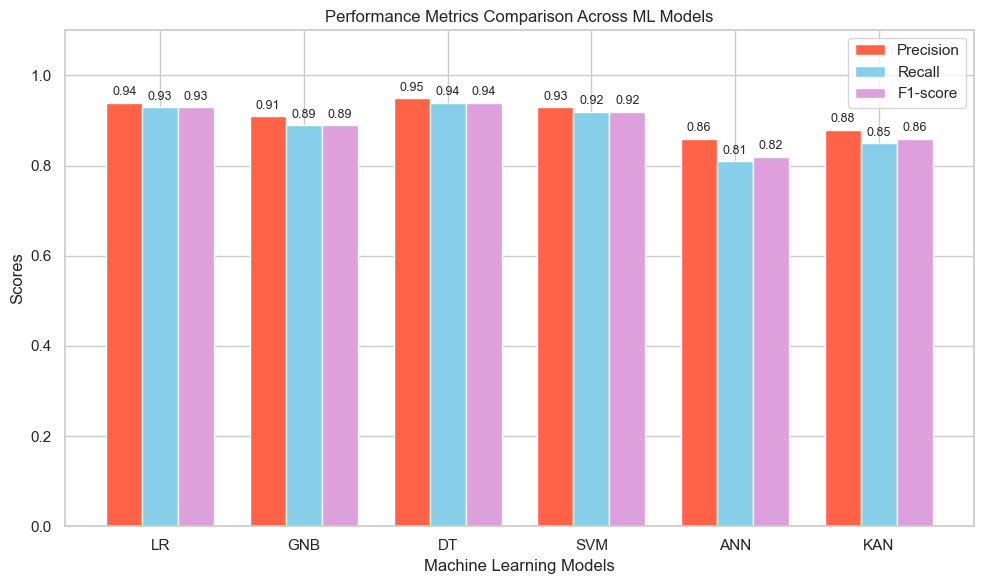

In [116]:
import matplotlib.pyplot as plt
import numpy as np

# Weighted average scores for 6 models
model_names = ['LR', 'GNB', 'DT', 'SVM', 'ANN', 'KAN']
precision = [0.94, 0.91, 0.95, 0.93, 0.86, 0.88]
recall =    [0.93, 0.89, 0.94, 0.92, 0.81, 0.85]
f1_score =  [0.93, 0.89, 0.94, 0.92, 0.82, 0.86]

x = np.arange(len(model_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width, precision, width, label='Precision', color='tomato')
bars2 = ax.bar(x, recall, width, label='Recall', color='skyblue')
bars3 = ax.bar(x + width, f1_score, width, label='F1-score', color='plum')

ax.set_xlabel('Machine Learning Models')
ax.set_ylabel('Scores')
ax.set_title('Performance Metrics Comparison Across ML Models')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim([0, 1.1])
ax.legend()

# Add values on top of bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


In [2]:
# Accuracy and Specificity values (example based on confusion matrix for your models)
model_names = ['LR', 'GNB', 'DT', 'SVM', 'ANN', 'KAN']
accuracy = [0.93, 0.89, 0.91, 0.92, 0.81, 0.85]
specificity = [0.95, 0.97, 0.98, 0.98, 0.87, 0.92]  # TN / (TN + FP) from confusion matrices

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, accuracy, width, label='Accuracy', color='tomato')
bars2 = ax.bar(x + width/2, specificity, width, label='Specificity', color='deepskyblue')

ax.set_xlabel('Machine Learning Models')
ax.set_ylabel('Score')
ax.set_title('Accuracy and Specificity Across ML Models')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim([0, 1.1])
ax.legend()

# Annotate bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


NameError: name 'np' is not defined

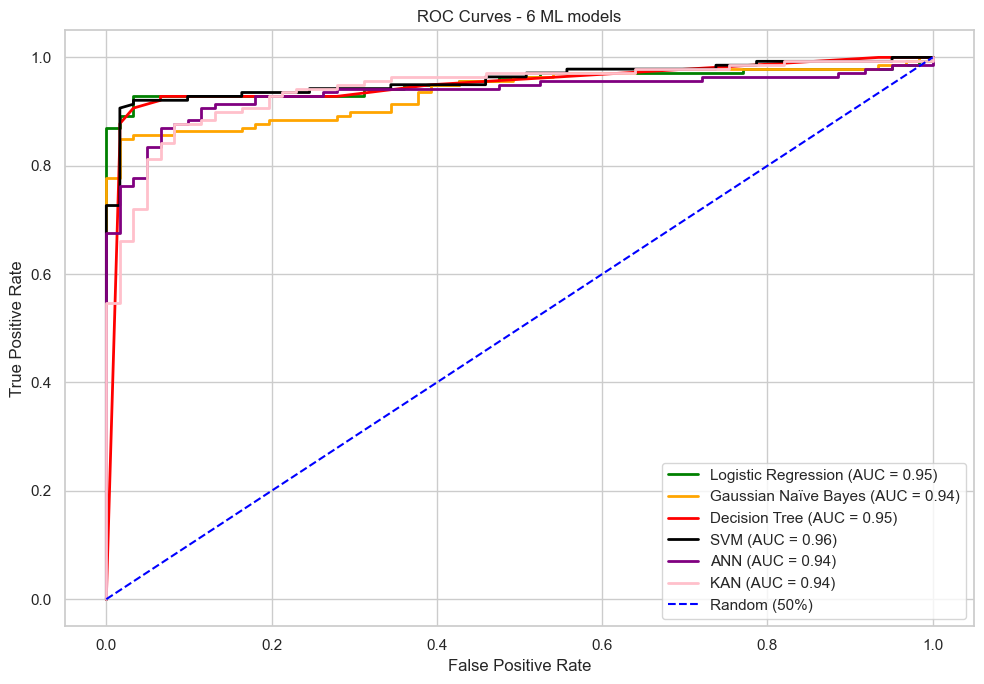

In [234]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import seaborn as sns

# Set style
sns.set(style='whitegrid')

# Compute ROC curve and AUC for LR
fpr_lr, tpr_lr, _ = roc_curve(y_test_enc, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# Compute ROC curve and AUC for GNB
fpr_gnb, tpr_gnb, _ = roc_curve(y_test_enc, y_prob_gnb)
roc_auc_gnb = auc(fpr_gnb, tpr_gnb)
# Compute ROC curve and AUC for Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test_enc, y_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

# Compute ROC curve and AUC for SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test_enc, y_prob_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

#Comput ROC curve and AUC for ANN
fpr_ann, tpr_ann, _ = roc_curve(y_test_np, y_test_pred_prob_np)
roc_auc_ann = auc(fpr_ann, tpr_ann)

# Compute ROC curve and AUC score for KAN
fpr_kan, tpr_kan, _ = roc_curve(y_test_enc, y_pred_prob_kan_np)  # False Positive Rate, True Positive Rate
roc_auc_kan = auc(fpr_kan, tpr_kan)  # Compute AUC

# 📈 Plot ROC curves
plt.figure(figsize=(10, 7))
#Plot LR
plt.plot(fpr_lr, tpr_lr, color='green', linestyle='-', linewidth=2,
         label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
#Plot GNB
plt.plot(fpr_gnb, tpr_gnb, color='orange', linestyle='-', linewidth=2,
         label=f'Gaussian Naïve Bayes (AUC = {roc_auc_gnb:.2f})')
# 🎯 Plot for Decision Tree
plt.plot(fpr_dt, tpr_dt, color='red', linestyle='-', linewidth=2,
         label=f'Decision Tree (AUC = {roc_auc_dt:.2f})')

# 🎯 Plot for SVM
plt.plot(fpr_svm, tpr_svm, color='black', linestyle='-', linewidth=2,
         label=f'SVM (AUC = {roc_auc_svm:.2f})')

#Plot for ANN
plt.plot(fpr_ann, tpr_ann, color='purple', linestyle='-', linewidth=2,
         label=f'ANN (AUC = {roc_auc_ann:.2f})')
#Plot for KAN
plt.plot(fpr_kan, tpr_kan, color = 'pink', linestyle = '-', linewidth = 2,
        label = f'KAN (AUC = {roc_auc_kan:.2f})')
# Add random baseline
plt.plot([0, 1], [0, 1], color='blue', linestyle='--', label='Random (50%)')



# Labels and legend
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - 6 ML models')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


In [158]:
pip install shap

   ---------------------------------------- 0.0/490.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/490.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/490.6 kB ? eta -:--:--
    --------------------------------------- 10.2/490.6 kB ? eta -:--:--
    --------------------------------------- 10.2/490.6 kB ? eta -:--:--
   -- ------------------------------------ 30.7/490.6 kB 262.6 kB/s eta 0:00:02
   -- ------------------------------------ 30.7/490.6 kB 262.6 kB/s eta 0:00:02
   ----- --------------------------------- 71.7/490.6 kB 302.7 kB/s eta 0:00:02
   ------- ------------------------------- 92.2/490.6 kB 375.8 kB/s eta 0:00:02
   --------- ---------------------------- 122.9/490.6 kB 361.0 kB/s eta 0:00:02
   --------- ---------------------------- 122.9/490.6 kB 361.0 kB/s eta 0:00:02
   --------- ---------------------------- 122.9/490.6 kB 361.0 kB/s eta 0:00:02
   ----------- -------------------------- 143.4/490.6 kB 315.4 kB/s eta 0:00:02
   

  0%|          | 0/100 [00:00<?, ?it/s]

C:\Users\HungPhatPC\anaconda3\Lib\site-packages\kan\MultKAN.py:813: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1831.)
  self.subnode_actscale.append(torch.std(x, dim=0).detach())
C:\Users\HungPhatPC\anaconda3\Lib\site-packages\kan\MultKAN.py:823: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1831.)
  input_range = torch.std(preacts, dim=0) + 0.1
C:\Users\HungPhatPC\anaconda3\Lib\site-packages\kan\MultKAN.py:824: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered in

<Figure size 640x480 with 0 Axes>

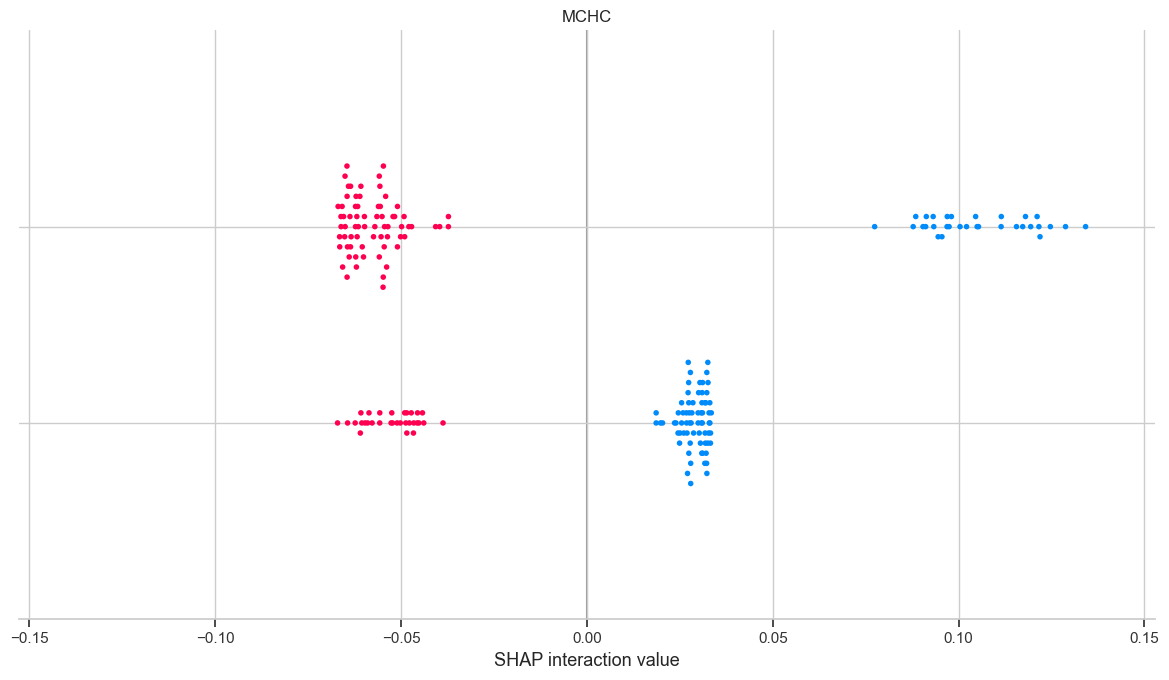

In [146]:
import pandas as pd
import shap

# Convert to DataFrame with correct feature names
feature_names = [
    "PCV", "MCHC", "Hb", "RBC", "MCH", "Age", "MCV", "Gender"
]  

X_test_shap = pd.DataFrame(X_test_fs_new, columns=feature_names)

# Compute SHAP values separately first
shap_values = explainer.shap_values(X_test_fs_new[:100])

# Plot SHAP summary
shap.summary_plot(shap_values, X_test_shap.iloc[:100], plot_type="dot")



In [ ]:
import pandas as pd
import shap

# Convert to DataFrame with correct feature names
X_test_shap = pd.DataFrame(X_test_fs_new, columns=feature_names)

# Plot SHAP summary
shap.summary_plot(
    shap_values[:, :, 1],       # Only SHAP values for class 1 (Anemia)
    X_test_shap,                  # Feature values as DataFrame
    plot_type='bar'             # Optional: 'dot' or 'bar' or 'violin'
)
